# Experiments for F1 Podium and Top10

###### Author: Felipe Valencia-Clavijo

## Data prep

Import dataset:

In [76]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from catboost import CatBoostClassifier

from itertools import product

from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    average_precision_score
)

# Load dataset
df = pd.read_csv("df_with_pred_qualifying_v13.csv")

print(df.shape)

shape_2020_25 = df[df["season"] >= 2020].shape
df.head()

(2970, 45)


,season,round,DriverId,TeamId,grid_position,race_finishing_position,classified_position,status,raw_points,laps_completed,...,positive_qualifying_surprise,negative_qualifying_surprise,predicted_classification_points,predicted_classification_points_raw,race_gain,race_loss,recent_gain_exposure,recent_loss_exposure,exposure_history_count,net_recent_deviation
0,2020,16,aitken,williams,17,16,16,Finished,0.0,87,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,2019,1,albon,toro_rosso,13,14,14,+1 Lap,0.0,57,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2,2019,2,albon,toro_rosso,12,9,9,Finished,2.0,57,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
3,2019,4,albon,toro_rosso,11,11,11,+1 Lap,0.0,50,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
4,2019,5,albon,toro_rosso,11,11,11,Finished,0.0,66,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0


Initial required model features:

In [77]:
required_model_columns = [
    "qualifying_position",
    "driver_points_mean_last3",
    "driver_qualifying_mean_last3",
    "team_points_mean_last3",
    "team_qualifying_mean_last3",
    "driver_incident_rate_last10",
    "driver_previous_starts",
    "exposure_history_count",
    "positive_qualifying_surprise",
    "negative_qualifying_surprise",
    "recent_gain_exposure",
    "recent_loss_exposure",
    "qualifying_surprise",
    "net_recent_deviation",
    "Top10",
    "Podium",
]

Checking for missing values:

In [78]:
nan_counts = (
    df[df["season"] >= 2020][required_model_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(nan_counts)

positive_qualifying_surprise    25
negative_qualifying_surprise    25
qualifying_surprise             25
driver_points_mean_last3        17
driver_qualifying_mean_last3    17
driver_incident_rate_last10     17
team_points_mean_last3           8
team_qualifying_mean_last3       8
qualifying_position              0
driver_previous_starts           0
exposure_history_count           0
recent_gain_exposure             0
recent_loss_exposure             0
net_recent_deviation             0
Top10                            0
Podium                           0
dtype: int64

Filtering to only 2020 and onwards since 2018-2019 were used to predict the expectation features from which we derived qualifiyng surprise and recent gain/loss exposure and dropping missing values from required features:

In [79]:
df = (
    df[df["season"] >= 2020]
    .dropna(subset=required_model_columns)
    .copy()
    .reset_index(drop=True)
)
shape_2020_25_others = df.shape
df

,season,round,DriverId,TeamId,grid_position,race_finishing_position,classified_position,status,raw_points,laps_completed,...,positive_qualifying_surprise,negative_qualifying_surprise,predicted_classification_points,predicted_classification_points_raw,race_gain,race_loss,recent_gain_exposure,recent_loss_exposure,exposure_history_count,net_recent_deviation
0,2020,1,albon,red_bull,4,13,13,Electronics,0.0,67,...,1.0,0.0,12.0,9.386359,0.0,12.0,0.0,0.0,0.0,0.0
1,2020,2,albon,red_bull,6,4,4,Finished,12.0,71,...,0.0,2.0,2.0,6.229112,10.0,0.0,0.0,12.0,1.0,-12.0
2,2020,3,albon,red_bull,13,5,5,Finished,10.0,70,...,0.0,8.0,4.0,7.333508,6.0,0.0,10.0,12.0,2.0,-2.0
3,2020,4,albon,red_bull,12,8,8,Finished,4.0,52,...,0.0,5.0,8.0,5.820623,0.0,4.0,16.0,12.0,3.0,4.0
4,2020,5,albon,red_bull,9,5,5,Finished,10.0,52,...,3.0,0.0,12.0,7.859527,0.0,2.0,16.0,4.0,3.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2102,2024,17,zhou,sauber,17,14,14,Finished,0.0,51,...,2.0,0.0,0.0,0.463901,0.0,0.0,0.0,0.0,3.0,0.0
2103,2024,18,zhou,sauber,20,15,15,Lapped,0.0,61,...,0.0,-0.0,0.0,0.631984,0.0,0.0,0.0,0.0,3.0,0.0
2104,2024,20,zhou,sauber,19,15,15,Lapped,0.0,70,...,0.0,-0.0,0.0,0.358523,0.0,0.0,0.0,0.0,3.0,0.0
2105,2024,22,zhou,sauber,13,13,13,Finished,0.0,50,...,7.0,0.0,0.0,0.491869,0.0,0.0,0.0,0.0,3.0,0.0


In [80]:
shape_diff = shape_2020_25[0] - shape_2020_25_others[0]
print(shape_diff)

25


Checking high correlation and multicollinearity:

In [81]:
numeric_features = [
    "qualifying_position",
    "driver_points_mean_last3",
    "driver_qualifying_mean_last3",
    "team_points_mean_last3",
    "team_qualifying_mean_last3",
    "driver_incident_rate_last10",
    "driver_previous_starts",
    "exposure_history_count",
    "qualifying_surprise",
    "positive_qualifying_surprise",
    "negative_qualifying_surprise",
    "recent_gain_exposure",
    "recent_loss_exposure",
    "net_recent_deviation"
]

corr_matrix = df[numeric_features].corr(method="pearson")

display(corr_matrix.round(3))

,qualifying_position,driver_points_mean_last3,driver_qualifying_mean_last3,team_points_mean_last3,team_qualifying_mean_last3,driver_incident_rate_last10,driver_previous_starts,exposure_history_count,qualifying_surprise,positive_qualifying_surprise,negative_qualifying_surprise,recent_gain_exposure,recent_loss_exposure,net_recent_deviation
qualifying_position,1.000,-0.642,0.718,-0.644,0.696,0.160,-0.253,-0.014,-0.390,-0.266,0.376,-0.288,-0.400,0.146
driver_points_mean_last3,-0.642,1.000,-0.801,0.882,-0.754,-0.167,0.290,0.016,-0.171,-0.203,0.086,0.465,0.288,0.054
driver_qualifying_mean_last3,0.718,-0.801,1.000,-0.769,0.899,0.176,-0.310,-0.030,0.338,0.323,-0.243,-0.342,-0.522,0.211
team_points_mean_last3,-0.644,0.882,-0.769,1.000,-0.853,-0.158,0.258,0.036,-0.126,-0.142,0.071,0.408,0.405,-0.076
team_qualifying_mean_last3,0.696,-0.754,0.899,-0.853,1.000,0.183,-0.270,-0.027,0.229,0.220,-0.163,-0.341,-0.530,0.217
driver_incident_rate_last10,0.160,-0.167,0.176,-0.158,0.183,1.000,-0.209,-0.051,0.015,-0.027,-0.049,-0.103,-0.016,-0.051
driver_previous_starts,-0.253,0.290,-0.310,0.258,-0.270,-0.209,1.000,0.116,-0.058,-0.021,0.074,0.088,0.169,-0.082
exposure_history_count,-0.014,0.016,-0.030,0.036,-0.027,-0.051,0.116,1.000,0.003,-0.003,-0.007,0.234,0.179,-0.000
qualifying_surprise,-0.390,-0.171,0.338,-0.126,0.229,0.015,-0.058,0.003,1.000,0.810,-0.848,-0.059,-0.141,0.078
positive_qualifying_surprise,-0.266,-0.203,0.323,-0.142,0.220,-0.027,-0.021,-0.003,0.810,1.000,-0.377,-0.040,-0.146,0.093


In [82]:
corr_pairs = (
    corr_matrix
    .where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

high_corr = corr_pairs[
    corr_pairs["correlation"].abs() >= 0.70
].sort_values(
    "correlation",
    key=abs,
    ascending=False
)

display(high_corr)

,feature_1,feature_2,correlation
26,driver_qualifying_mean_last3,team_qualifying_mean_last3,0.898843
14,driver_points_mean_last3,team_points_mean_last3,0.881940
36,team_points_mean_last3,team_qualifying_mean_last3,-0.852901
77,qualifying_surprise,negative_qualifying_surprise,-0.848405
76,qualifying_surprise,positive_qualifying_surprise,0.810312
13,driver_points_mean_last3,driver_qualifying_mean_last3,-0.801176
90,recent_loss_exposure,net_recent_deviation,-0.789017
25,driver_qualifying_mean_last3,team_points_mean_last3,-0.769248
15,driver_points_mean_last3,team_qualifying_mean_last3,-0.753653
1,qualifying_position,driver_qualifying_mean_last3,0.717958


In [83]:
def calculate_vif(df, features):

    # Complete cases
    X = df[features].dropna().astype(float)

    # IMPORTANT: include intercept
    X = add_constant(X)

    vif = pd.DataFrame()

    vif["feature"] = X.columns

    vif["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    # Remove intercept from displayed results
    vif = vif[vif["feature"] != "const"]

    return vif.sort_values(
        "VIF",
        ascending=False
    ).reset_index(drop=True)

Including all relevant features:

In [84]:
M3A_numeric = [
    "qualifying_position",
    "driver_points_mean_last3",
    "driver_qualifying_mean_last3",
    "team_points_mean_last3",
    "team_qualifying_mean_last3",
    "driver_incident_rate_last10",
    "driver_previous_starts",
    "exposure_history_count",
    "positive_qualifying_surprise",
    "negative_qualifying_surprise",
    "recent_gain_exposure",
    "recent_loss_exposure"
]

display(
    calculate_vif(df, M3A_numeric).round(2)
)

,feature,VIF
0,driver_qualifying_mean_last3,40.39
1,qualifying_position,31.44
2,team_qualifying_mean_last3,10.18
3,team_points_mean_last3,9.23
4,driver_points_mean_last3,8.17
5,negative_qualifying_surprise,7.87
6,positive_qualifying_surprise,6.43
7,recent_loss_exposure,1.72
8,recent_gain_exposure,1.45
9,exposure_history_count,1.18


Removing features due to high VIF:

In [85]:
M3A_numeric = [
    "qualifying_position",
    "driver_points_mean_last3",
    #"driver_qualifying_mean_last3",
    "team_points_mean_last3",
    #"team_qualifying_mean_last3",
    "driver_incident_rate_last10",
    "driver_previous_starts",
    "exposure_history_count",
    "positive_qualifying_surprise",
    "negative_qualifying_surprise",
    "recent_gain_exposure",
    "recent_loss_exposure"
]

display(
    calculate_vif(df, M3A_numeric).round(2)
)

,feature,VIF
0,driver_points_mean_last3,6.37
1,team_points_mean_last3,5.20
2,qualifying_position,4.11
3,negative_qualifying_surprise,1.69
4,recent_loss_exposure,1.68
5,positive_qualifying_surprise,1.61
6,recent_gain_exposure,1.43
7,driver_previous_starts,1.17
8,exposure_history_count,1.17
9,driver_incident_rate_last10,1.08


## Modeling

In [ ]:
# ------------------------------------------------------------
# TARGETS
# ------------------------------------------------------------

y1 = df["Top10"]   # Primary performance target
y2 = df["Podium"]  # Exceptional-performance target


# ------------------------------------------------------------
# CONTROL FEATURES
# ------------------------------------------------------------

control_features = [
    "driver_incident_rate_last10",
    "driver_previous_starts",
    "exposure_history_count"
]


# ------------------------------------------------------------
# CONVENTIONAL BASELINE FEATURES
# ------------------------------------------------------------

baseline_performance_features = [
    "qualifying_position",
    "driver_points_mean_last3",
    "team_points_mean_last3",
]

categorical_features = [
    "DriverId",
    "TeamId",
    "location",
    "season"
]

baseline_features = (
    baseline_performance_features
    + control_features
    + categorical_features
)


# ------------------------------------------------------------
# M0 — CONVENTIONAL BASELINE
# ------------------------------------------------------------

M0_features = baseline_features

M0 = df[M0_features]


# ------------------------------------------------------------
# M1S — SYMMETRIC QUALIFYING-EXPECTATION MODEL
# ------------------------------------------------------------
# Uses one signed qualifying-surprise variable.

M1S_features = baseline_features + [
    "qualifying_surprise"
]

M1S = df[M1S_features]


# ------------------------------------------------------------
# M1A — ASYMMETRIC QUALIFYING-EXPECTATION MODEL
# ------------------------------------------------------------
# Separates positive and negative qualifying surprise.

M1A_features = baseline_features + [
    "positive_qualifying_surprise",
    "negative_qualifying_surprise"
]

M1A = df[M1A_features]


# ------------------------------------------------------------
# M2S — SYMMETRIC RECENT EXPECTATION-DEVIATION MODEL
# ------------------------------------------------------------
# Net recent deviation:
# recent_gain_exposure - recent_loss_exposure

M2S_features = baseline_features + [
    "net_recent_deviation"
]

M2S = df[M2S_features]


# ------------------------------------------------------------
# M2A — ASYMMETRIC RECENT GAIN-LOSS MODEL
# ------------------------------------------------------------
# Keeps recent gains and losses separate.

M2A_features = baseline_features + [
    "recent_gain_exposure",
    "recent_loss_exposure"
]

M2A = df[M2A_features]


# ------------------------------------------------------------
# M3S — FULL SYMMETRIC MODEL
# ------------------------------------------------------------
# Signed qualifying surprise + net recent deviation.

M3S_features = baseline_features + [
    "qualifying_surprise",
    "net_recent_deviation"
]

M3S = df[M3S_features]


# ------------------------------------------------------------
# M3A — FULL ASYMMETRIC MODEL
# ------------------------------------------------------------
# Main behavioral specification.

M3A_features = baseline_features + [
    "positive_qualifying_surprise",
    "negative_qualifying_surprise",
    "recent_gain_exposure",
    "recent_loss_exposure"
]

M3A = df[M3A_features]


# ------------------------------------------------------------
# STORE FEATURE SETS FOR LATER EXPERIMENTS
# ------------------------------------------------------------

feature_sets = {
    "M0_baseline": M0_features,
    "M1S_symmetric_qualifying": M1S_features,
    "M1A_asymmetric_qualifying": M1A_features,
    "M2S_symmetric_gain_loss": M2S_features,
    "M2A_asymmetric_gain_loss": M2A_features,
    "M3S_full_symmetric": M3S_features,
    "M3A_full_asymmetric": M3A_features
}


# ------------------------------------------------------------
# STORE TARGETS
# ------------------------------------------------------------

targets = {
    "Top10": y1,
    "Podium": y2
}


# ------------------------------------------------------------
# QUICK CHECK:
# ------------------------------------------------------------

for model_name, features in feature_sets.items():
    print(f"{model_name}: {len(features)} features")
    print(features)
    print()

M0_baseline: 10 features
['qualifying_position', 'driver_points_mean_last3', 'team_points_mean_last3', 'driver_incident_rate_last10', 'driver_previous_starts', 'exposure_history_count', 'DriverId', 'TeamId', 'location', 'season']

M1S_symmetric_qualifying: 11 features
['qualifying_position', 'driver_points_mean_last3', 'team_points_mean_last3', 'driver_incident_rate_last10', 'driver_previous_starts', 'exposure_history_count', 'DriverId', 'TeamId', 'location', 'season', 'qualifying_surprise']

M1A_asymmetric_qualifying: 12 features
['qualifying_position', 'driver_points_mean_last3', 'team_points_mean_last3', 'driver_incident_rate_last10', 'driver_previous_starts', 'exposure_history_count', 'DriverId', 'TeamId', 'location', 'season', 'positive_qualifying_surprise', 'negative_qualifying_surprise']

M2S_symmetric_gain_loss: 11 features
['qualifying_position', 'driver_points_mean_last3', 'team_points_mean_last3', 'driver_incident_rate_last10', 'driver_previous_starts', 'exposure_history_cou

In [87]:
# %pip install catboost

In [ ]:
# ------------------------------------------------------------
# CREATE A COMMON SAMPLE FOR ALL MODELS
# ------------------------------------------------------------

# Union of every feature used across M0–M3A
all_model_features = sorted(
    set(
        feature
        for features in feature_sets.values()
        for feature in features
    )
)

required_columns = all_model_features + [
    "Top10",
    "Podium"
]

# Final modelling period only
df_cb = df[df["season"].between(2020, 2025)].copy()

# Same complete-case sample for EVERY model
df_cb = (
    df_cb
    .dropna(subset=required_columns)
    .reset_index(drop=True)
)

print("Final CatBoost modelling sample:", df_cb.shape)
print(df_cb["season"].value_counts().sort_index())

Final CatBoost modelling sample: (2107, 45)
season
2020    335
2021    372
2022    378
2023    316
2024    353
2025    353
Name: count, dtype: int64


In [89]:
for col in categorical_features:
    df_cb[col] = df_cb[col].astype(str)

## Hyperparameter Tuning, Training, and Testing

In [ ]:
# ------------------------------------------------------------
# TARGETS
# ------------------------------------------------------------

target_columns = {
    "Top10": "Top10",
    "Podium": "Podium"
}


# ------------------------------------------------------------
# FINAL TEST YEARS
# ------------------------------------------------------------

test_years = [2023, 2024, 2025]


# ------------------------------------------------------------
# HYPERPARAMETER SEARCH SPACE
# ------------------------------------------------------------
# We tune on M0 only.
#
# Training for tuning:
# 2020–2021
#
# Validation for tuning:
# 2022
#
# Final evaluation:
# 2023–2025 untouched
# ------------------------------------------------------------

param_grid = {
    "depth": [4, 5, 6],
    "learning_rate": [0.02, 0.03, 0.05],
    "l2_leaf_reg": [3, 5, 10]
}


# Maximum number of trees during tuning.
# Early stopping will determine the useful number.
max_iterations = 1200

early_stopping_rounds = 100


# ------------------------------------------------------------
# STORE TUNING RESULTS
# ------------------------------------------------------------

tuning_results = []
best_params_by_target = {}


# ------------------------------------------------------------
# HYPERPARAMETER TUNING
# ------------------------------------------------------------

for target_name, target_col in target_columns.items():

    print("\n" + "=" * 70)
    print(f"HYPERPARAMETER TUNING — {target_name}")
    print("=" * 70)

    # --------------------------------------------------------
    # Tuning temporal split
    # --------------------------------------------------------

    tuning_train_mask = (
        df_cb["season"].astype(int).isin([2020, 2021])
    )

    tuning_val_mask = (
        df_cb["season"].astype(int) -- 2022
    )

    tuning_train_df = df_cb.loc[
        tuning_train_mask
    ].copy()

    tuning_val_df = df_cb.loc[
        tuning_val_mask
    ].copy()

    # --------------------------------------------------------
    # IMPORTANT:
    # Tune using M0 baseline ONLY
    # --------------------------------------------------------

    tuning_features = M0_features

    X_tune_train = tuning_train_df[
        tuning_features
    ]

    X_tune_val = tuning_val_df[
        tuning_features
    ]

    y_tune_train = tuning_train_df[
        target_col
    ].astype(int)

    y_tune_val = tuning_val_df[
        target_col
    ].astype(int)

    tuning_cat_features = [
        col
        for col in categorical_features
        if col in tuning_features
    ]

    print(
        f"Training observations: {len(tuning_train_df)}"
    )

    print(
        f"Validation observations: {len(tuning_val_df)}"
    )

    print(
        f"Validation positive rate: "
        f"{y_tune_val.mean():.4f}"
    )

    # --------------------------------------------------------
    # Search combinations
    # --------------------------------------------------------

    best_log_loss = np.inf
    best_params = None
    best_iteration = None

    combinations = list(
        product(
            param_grid["depth"],
            param_grid["learning_rate"],
            param_grid["l2_leaf_reg"]
        )
    )

    print(
        f"Testing {len(combinations)} parameter combinations..."
    )

    for i, (
        depth,
        learning_rate,
        l2_leaf_reg
    ) in enumerate(combinations, start=1):

        candidate_params = {
            "iterations": max_iterations,
            "depth": depth,
            "learning_rate": learning_rate,
            "l2_leaf_reg": l2_leaf_reg,

            "loss_function": "Logloss",
            "eval_metric": "Logloss",

            "random_seed": 42,
            "verbose": False,
            "allow_writing_files": False
        }

        model = CatBoostClassifier(
            **candidate_params
        )

        model.fit(
            X_tune_train,
            y_tune_train,

            cat_features=tuning_cat_features,

            eval_set=(
                X_tune_val,
                y_tune_val
            ),

            early_stopping_rounds=(
                early_stopping_rounds
            ),

            use_best_model=True,

            verbose=False
        )

        # ----------------------------------------------------
        # Validation predictions
        # ----------------------------------------------------

        val_prob = model.predict_proba(
            X_tune_val
        )[:, 1]

        val_log_loss = log_loss(
            y_tune_val,
            val_prob
        )

        candidate_best_iteration = (
            model.get_best_iteration() + 1
        )

        # ----------------------------------------------------
        # Store tuning result
        # ----------------------------------------------------

        tuning_results.append({
            "target": target_name,

            "depth": depth,

            "learning_rate": (
                learning_rate
            ),

            "l2_leaf_reg": (
                l2_leaf_reg
            ),

            "best_iteration": (
                candidate_best_iteration
            ),

            "validation_log_loss": (
                val_log_loss
            )
        })

        # ----------------------------------------------------
        # Keep best candidate
        # ----------------------------------------------------

        if val_log_loss < best_log_loss:

            best_log_loss = val_log_loss

            best_params = {
                "depth": depth,
                "learning_rate": learning_rate,
                "l2_leaf_reg": l2_leaf_reg
            }

            best_iteration = (
                candidate_best_iteration
            )

        print(
            f"{target_name} | "
            f"{i}/{len(combinations)} | "
            f"depth={depth} | "
            f"lr={learning_rate} | "
            f"l2={l2_leaf_reg} | "
            f"trees={candidate_best_iteration} | "
            f"LogLoss={val_log_loss:.5f}"
        )

    # --------------------------------------------------------
    # Final locked parameters for this target
    # --------------------------------------------------------

    best_params_by_target[target_name] = {

        "iterations": best_iteration,

        "depth": best_params["depth"],

        "learning_rate": (
            best_params["learning_rate"]
        ),

        "l2_leaf_reg": (
            best_params["l2_leaf_reg"]
        ),

        "loss_function": "Logloss",

        "random_seed": 42,

        "verbose": False,

        "allow_writing_files": False
    }

    print("\nBEST PARAMETERS")

    print(
        f"Target: {target_name}"
    )

    print(
        f"Validation Log Loss: "
        f"{best_log_loss:.5f}"
    )

    print(
        best_params_by_target[
            target_name
        ]
    )


# ------------------------------------------------------------
# CREATE TUNING RESULTS DATAFRAME
# ------------------------------------------------------------

tuning_results = pd.DataFrame(
    tuning_results
)

tuning_results = tuning_results.sort_values(
    [
        "target",
        "validation_log_loss"
    ]
).reset_index(drop=True)


print("\n")
print("=" * 70)
print("TOP HYPERPARAMETER COMBINATIONS")
print("=" * 70)

display(
    tuning_results
    .groupby("target")
    .head(10)
    .round(5)
)


# ------------------------------------------------------------
# DISPLAY FINAL LOCKED PARAMETERS
# ------------------------------------------------------------

for target_name, params in (
    best_params_by_target.items()
):

    print(
        f"\n{target_name}:"
    )

    print(params)


# ------------------------------------------------------------
# FINAL CATBOOST EXPERIMENTS
# ------------------------------------------------------------
#
# IMPORTANT:
#
# These hyperparameters are now LOCKED.
#
# Top10 uses one fixed parameter specification
# across:
#
# M0
# M1S
# M1A
# M2S
# M2A
# M3S
# M3A
#
# Podium does the same with its own tuned settings.
#
# 2023–2025 are NEVER used for tuning.
# ------------------------------------------------------------

results = []
prediction_records = []
trained_models = {}


for target_name, target_col in (
    target_columns.items()
):

    # --------------------------------------------------------
    # Retrieve parameters selected using 2022
    # --------------------------------------------------------

    catboost_params = (
        best_params_by_target[
            target_name
        ].copy()
    )

    print("\n" + "=" * 70)
    print(
        f"FINAL EXPERIMENTS — {target_name}"
    )
    print("=" * 70)

    print(
        "Locked parameters:",
        catboost_params
    )

    for test_year in test_years:

        # ----------------------------------------------------
        # Temporal split
        # ----------------------------------------------------

        train_mask = (
            df_cb["season"].astype(int)
            < test_year
        )

        test_mask = (
            df_cb["season"].astype(int)
            -- test_year
        )

        train_df = df_cb.loc[
            train_mask
        ].copy()

        test_df = df_cb.loc[
            test_mask
        ].copy()

        print(
            f"\nTarget: {target_name} | "
            f"Test year: {test_year} | "
            f"Train n={len(train_df)} | "
            f"Test n={len(test_df)}"
        )

        # ----------------------------------------------------
        # Run all model specifications
        # ----------------------------------------------------

        for model_name, features in (
            feature_sets.items()
        ):

            X_train = train_df[
                features
            ]

            X_test = test_df[
                features
            ]

            y_train = train_df[
                target_col
            ].astype(int)

            y_test = test_df[
                target_col
            ].astype(int)

            # ------------------------------------------------
            # Categorical variables actually present
            # ------------------------------------------------

            model_cat_features = [
                col
                for col in categorical_features
                if col in features
            ]

            # ------------------------------------------------
            # Train final model
            # ------------------------------------------------

            model = CatBoostClassifier(
                **catboost_params
            )

            model.fit(
                X_train,
                y_train,

                cat_features=(
                    model_cat_features
                )
            )

            # ------------------------------------------------
            # Predicted probabilities
            # ------------------------------------------------

            y_prob = model.predict_proba(
                X_test
            )[:, 1]

            # ------------------------------------------------
            # Metrics
            # ------------------------------------------------

            metrics = {

                "target": target_name,

                "test_year": (
                    test_year
                ),

                "model": model_name,

                "train_n": (
                    len(train_df)
                ),

                "test_n": (
                    len(test_df)
                ),

                "positive_rate": (
                    y_test.mean()
                ),

                "log_loss": log_loss(
                    y_test,
                    y_prob
                ),

                "brier_score": (
                    brier_score_loss(
                        y_test,
                        y_prob
                    )
                ),

                "roc_auc": (
                    roc_auc_score(
                        y_test,
                        y_prob
                    )
                ),

                "pr_auc": (
                    average_precision_score(
                        y_test,
                        y_prob
                    )
                )
            }

            results.append(
                metrics
            )

            # ------------------------------------------------
            # Store fitted model for SHAP
            # ------------------------------------------------

            trained_models[
                (
                    target_name,
                    model_name,
                    test_year
                )
            ] = model

            # ------------------------------------------------
            # Store individual predictions
            # ------------------------------------------------

            temp_predictions = (
                test_df[
                    [
                        "season",
                        "round",
                        "DriverId",
                        "TeamId",
                        "event_name"
                    ]
                ]
                .copy()
            )

            temp_predictions[
                "target"
            ] = target_name

            temp_predictions[
                "model"
            ] = model_name

            temp_predictions[
                "test_year"
            ] = test_year

            temp_predictions[
                "y_true"
            ] = y_test.values

            temp_predictions[
                "y_prob"
            ] = y_prob

            prediction_records.append(
                temp_predictions
            )


# ------------------------------------------------------------
# BUILD FINAL RESULTS
# ------------------------------------------------------------

catboost_results = (
    pd.DataFrame(results)
    .sort_values(
        [
            "target",
            "test_year",
            "model"
        ]
    )
    .reset_index(drop=True)
)


catboost_predictions = (
    pd.concat(
        prediction_records,
        ignore_index=True
    )
    .sort_values(
        [
            "target",
            "model",
            "test_year",
            "season",
            "round",
            "DriverId"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

display(
    catboost_results.round(4)
)


HYPERPARAMETER TUNING — Top10
Training observations: 707
Validation observations: 378
Validation positive rate: 0.4974
Testing 27 parameter combinations...
Top10 | 1/27 | depth=4 | lr=0.02 | l2=3 | trees=205 | LogLoss=0.47986
Top10 | 2/27 | depth=4 | lr=0.02 | l2=5 | trees=251 | LogLoss=0.48118
Top10 | 3/27 | depth=4 | lr=0.02 | l2=10 | trees=201 | LogLoss=0.48343
Top10 | 4/27 | depth=4 | lr=0.03 | l2=3 | trees=222 | LogLoss=0.47870
Top10 | 5/27 | depth=4 | lr=0.03 | l2=5 | trees=133 | LogLoss=0.48088
Top10 | 6/27 | depth=4 | lr=0.03 | l2=10 | trees=132 | LogLoss=0.48526
Top10 | 7/27 | depth=4 | lr=0.05 | l2=3 | trees=84 | LogLoss=0.48006
Top10 | 8/27 | depth=4 | lr=0.05 | l2=5 | trees=98 | LogLoss=0.48393
Top10 | 9/27 | depth=4 | lr=0.05 | l2=10 | trees=104 | LogLoss=0.47925
Top10 | 10/27 | depth=5 | lr=0.02 | l2=3 | trees=261 | LogLoss=0.48127
Top10 | 11/27 | depth=5 | lr=0.02 | l2=5 | trees=209 | LogLoss=0.48214
Top10 | 12/27 | depth=5 | lr=0.02 | l2=10 | trees=287 | LogLoss=0.4836

,target,depth,learning_rate,l2_leaf_reg,best_iteration,validation_log_loss
0,Podium,4,0.02,3,207,0.20666
1,Podium,6,0.03,10,449,0.20959
2,Podium,4,0.05,10,86,0.20985
3,Podium,4,0.03,3,257,0.21107
4,Podium,4,0.05,3,81,0.21112
5,Podium,4,0.05,5,113,0.21152
6,Podium,4,0.03,5,208,0.21171
7,Podium,4,0.02,10,264,0.21299
8,Podium,6,0.02,3,195,0.21348
9,Podium,6,0.03,5,307,0.21404



Top10:
{'iterations': 222, 'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'loss_function': 'Logloss', 'random_seed': 42, 'verbose': False, 'allow_writing_files': False}

Podium:
{'iterations': 207, 'depth': 4, 'learning_rate': 0.02, 'l2_leaf_reg': 3, 'loss_function': 'Logloss', 'random_seed': 42, 'verbose': False, 'allow_writing_files': False}

FINAL EXPERIMENTS — Top10
Locked parameters: {'iterations': 222, 'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'loss_function': 'Logloss', 'random_seed': 42, 'verbose': False, 'allow_writing_files': False}

Target: Top10 | Test year: 2023 | Train n=1085 | Test n=316

Target: Top10 | Test year: 2024 | Train n=1401 | Test n=353

Target: Top10 | Test year: 2025 | Train n=1754 | Test n=353

FINAL EXPERIMENTS — Podium
Locked parameters: {'iterations': 207, 'depth': 4, 'learning_rate': 0.02, 'l2_leaf_reg': 3, 'loss_function': 'Logloss', 'random_seed': 42, 'verbose': False, 'allow_writing_files': False}

Target: Podium | Test year: 2023 |

,target,test_year,model,train_n,test_n,positive_rate,log_loss,brier_score,roc_auc,pr_auc
0,Podium,2023,M0_baseline,1085,316,0.1519,0.2304,0.0698,0.9315,0.7588
1,Podium,2023,M1A_asymmetric_qualifying,1085,316,0.1519,0.2356,0.0720,0.9302,0.7404
2,Podium,2023,M1S_symmetric_qualifying,1085,316,0.1519,0.2294,0.0692,0.9316,0.7512
3,Podium,2023,M2A_asymmetric_gain_loss,1085,316,0.1519,0.2337,0.0712,0.9281,0.7379
4,Podium,2023,M2S_symmetric_gain_loss,1085,316,0.1519,0.2320,0.0707,0.9312,0.7281
5,Podium,2023,M3A_full_asymmetric,1085,316,0.1519,0.2354,0.0721,0.9283,0.7309
6,Podium,2023,M3S_full_symmetric,1085,316,0.1519,0.2269,0.0690,0.9344,0.7654
7,Podium,2024,M0_baseline,1401,353,0.1530,0.2361,0.0733,0.9405,0.6647
8,Podium,2024,M1A_asymmetric_qualifying,1401,353,0.1530,0.2301,0.0694,0.9473,0.6871
9,Podium,2024,M1S_symmetric_qualifying,1401,353,0.1530,0.2295,0.0700,0.9483,0.6936


Checks:

In [ ]:
# ------------------------------------------------------------
# BASIC CHECK
# ------------------------------------------------------------

print("Metric rows:", len(catboost_results))
print("Prediction rows:", len(catboost_predictions))

display(catboost_results.head())
display(catboost_predictions.head())

Metric rows: 42
Prediction rows: 14308


,target,test_year,model,train_n,test_n,positive_rate,log_loss,brier_score,roc_auc,pr_auc
0,Podium,2023,M0_baseline,1085,316,0.151899,0.230405,0.069802,0.931514,0.758841
1,Podium,2023,M1A_asymmetric_qualifying,1085,316,0.151899,0.235565,0.072018,0.930193,0.740381
2,Podium,2023,M1S_symmetric_qualifying,1085,316,0.151899,0.229416,0.069224,0.931592,0.751216
3,Podium,2023,M2A_asymmetric_gain_loss,1085,316,0.151899,0.233721,0.071223,0.928094,0.737898
4,Podium,2023,M2S_symmetric_gain_loss,1085,316,0.151899,0.232048,0.070667,0.931203,0.728108


,season,round,DriverId,TeamId,event_name,target,model,test_year,y_true,y_prob
0,2023,1,albon,williams,Bahrain Grand Prix,Podium,M0_baseline,2023,0,0.012811
1,2023,1,alonso,aston_martin,Bahrain Grand Prix,Podium,M0_baseline,2023,1,0.057217
2,2023,1,bottas,alfa,Bahrain Grand Prix,Podium,M0_baseline,2023,0,0.023470
3,2023,1,de_vries,alphatauri,Bahrain Grand Prix,Podium,M0_baseline,2023,0,0.018187
4,2023,1,gasly,alpine,Bahrain Grand Prix,Podium,M0_baseline,2023,0,0.019417


In [ ]:
# ------------------------------------------------------------
# VERIFY THAT STORED METRICS MATCH STORED PREDICTIONS
# ------------------------------------------------------------

verification_results = []

for (target, model, test_year), group in (
    catboost_predictions
    .groupby(["target", "model", "test_year"])
):

    y_true = group["y_true"]
    y_prob = group["y_prob"]

    verification_results.append({
        "target": target,
        "model": model,
        "test_year": test_year,
        "recalculated_log_loss": log_loss(
            y_true,
            y_prob
        ),
        "recalculated_brier": brier_score_loss(
            y_true,
            y_prob
        ),
        "recalculated_roc_auc": roc_auc_score(
            y_true,
            y_prob
        ),
        "recalculated_pr_auc": average_precision_score(
            y_true,
            y_prob
        )
    })

verification_results = pd.DataFrame(
    verification_results
)

verification_check = catboost_results.merge(
    verification_results,
    on=[
        "target",
        "model",
        "test_year"
    ],
    how="left"
)

verification_check["log_loss_match"] = np.isclose(
    verification_check["log_loss"],
    verification_check["recalculated_log_loss"]
)

verification_check["brier_match"] = np.isclose(
    verification_check["brier_score"],
    verification_check["recalculated_brier"]
)

verification_check["roc_auc_match"] = np.isclose(
    verification_check["roc_auc"],
    verification_check["recalculated_roc_auc"]
)

verification_check["pr_auc_match"] = np.isclose(
    verification_check["pr_auc"],
    verification_check["recalculated_pr_auc"]
)

display(
    verification_check[
        [
            "target",
            "model",
            "test_year",
            "log_loss_match",
            "brier_match",
            "roc_auc_match",
            "pr_auc_match"
        ]
    ]
)

,target,model,test_year,log_loss_match,brier_match,roc_auc_match,pr_auc_match
0,Podium,M0_baseline,2023,True,True,True,True
1,Podium,M1A_asymmetric_qualifying,2023,True,True,True,True
2,Podium,M1S_symmetric_qualifying,2023,True,True,True,True
3,Podium,M2A_asymmetric_gain_loss,2023,True,True,True,True
4,Podium,M2S_symmetric_gain_loss,2023,True,True,True,True
5,Podium,M3A_full_asymmetric,2023,True,True,True,True
6,Podium,M3S_full_symmetric,2023,True,True,True,True
7,Podium,M0_baseline,2024,True,True,True,True
8,Podium,M1A_asymmetric_qualifying,2024,True,True,True,True
9,Podium,M1S_symmetric_qualifying,2024,True,True,True,True


## Pooled results

In [ ]:
# ------------------------------------------------------------
# POOLED 2023–2025 OUT-OF-SAMPLE PERFORMANCE
# ------------------------------------------------------------

pooled_results = []

pooled_predictions = catboost_predictions[
    catboost_predictions["test_year"].isin(
        [2023, 2024, 2025]
    )
].copy()

for (target, model), group in (
    pooled_predictions
    .groupby(["target", "model"])
):

    y_true = group["y_true"]
    y_prob = group["y_prob"]

    pooled_results.append({
        "target": target,
        "model": model,
        "n": len(group),

        "log_loss": log_loss(
            y_true,
            y_prob
        ),

        "brier_score": brier_score_loss(
            y_true,
            y_prob
        ),

        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        ),

        "pr_auc": average_precision_score(
            y_true,
            y_prob
        )
    })

pooled_results = pd.DataFrame(
    pooled_results
).sort_values(
    ["target", "model"]
).reset_index(drop=True)

display(pooled_results.round(4))

,target,model,n,log_loss,brier_score,roc_auc,pr_auc
0,Podium,M0_baseline,1022,0.2228,0.0678,0.9418,0.7349
1,Podium,M1A_asymmetric_qualifying,1022,0.2206,0.0667,0.9426,0.7284
2,Podium,M1S_symmetric_qualifying,1022,0.2192,0.0663,0.9428,0.7451
3,Podium,M2A_asymmetric_gain_loss,1022,0.2194,0.0658,0.9415,0.7395
4,Podium,M2S_symmetric_gain_loss,1022,0.2205,0.0668,0.9412,0.7216
5,Podium,M3A_full_asymmetric,1022,0.2181,0.0659,0.9435,0.7442
6,Podium,M3S_full_symmetric,1022,0.2196,0.0666,0.9415,0.7305
7,Top10,M0_baseline,1022,0.4689,0.1494,0.8599,0.8560
8,Top10,M1A_asymmetric_qualifying,1022,0.4649,0.1482,0.8633,0.8607
9,Top10,M1S_symmetric_qualifying,1022,0.4622,0.1470,0.8649,0.8557


## All Results

In [ ]:
# ------------------------------------------------------------
# LOG LOSS — lower is better
# ------------------------------------------------------------

logloss_table = catboost_results.pivot_table(
    index="model",
    columns=["target", "test_year"],
    values="log_loss"
)

logloss_pooled = (
    pooled_results
    .pivot(
        index="model",
        columns="target",
        values="log_loss"
    )
)

logloss_pooled.columns = pd.MultiIndex.from_product([
    logloss_pooled.columns,
    ["Pooled_2023_2025"]
])

logloss_table = pd.concat(
    [logloss_table, logloss_pooled],
    axis=1
)

logloss_table = logloss_table.sort_index(axis=1)

print("\nLog Loss Table (lower is better):")
display(logloss_table.round(4))


# ------------------------------------------------------------
# BRIER SCORE — lower is better
# ------------------------------------------------------------

brier_table = catboost_results.pivot_table(
    index="model",
    columns=["target", "test_year"],
    values="brier_score"
)

brier_pooled = (
    pooled_results
    .pivot(
        index="model",
        columns="target",
        values="brier_score"
    )
)

brier_pooled.columns = pd.MultiIndex.from_product([
    brier_pooled.columns,
    ["Pooled_2023_2025"]
])

brier_table = pd.concat(
    [brier_table, brier_pooled],
    axis=1
)

brier_table = brier_table.sort_index(axis=1)

print("\nBrier Score Table (lower is better):")
display(brier_table.round(4))


# ------------------------------------------------------------
# ROC-AUC — higher is better
# ------------------------------------------------------------

roc_table = catboost_results.pivot_table(
    index="model",
    columns=["target", "test_year"],
    values="roc_auc"
)

roc_pooled = (
    pooled_results
    .pivot(
        index="model",
        columns="target",
        values="roc_auc"
    )
)

roc_pooled.columns = pd.MultiIndex.from_product([
    roc_pooled.columns,
    ["Pooled_2023_2025"]
])

roc_table = pd.concat(
    [roc_table, roc_pooled],
    axis=1
)

roc_table = roc_table.sort_index(axis=1)
print("\nROC-AUC Table (higher is better):")
display(roc_table.round(4))


# ------------------------------------------------------------
# PR-AUC — higher is better
# ------------------------------------------------------------

pr_table = catboost_results.pivot_table(
    index="model",
    columns=["target", "test_year"],
    values="pr_auc"
)

pr_pooled = (
    pooled_results
    .pivot(
        index="model",
        columns="target",
        values="pr_auc"
    )
)

pr_pooled.columns = pd.MultiIndex.from_product([
    pr_pooled.columns,
    ["Pooled_2023_2025"]
])

pr_table = pd.concat(
    [pr_table, pr_pooled],
    axis=1
)

pr_table = pr_table.sort_index(axis=1)

print("\nPR-AUC Table (higher is better):")
display(pr_table.round(4))


Log Loss Table (lower is better):


target                     Podium                                    Top10  \
                             2023    2024    2025 Pooled_2023_2025    2023   
model                                                                        
M0_baseline                0.2304  0.2361  0.2027           0.2228  0.4719   
M1A_asymmetric_qualifying  0.2356  0.2301  0.1978           0.2206  0.4756   
M1S_symmetric_qualifying   0.2294  0.2295  0.1999           0.2192  0.4728   
M2A_asymmetric_gain_loss   0.2337  0.2319  0.1941           0.2194  0.4661   
M2S_symmetric_gain_loss    0.2320  0.2303  0.2005           0.2205  0.4689   
M3A_full_asymmetric        0.2354  0.2193  0.2014           0.2181  0.4692   
M3S_full_symmetric         0.2269  0.2315  0.2012           0.2196  0.4768   

target                                                      
                             2024    2025 Pooled_2023_2025  
model                                                       
M0_baseline                0.4074  0.5277           0.4689  
M1A_asymmetric_qualifying  0.3934  0.5269           0.4649  
M1S_symmetric_qualifying   0.3921  0.5228           0.4622  
M2A_asymmetric_gain_loss   0.4088  0.5296           0.4682  
M2S_symmetric_gain_loss    0.4123  0.5401           0.4739  
M3A_full_asymmetric        0.3939  0.5323           0.4650  
M3S_full_symmetric         0.3937  0.5273           0.4655


Brier Score Table (lower is better):


target                     Podium                                    Top10  \
                             2023    2024    2025 Pooled_2023_2025    2023   
model                                                                        
M0_baseline                0.0698  0.0733  0.0606           0.0678  0.1517   
M1A_asymmetric_qualifying  0.0720  0.0694  0.0591           0.0667  0.1530   
M1S_symmetric_qualifying   0.0692  0.0700  0.0602           0.0663  0.1522   
M2A_asymmetric_gain_loss   0.0712  0.0697  0.0570           0.0658  0.1490   
M2S_symmetric_gain_loss    0.0707  0.0701  0.0602           0.0668  0.1504   
M3A_full_asymmetric        0.0721  0.0665  0.0599           0.0659  0.1509   
M3S_full_symmetric         0.0690  0.0705  0.0606           0.0666  0.1542   

target                                                      
                             2024    2025 Pooled_2023_2025  
model                                                       
M0_baseline                0.1237  0.1730           0.1494  
M1A_asymmetric_qualifying  0.1186  0.1735           0.1482  
M1S_symmetric_qualifying   0.1169  0.1725           0.1470  
M2A_asymmetric_gain_loss   0.1236  0.1750           0.1492  
M2S_symmetric_gain_loss    0.1243  0.1771           0.1506  
M3A_full_asymmetric        0.1182  0.1738           0.1475  
M3S_full_symmetric         0.1185  0.1739           0.1487


ROC-AUC Table (higher is better):


target                     Podium                                    Top10  \
                             2023    2024    2025 Pooled_2023_2025    2023   
model                                                                        
M0_baseline                0.9315  0.9405  0.9527           0.9418  0.8556   
M1A_asymmetric_qualifying  0.9302  0.9473  0.9544           0.9426  0.8532   
M1S_symmetric_qualifying   0.9316  0.9483  0.9534           0.9428  0.8596   
M2A_asymmetric_gain_loss   0.9281  0.9475  0.9530           0.9415  0.8620   
M2S_symmetric_gain_loss    0.9312  0.9450  0.9506           0.9412  0.8624   
M3A_full_asymmetric        0.9283  0.9527  0.9539           0.9435  0.8575   
M3S_full_symmetric         0.9344  0.9440  0.9501           0.9415  0.8599   

target                                                      
                             2024    2025 Pooled_2023_2025  
model                                                       
M0_baseline                0.9090  0.8148           0.8599  
M1A_asymmetric_qualifying  0.9154  0.8165           0.8633  
M1S_symmetric_qualifying   0.9135  0.8199           0.8649  
M2A_asymmetric_gain_loss   0.9118  0.8178           0.8606  
M2S_symmetric_gain_loss    0.9123  0.8100           0.8576  
M3A_full_asymmetric        0.9146  0.8142           0.8619  
M3S_full_symmetric         0.9133  0.8150           0.8621


PR-AUC Table (higher is better):


target                     Podium                                    Top10  \
                             2023    2024    2025 Pooled_2023_2025    2023   
model                                                                        
M0_baseline                0.7588  0.6647  0.8146           0.7349  0.8367   
M1A_asymmetric_qualifying  0.7404  0.6871  0.8134           0.7284  0.8300   
M1S_symmetric_qualifying   0.7512  0.6936  0.8100           0.7451  0.8395   
M2A_asymmetric_gain_loss   0.7379  0.6855  0.7988           0.7395  0.8549   
M2S_symmetric_gain_loss    0.7281  0.6836  0.7978           0.7216  0.8556   
M3A_full_asymmetric        0.7309  0.7196  0.8192           0.7442  0.8344   
M3S_full_symmetric         0.7654  0.6803  0.8053           0.7305  0.8467   

target                                                      
                             2024    2025 Pooled_2023_2025  
model                                                       
M0_baseline                0.9030  0.8241           0.8560  
M1A_asymmetric_qualifying  0.9061  0.8379           0.8607  
M1S_symmetric_qualifying   0.9064  0.8237           0.8557  
M2A_asymmetric_gain_loss   0.9000  0.8337           0.8519  
M2S_symmetric_gain_loss    0.9053  0.8253           0.8530  
M3A_full_asymmetric        0.9077  0.8258           0.8529  
M3S_full_symmetric         0.9055  0.8419           0.8620

### TABLE 1 & TABLE A1

Table 1. Held-out predictive performance of conventional and expectation-relative CatBoost specifications, pooled across the 2023–2025 test seasons. Lower Log Loss and Brier scores indicate better probabilistic accuracy; higher ROC-AUC and PR-AUC indicate better discrimination. Bold values indicate the best-performing specification within each outcome and metric.

In [ ]:
# ------------------------------------------------------------
# FINAL PAPER TABLES — CATBOOST PREDICTIVE PERFORMANCE
# ------------------------------------------------------------
#
# MAIN PAPER:
#   Table 1 — Panel A: Top10 pooled 2023–2025
#   Table 1 — Panel B: Podium pooled 2023–2025
#
# APPENDIX:
#   Table A1 — Panel A: Top10 by year
#   Table A1 — Panel B: Podium by year
#
# Only styled tables are displayed.
# Nothing is saved to disk.
# ------------------------------------------------------------

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 0. MODEL ORDER AND DISPLAY LABELS
# ------------------------------------------------------------

model_order = [
    "M0_baseline",
    "M1S_symmetric_qualifying",
    "M1A_asymmetric_qualifying",
    "M2S_symmetric_gain_loss",
    "M2A_asymmetric_gain_loss",
    "M3S_full_symmetric",
    "M3A_full_asymmetric"
]


model_labels = {
    "M0_baseline":
        "M0 Baseline",

    "M1S_symmetric_qualifying":
        "M1S Symmetric qualifying",

    "M1A_asymmetric_qualifying":
        "M1A Asymmetric qualifying",

    "M2S_symmetric_gain_loss":
        "M2S Symmetric gain–loss",

    "M2A_asymmetric_gain_loss":
        "M2A Asymmetric gain–loss",

    "M3S_full_symmetric":
        "M3S Full symmetric",

    "M3A_full_asymmetric":
        "M3A Full asymmetric"
}


metric_columns = {
    "log_loss": "Log Loss ↓",
    "brier_score": "Brier ↓",
    "roc_auc": "ROC-AUC ↑",
    "pr_auc": "PR-AUC ↑"
}


# ------------------------------------------------------------
# 1. HELPER — CREATE POOLED MAIN-PAPER PANEL
# ------------------------------------------------------------

def create_pooled_panel(
    pooled_df,
    target
):

    panel = (
        pooled_df[
            pooled_df["target"] -- target
        ]
        [
            [
                "model",
                "log_loss",
                "brier_score",
                "roc_auc",
                "pr_auc"
            ]
        ]
        .copy()
    )

    panel["model"] = pd.Categorical(
        panel["model"],
        categories=model_order,
        ordered=True
    )

    panel = (
        panel
        .sort_values("model")
        .set_index("model")
    )

    panel.index = panel.index.map(
        model_labels
    )

    panel = panel.rename(
        columns=metric_columns
    )

    return panel


# ------------------------------------------------------------
# 2. HELPER — HIGHLIGHT BEST POOLED RESULT
# ------------------------------------------------------------

def highlight_best_pooled(df):

    styles = pd.DataFrame(
        "",
        index=df.index,
        columns=df.columns
    )

    # Lower is better
    for col in [
        "Log Loss ↓",
        "Brier ↓"
    ]:

        best = df[col].min()

        styles.loc[
            df[col] -- best,
            col
        ] = "font-weight: bold"


    # Higher is better
    for col in [
        "ROC-AUC ↑",
        "PR-AUC ↑"
    ]:

        best = df[col].max()

        styles.loc[
            df[col] -- best,
            col
        ] = "font-weight: bold"


    return styles


# ------------------------------------------------------------
# 3. TABLE 1 — PANEL A: TOP10
# ------------------------------------------------------------

table1_panel_A = create_pooled_panel(
    pooled_results,
    target="Top10"
)


print("\n" + "=" * 75)
print("TABLE 1 — PANEL A")
print("TOP10 — POOLED HELD-OUT PERFORMANCE, 2023–2025")
print("=" * 75)


display(
    table1_panel_A
    .round(4)
    .style
    .apply(
        highlight_best_pooled,
        axis=None
    )
)


# ------------------------------------------------------------
# 4. TABLE 1 — PANEL B: PODIUM
# ------------------------------------------------------------

table1_panel_B = create_pooled_panel(
    pooled_results,
    target="Podium"
)


print("\n" + "=" * 75)
print("TABLE 1 — PANEL B")
print("PODIUM — POOLED HELD-OUT PERFORMANCE, 2023–2025")
print("=" * 75)


display(
    table1_panel_B
    .round(4)
    .style
    .apply(
        highlight_best_pooled,
        axis=None
    )
)


# ------------------------------------------------------------
# 5. HELPER — CREATE YEAR-BY-YEAR APPENDIX PANEL
# ------------------------------------------------------------

def create_yearly_panel(
    results_df,
    target
):

    temp = (
        results_df[
            results_df["target"] -- target
        ]
        [
            [
                "model",
                "test_year",
                "log_loss",
                "brier_score",
                "roc_auc",
                "pr_auc"
            ]
        ]
        .copy()
    )


    temp["model"] = pd.Categorical(
        temp["model"],
        categories=model_order,
        ordered=True
    )


    temp = temp.rename(
        columns=metric_columns
    )


    yearly = temp.pivot(
        index="model",
        columns="test_year",
        values=[
            "Log Loss ↓",
            "Brier ↓",
            "ROC-AUC ↑",
            "PR-AUC ↑"
        ]
    )


    # Reorganise columns:
    # Year → Metric

    yearly = yearly.swaplevel(
        0,
        1,
        axis=1
    )


    desired_columns = []

    for year in [
        2023,
        2024,
        2025
    ]:

        for metric in [
            "Log Loss ↓",
            "Brier ↓",
            "ROC-AUC ↑",
            "PR-AUC ↑"
        ]:

            desired_columns.append(
                (
                    year,
                    metric
                )
            )


    yearly = yearly.reindex(
        columns=pd.MultiIndex.from_tuples(
            desired_columns
        )
    )


    yearly = yearly.reindex(
        model_order
    )


    yearly.index = yearly.index.map(
        model_labels
    )


    return yearly


# ------------------------------------------------------------
# 6. HELPER — HIGHLIGHT BEST RESULT WITHIN EACH YEAR
# ------------------------------------------------------------

def highlight_best_yearly(df):

    styles = pd.DataFrame(
        "",
        index=df.index,
        columns=df.columns
    )


    for year in [
        2023,
        2024,
        2025
    ]:


        # Lower is better
        for metric in [
            "Log Loss ↓",
            "Brier ↓"
        ]:

            col = (
                year,
                metric
            )

            if col in df.columns:

                best = df[col].min()

                styles.loc[
                    df[col] -- best,
                    col
                ] = "font-weight: bold"


        # Higher is better
        for metric in [
            "ROC-AUC ↑",
            "PR-AUC ↑"
        ]:

            col = (
                year,
                metric
            )

            if col in df.columns:

                best = df[col].max()

                styles.loc[
                    df[col] -- best,
                    col
                ] = "font-weight: bold"


    return styles


# ------------------------------------------------------------
# 7. APPENDIX TABLE A1 — PANEL A: TOP10
# ------------------------------------------------------------

appendix_A1_top10 = create_yearly_panel(
    catboost_results,
    target="Top10"
)


print("\n" + "=" * 75)
print("APPENDIX TABLE A1 — PANEL A")
print("TOP10 — HELD-OUT PERFORMANCE BY TEST YEAR")
print("=" * 75)


display(
    appendix_A1_top10
    .round(4)
    .style
    .apply(
        highlight_best_yearly,
        axis=None
    )
)


# ------------------------------------------------------------
# 8. APPENDIX TABLE A1 — PANEL B: PODIUM
# ------------------------------------------------------------

appendix_A1_podium = create_yearly_panel(
    catboost_results,
    target="Podium"
)


print("\n" + "=" * 75)
print("APPENDIX TABLE A1 — PANEL B")
print("PODIUM — HELD-OUT PERFORMANCE BY TEST YEAR")
print("=" * 75)


display(
    appendix_A1_podium
    .round(4)
    .style
    .apply(
        highlight_best_yearly,
        axis=None
    )
)


TABLE 1 — PANEL A
TOP10 — POOLED HELD-OUT PERFORMANCE, 2023–2025


,Log Loss ↓,Brier ↓,ROC-AUC ↑,PR-AUC ↑
model,,,,
M0 Baseline,0.468900,0.149400,0.859900,0.856000
M1S Symmetric qualifying,0.462200,0.147000,0.864900,0.855700
M1A Asymmetric qualifying,0.464900,0.148200,0.863300,0.860700
M2S Symmetric gain–loss,0.473900,0.150600,0.857600,0.853000
M2A Asymmetric gain–loss,0.468200,0.149200,0.860600,0.851900
M3S Full symmetric,0.465500,0.148700,0.862100,0.862000
M3A Full asymmetric,0.465000,0.147500,0.861900,0.852900



TABLE 1 — PANEL B
PODIUM — POOLED HELD-OUT PERFORMANCE, 2023–2025


,Log Loss ↓,Brier ↓,ROC-AUC ↑,PR-AUC ↑
model,,,,
M0 Baseline,0.222800,0.067800,0.941800,0.734900
M1S Symmetric qualifying,0.219200,0.066300,0.942800,0.745100
M1A Asymmetric qualifying,0.220600,0.066700,0.942600,0.728400
M2S Symmetric gain–loss,0.220500,0.066800,0.941200,0.721600
M2A Asymmetric gain–loss,0.219400,0.065800,0.941500,0.739500
M3S Full symmetric,0.219600,0.066600,0.941500,0.730500
M3A Full asymmetric,0.218100,0.065900,0.943500,0.744200



APPENDIX TABLE A1 — PANEL A
TOP10 — HELD-OUT PERFORMANCE BY TEST YEAR



APPENDIX TABLE A1 — PANEL B
PODIUM — HELD-OUT PERFORMANCE BY TEST YEAR


### Save results and predictions

In [95]:
catboost_results.to_csv(
    "catboost_model_metrics_2023_2025.csv",
    index=False
)

catboost_predictions.to_csv(
    "catboost_predictions_2023_2025.csv",
    index=False
)

## SHAP analysis

#### Global SHAP:

In [ ]:
# ------------------------------------------------------------
# SHAP ANALYSIS FOR STORED CATBOOST MODELS
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import Pool


# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

shap_records = []
shap_importance_yearly_records = []
shap_base_records = []


# ------------------------------------------------------------
# CALCULATE SHAP FOR EVERY STORED HELD-OUT MODEL
# ------------------------------------------------------------

for target_name in target_columns.keys():

    print("\n" + "=" * 70)
    print(f"SHAP — {target_name}")
    print("=" * 70)

    for test_year in test_years:

        # Held-out observations for this season
        test_df = df_cb[
            df_cb["season"].astype(int) -- test_year
        ].copy()

        for model_name, features in feature_sets.items():

            # ------------------------------------------------
            # Retrieve the already-trained CatBoost model
            # ------------------------------------------------

            model = trained_models[
                (
                    target_name,
                    model_name,
                    test_year
                )
            ]

            X_test = test_df[features].copy()

            # Categorical features used by this specification
            model_cat_features = [
                col
                for col in categorical_features
                if col in features
            ]

            # ------------------------------------------------
            # CatBoost Pool
            # ------------------------------------------------

            test_pool = Pool(
                X_test,
                cat_features=model_cat_features
            )

            # ------------------------------------------------
            # Native CatBoost SHAP
            #
            # Shape:
            # observations x (features + expected value)
            # ------------------------------------------------

            shap_output = model.get_feature_importance(
                test_pool,
                type="ShapValues"
            )

            # Actual feature SHAP values
            shap_values = shap_output[:, :-1]

            # Last column = expected/base value
            base_values = shap_output[:, -1]

            print(
                f"{target_name} | "
                f"{model_name} | "
                f"{test_year} | "
                f"n={len(X_test)}"
            )

            # ------------------------------------------------
            # STORE BASE VALUES
            # ------------------------------------------------

            shap_base_records.append({
                "target": target_name,
                "model": model_name,
                "test_year": test_year,
                "mean_base_value": np.mean(base_values)
            })

            # ------------------------------------------------
            # STORE ROW-LEVEL SHAP VALUES
            # ------------------------------------------------

            metadata = test_df[
                [
                    "season",
                    "round",
                    "DriverId",
                    "TeamId",
                    "event_name"
                ]
            ].reset_index(drop=True)

            for feature_idx, feature in enumerate(features):

                temp = metadata.copy()

                temp["target"] = target_name
                temp["model"] = model_name
                temp["test_year"] = test_year
                temp["feature"] = feature

                temp["feature_value"] = (
                    X_test[feature]
                    .reset_index(drop=True)
                )

                temp["shap_value"] = (
                    shap_values[:, feature_idx]
                )

                temp["abs_shap_value"] = np.abs(
                    shap_values[:, feature_idx]
                )

                shap_records.append(temp)

                # --------------------------------------------
                # YEAR-SPECIFIC GLOBAL IMPORTANCE
                # --------------------------------------------

                shap_importance_yearly_records.append({
                    "target": target_name,
                    "model": model_name,
                    "test_year": test_year,
                    "feature": feature,

                    "mean_abs_shap": np.mean(
                        np.abs(
                            shap_values[:, feature_idx]
                        )
                    ),

                    "mean_shap": np.mean(
                        shap_values[:, feature_idx]
                    )
                })


# ------------------------------------------------------------
# BUILD SHAP DATAFRAMES
# ------------------------------------------------------------

shap_values_df = pd.concat(
    shap_records,
    ignore_index=True
)

shap_importance_yearly = pd.DataFrame(
    shap_importance_yearly_records
)

shap_base_values = pd.DataFrame(
    shap_base_records
)


# ------------------------------------------------------------
# ADD YEARLY FEATURE RANKS
# ------------------------------------------------------------

shap_importance_yearly["importance_rank"] = (
    shap_importance_yearly
    .groupby(
        [
            "target",
            "model",
            "test_year"
        ]
    )["mean_abs_shap"]
    .rank(
        ascending=False,
        method="min"
    )
)


# ------------------------------------------------------------
# POOLED 2023–2025 SHAP IMPORTANCE
# ------------------------------------------------------------
#
# This pools all held-out SHAP observations:
#
# 2023 predictions generated by 2020–2022 model
# 2024 predictions generated by 2020–2023 model
# 2025 predictions generated by 2020–2024 model
#
# ------------------------------------------------------------

shap_importance_pooled = (
    shap_values_df
    .groupby(
        [
            "target",
            "model",
            "feature"
        ],
        as_index=False
    )
    .agg(
        mean_abs_shap=(
            "abs_shap_value",
            "mean"
        ),
        mean_shap=(
            "shap_value",
            "mean"
        ),
        n=(
            "shap_value",
            "size"
        )
    )
)


# ------------------------------------------------------------
# ADD IMPORTANCE SHARE
# ------------------------------------------------------------
#
# This makes interpretation easier:
# What % of total mean absolute SHAP importance
# belongs to each feature?
# ------------------------------------------------------------

shap_importance_pooled["importance_share"] = (
    shap_importance_pooled[
        "mean_abs_shap"
    ]
    /
    shap_importance_pooled
    .groupby(
        [
            "target",
            "model"
        ]
    )["mean_abs_shap"]
    .transform("sum")
)


# ------------------------------------------------------------
# POOLED IMPORTANCE RANK
# ------------------------------------------------------------

shap_importance_pooled["importance_rank"] = (
    shap_importance_pooled
    .groupby(
        [
            "target",
            "model"
        ]
    )["mean_abs_shap"]
    .rank(
        ascending=False,
        method="min"
    )
)


shap_importance_pooled = (
    shap_importance_pooled
    .sort_values(
        [
            "target",
            "model",
            "importance_rank"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# DISPLAY GLOBAL SHAP RESULTS
# ------------------------------------------------------------

display(
    shap_importance_pooled.round(4)
)


SHAP — Top10
Top10 | M0_baseline | 2023 | n=316
Top10 | M1S_symmetric_qualifying | 2023 | n=316
Top10 | M1A_asymmetric_qualifying | 2023 | n=316
Top10 | M2S_symmetric_gain_loss | 2023 | n=316
Top10 | M2A_asymmetric_gain_loss | 2023 | n=316
Top10 | M3S_full_symmetric | 2023 | n=316
Top10 | M3A_full_asymmetric | 2023 | n=316
Top10 | M0_baseline | 2024 | n=353
Top10 | M1S_symmetric_qualifying | 2024 | n=353
Top10 | M1A_asymmetric_qualifying | 2024 | n=353
Top10 | M2S_symmetric_gain_loss | 2024 | n=353
Top10 | M2A_asymmetric_gain_loss | 2024 | n=353
Top10 | M3S_full_symmetric | 2024 | n=353
Top10 | M3A_full_asymmetric | 2024 | n=353
Top10 | M0_baseline | 2025 | n=353
Top10 | M1S_symmetric_qualifying | 2025 | n=353
Top10 | M1A_asymmetric_qualifying | 2025 | n=353
Top10 | M2S_symmetric_gain_loss | 2025 | n=353
Top10 | M2A_asymmetric_gain_loss | 2025 | n=353
Top10 | M3S_full_symmetric | 2025 | n=353
Top10 | M3A_full_asymmetric | 2025 | n=353

SHAP — Podium
Podium | M0_baseline | 2023 | n=316

,target,model,feature,mean_abs_shap,mean_shap,n,importance_share,importance_rank
0,Podium,M0_baseline,qualifying_position,0.8236,0.0258,1022,0.3801,1.0
1,Podium,M0_baseline,TeamId,0.3084,0.0585,1022,0.1423,2.0
2,Podium,M0_baseline,driver_points_mean_last3,0.2918,0.0272,1022,0.1347,3.0
3,Podium,M0_baseline,season,0.2578,0.2561,1022,0.1190,4.0
4,Podium,M0_baseline,DriverId,0.1733,0.0125,1022,0.0800,5.0
...,...,...,...,...,...,...,...,...
159,Top10,M3S_full_symmetric,net_recent_deviation,0.0509,-0.0044,1022,0.0252,8.0
160,Top10,M3S_full_symmetric,location,0.0359,0.0117,1022,0.0177,9.0
161,Top10,M3S_full_symmetric,qualifying_surprise,0.0270,0.0021,1022,0.0133,10.0
162,Top10,M3S_full_symmetric,exposure_history_count,0.0086,-0.0003,1022,0.0043,11.0


#### Behavioral SHAP features

To inspect:
- H1/H1A: inspect M1S and M1A
- H2/H2A: inspect M2S and M2A
- H3/H4: inspect M3S and M3A

In [ ]:
# ------------------------------------------------------------
# BEHAVIORAL SHAP FEATURES
# ------------------------------------------------------------

behavioral_features = [
    "qualifying_surprise",
    "positive_qualifying_surprise",
    "negative_qualifying_surprise",
    "net_recent_deviation",
    "recent_gain_exposure",
    "recent_loss_exposure"
]


behavioral_shap = (
    shap_importance_pooled[
        shap_importance_pooled[
            "feature"
        ].isin(behavioral_features)
    ]
    .copy()
)


display(
    behavioral_shap[
        [
            "target",
            "model",
            "feature",
            "mean_abs_shap",
            "importance_share",
            "importance_rank",
            "mean_shap"
        ]
    ].round(4)
)

,target,model,feature,mean_abs_shap,importance_share,importance_rank,mean_shap
19,Podium,M1A_asymmetric_qualifying,negative_qualifying_surprise,0.0235,0.0108,10.0,-0.0007
21,Podium,M1A_asymmetric_qualifying,positive_qualifying_surprise,0.0056,0.0026,12.0,0.0003
30,Podium,M1S_symmetric_qualifying,qualifying_surprise,0.0235,0.0106,9.0,0.0004
40,Podium,M2A_asymmetric_gain_loss,recent_gain_exposure,0.0413,0.0191,8.0,-0.0080
41,Podium,M2A_asymmetric_gain_loss,recent_loss_exposure,0.0320,0.0148,9.0,-0.0058
54,Podium,M2S_symmetric_gain_loss,net_recent_deviation,0.0159,0.0074,10.0,-0.0019
62,Podium,M3A_full_asymmetric,recent_loss_exposure,0.0497,0.0230,7.0,-0.0106
63,Podium,M3A_full_asymmetric,recent_gain_exposure,0.0426,0.0197,8.0,-0.0130
67,Podium,M3A_full_asymmetric,negative_qualifying_surprise,0.0255,0.0118,12.0,-0.0023
69,Podium,M3A_full_asymmetric,positive_qualifying_surprise,0.0033,0.0015,14.0,-0.0001


### TABLE 2

Table 2. Global importance of behavioral features in held-out CatBoost predictions, pooled across 2023–2025. Mean ∣SHAP∣ measures the average absolute contribution of each feature to model predictions on the CatBoost raw-score scale. Importance share expresses each feature's mean absolute SHAP value as a percentage of total feature importance within the corresponding model. Rank refers to the feature's position among all predictors in that model. Bold values identify the behavioral feature with the largest mean absolute SHAP contribution within each asymmetric specification.

In [ ]:
# ------------------------------------------------------------
# TABLE 2 — GLOBAL BEHAVIORAL SHAP IMPORTANCE
# ------------------------------------------------------------
#
# MAIN PAPER
# ----------
# Table 2
#   Panel A — Top10
#   Panel B — Podium
#
# Uses pooled held-out SHAP values from 2023–2025.
#
# Models included:
#   M1A — asymmetric qualifying surprise
#   M2A — asymmetric gain/loss exposure
#   M3A — full asymmetric model
#
# Columns:
#   Mean |SHAP|      = average absolute predictive contribution
#   Importance Share = share of total SHAP importance in the model
#   Rank             = rank among ALL predictors in that model
#
# NOTE:
#   mean_shap is deliberately excluded.
#   Direction/nonlinearity will be shown in Figure 1.
#
# Assumes:
#   shap_importance_pooled already exists
#
# Nothing is saved to disk.
# ------------------------------------------------------------

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 0. MODEL AND FEATURE ORDER
# ------------------------------------------------------------

model_order_shap = [
    "M1A_asymmetric_qualifying",
    "M2A_asymmetric_gain_loss",
    "M3A_full_asymmetric"
]


model_labels_shap = {
    "M1A_asymmetric_qualifying":
        "M1A Asymmetric qualifying",

    "M2A_asymmetric_gain_loss":
        "M2A Asymmetric gain–loss",

    "M3A_full_asymmetric":
        "M3A Full asymmetric"
}


feature_order_shap = [
    "positive_qualifying_surprise",
    "negative_qualifying_surprise",
    "recent_gain_exposure",
    "recent_loss_exposure"
]


feature_labels_shap = {
    "positive_qualifying_surprise":
        "Positive qualifying surprise",

    "negative_qualifying_surprise":
        "Negative qualifying surprise",

    "recent_gain_exposure":
        "Recent gain exposure",

    "recent_loss_exposure":
        "Recent loss exposure"
}


# ------------------------------------------------------------
# 1. KEEP ONLY RELEVANT MODEL–FEATURE COMBINATIONS
# ------------------------------------------------------------
#
# This prevents irrelevant combinations appearing in Table 2.
# ------------------------------------------------------------

valid_model_features = {

    "M1A_asymmetric_qualifying": [
        "positive_qualifying_surprise",
        "negative_qualifying_surprise"
    ],

    "M2A_asymmetric_gain_loss": [
        "recent_gain_exposure",
        "recent_loss_exposure"
    ],

    "M3A_full_asymmetric": [
        "positive_qualifying_surprise",
        "negative_qualifying_surprise",
        "recent_gain_exposure",
        "recent_loss_exposure"
    ]
}


table2_source = shap_importance_pooled[
    shap_importance_pooled["model"].isin(
        model_order_shap
    )
].copy()


table2_source = table2_source[
    table2_source.apply(
        lambda row:
            row["feature"]
            in valid_model_features[
                row["model"]
            ],
        axis=1
    )
].copy()


# ------------------------------------------------------------
# 2. HELPER — CREATE TABLE 2 PANEL
# ------------------------------------------------------------

def create_shap_panel(
    shap_df,
    target
):

    panel = shap_df[
        shap_df["target"] -- target
    ].copy()


    # --------------------------------------------------------
    # Lock conceptual model order
    # --------------------------------------------------------

    panel["model"] = pd.Categorical(
        panel["model"],
        categories=model_order_shap,
        ordered=True
    )


    # --------------------------------------------------------
    # Lock feature order
    # --------------------------------------------------------

    panel["feature"] = pd.Categorical(
        panel["feature"],
        categories=feature_order_shap,
        ordered=True
    )


    panel = panel.sort_values(
        [
            "model",
            "feature"
        ]
    )


    # --------------------------------------------------------
    # Friendly labels
    # --------------------------------------------------------

    panel["Model"] = (
        panel["model"]
        .astype(str)
        .map(model_labels_shap)
    )


    panel["Behavioral feature"] = (
        panel["feature"]
        .astype(str)
        .map(feature_labels_shap)
    )


    # --------------------------------------------------------
    # Convert importance share to percentage
    # --------------------------------------------------------

    panel["Importance share (%)"] = (
        panel["importance_share"] * 100
    )


    # --------------------------------------------------------
    # Clean final columns
    # --------------------------------------------------------

    panel = panel[
        [
            "Model",
            "Behavioral feature",
            "mean_abs_shap",
            "Importance share (%)",
            "importance_rank"
        ]
    ].copy()


    panel = panel.rename(
        columns={
            "mean_abs_shap":
                "Mean |SHAP|",

            "importance_rank":
                "Overall rank"
        }
    )


    # Rank should display as integer
    panel["Overall rank"] = (
        panel["Overall rank"]
        .astype(int)
    )


    return panel.reset_index(drop=True)


# ------------------------------------------------------------
# 3. STYLE HELPER
# ------------------------------------------------------------
#
# Bold the largest Mean |SHAP| among behavioral variables
# WITHIN EACH MODEL.
#
# This visually shows which side of each asymmetric
# representation had greater global predictive influence.
# ------------------------------------------------------------

def highlight_shap_model_max(df):

    styles = pd.DataFrame(
        "",
        index=df.index,
        columns=df.columns
    )


    for model in df["Model"].unique():

        mask = (
            df["Model"] -- model
        )

        best_value = (
            df.loc[
                mask,
                "Mean |SHAP|"
            ].max()
        )


        best_rows = (
            mask
            &
            (
                df["Mean |SHAP|"]
                -- best_value
            )
        )


        styles.loc[
            best_rows,
            "Mean |SHAP|"
        ] = "font-weight: bold"


    return styles


# ------------------------------------------------------------
# 4. TABLE 2 — PANEL A: TOP10
# ------------------------------------------------------------

table2_panel_A = create_shap_panel(
    table2_source,
    target="Top10"
)


print("\n" + "=" * 78)
print("TABLE 2 — PANEL A")
print("TOP10 — POOLED BEHAVIORAL SHAP IMPORTANCE, 2023–2025")
print("=" * 78)


display(
    table2_panel_A
    .style
    .format(
        {
            "Mean |SHAP|":
                "{:.4f}",

            "Importance share (%)":
                "{:.1f}",

            "Overall rank":
                "{:d}"
        }
    )
    .apply(
        highlight_shap_model_max,
        axis=None
    )
    .hide(axis="index")
)


# ------------------------------------------------------------
# 5. TABLE 2 — PANEL B: PODIUM
# ------------------------------------------------------------

table2_panel_B = create_shap_panel(
    table2_source,
    target="Podium"
)


print("\n" + "=" * 78)
print("TABLE 2 — PANEL B")
print("PODIUM — POOLED BEHAVIORAL SHAP IMPORTANCE, 2023–2025")
print("=" * 78)


display(
    table2_panel_B
    .style
    .format(
        {
            "Mean |SHAP|":
                "{:.4f}",

            "Importance share (%)":
                "{:.1f}",

            "Overall rank":
                "{:d}"
        }
    )
    .apply(
        highlight_shap_model_max,
        axis=None
    )
    .hide(axis="index")
)


TABLE 2 — PANEL A
TOP10 — POOLED BEHAVIORAL SHAP IMPORTANCE, 2023–2025


Model,Behavioral feature,Mean |SHAP|,Importance share (%),Overall rank
M1A Asymmetric qualifying,Positive qualifying surprise,0.0148,0.8,9
M1A Asymmetric qualifying,Negative qualifying surprise,0.0143,0.7,10
M2A Asymmetric gain–loss,Recent gain exposure,0.0231,1.2,10
M2A Asymmetric gain–loss,Recent loss exposure,0.0439,2.2,9
M3A Full asymmetric,Positive qualifying surprise,0.0132,0.7,12
M3A Full asymmetric,Negative qualifying surprise,0.0163,0.8,11
M3A Full asymmetric,Recent gain exposure,0.0186,0.9,10
M3A Full asymmetric,Recent loss exposure,0.0564,2.8,7



TABLE 2 — PANEL B
PODIUM — POOLED BEHAVIORAL SHAP IMPORTANCE, 2023–2025


Model,Behavioral feature,Mean |SHAP|,Importance share (%),Overall rank
M1A Asymmetric qualifying,Positive qualifying surprise,0.0056,0.3,12
M1A Asymmetric qualifying,Negative qualifying surprise,0.0235,1.1,10
M2A Asymmetric gain–loss,Recent gain exposure,0.0413,1.9,8
M2A Asymmetric gain–loss,Recent loss exposure,0.0320,1.5,9
M3A Full asymmetric,Positive qualifying surprise,0.0033,0.2,14
M3A Full asymmetric,Negative qualifying surprise,0.0255,1.2,12
M3A Full asymmetric,Recent gain exposure,0.0426,2.0,8
M3A Full asymmetric,Recent loss exposure,0.0497,2.3,7


SHAP importance table for a specific model:

In [ ]:
top10_M3A_shap = shap_importance_pooled[
    (shap_importance_pooled["target"] -- "Top10") &
    (
        shap_importance_pooled["model"]
        -- "M3A_full_asymmetric"
    )
].copy()

display(
    top10_M3A_shap[
        [
            "feature",
            "mean_abs_shap",
            "importance_share",
            "importance_rank",
            "mean_shap"
        ]
    ].round(4)
)

,feature,mean_abs_shap,importance_share,importance_rank,mean_shap
138,qualifying_position,0.7651,0.3812,1.0,0.0156
139,TeamId,0.4399,0.2192,2.0,0.0082
140,DriverId,0.1983,0.0988,3.0,0.0153
141,team_points_mean_last3,0.1583,0.0789,4.0,-0.0177
142,driver_points_mean_last3,0.1538,0.0766,5.0,-0.0134
143,driver_previous_starts,0.1048,0.0522,6.0,0.0398
144,recent_loss_exposure,0.0564,0.0281,7.0,-0.0155
145,season,0.0454,0.0226,8.0,-0.0185
146,location,0.0253,0.0126,9.0,-0.0063
147,recent_gain_exposure,0.0186,0.0092,10.0,-0.0001


In [ ]:
podium_M3A_shap = shap_importance_pooled[
    (shap_importance_pooled["target"] -- "Podium") &
    (
        shap_importance_pooled["model"]
        -- "M3A_full_asymmetric"
    )
].copy()

display(
    podium_M3A_shap[
        [
            "feature",
            "mean_abs_shap",
            "importance_share",
            "importance_rank",
            "mean_shap"
        ]
    ].round(4)
)

,feature,mean_abs_shap,importance_share,importance_rank,mean_shap
56,qualifying_position,0.7940,0.3671,1.0,0.0451
57,driver_points_mean_last3,0.3026,0.1399,2.0,0.0170
58,TeamId,0.2361,0.1092,3.0,0.0458
59,team_points_mean_last3,0.2294,0.1061,4.0,0.0002
60,season,0.2094,0.0968,5.0,0.2077
61,DriverId,0.1627,0.0752,6.0,0.0061
62,recent_loss_exposure,0.0497,0.0230,7.0,-0.0106
63,recent_gain_exposure,0.0426,0.0197,8.0,-0.0130
64,driver_previous_starts,0.0387,0.0179,9.0,0.0118
65,location,0.0322,0.0149,10.0,-0.0261


### Plot Global SHAP

In [ ]:
# ------------------------------------------------------------
# GLOBAL SHAP IMPORTANCE PLOT
# ------------------------------------------------------------

def plot_shap_importance(
    target,
    model_name,
    top_n=15
):

    plot_df = shap_importance_pooled[
        (shap_importance_pooled["target"] -- target) &
        (shap_importance_pooled["model"] -- model_name)
    ].copy()

    plot_df = (
        plot_df
        .sort_values(
            "mean_abs_shap",
            ascending=True
        )
        .tail(top_n)
    )

    plt.figure(
        figsize=(9, 6)
    )

    plt.barh(
        plot_df["feature"],
        plot_df["mean_abs_shap"]
    )

    plt.xlabel(
        "Mean absolute SHAP value"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"{target} — {model_name}\n"
        "Pooled SHAP importance, 2023–2025"
    )

    plt.tight_layout()
    plt.show()

In [136]:
# plot_shap_importance(
#     target="Top10",
#     model_name="M2A_asymmetric_gain_loss"
# )

In [137]:
# plot_shap_importance(
#     target="Podium",
#     model_name="M2A_asymmetric_gain_loss"
# )

In [138]:
# plot_shap_importance(
#     target="Top10",
#     model_name="M3A_full_asymmetric"
# )

In [139]:
# plot_shap_importance(
#     target="Podium",
#     model_name="M3A_full_asymmetric"
# )

### SHAP dependence plots

Global importance alone tells us how much a variable matters.

For the behavioral hypotheses, we also need to see how the feature changes the prediction.

In [ ]:
# ------------------------------------------------------------
# SHAP DEPENDENCE PLOT
# ------------------------------------------------------------

def plot_shap_dependence(
    target,
    model_name,
    feature
):

    plot_df = shap_values_df[
        (shap_values_df["target"] -- target) &
        (shap_values_df["model"] -- model_name) &
        (shap_values_df["feature"] -- feature)
    ].copy()

    # Behavioral variables are numerical
    plot_df["feature_value_numeric"] = pd.to_numeric(
        plot_df["feature_value"],
        errors="coerce"
    )

    plot_df = plot_df.dropna(
        subset=[
            "feature_value_numeric",
            "shap_value"
        ]
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.scatter(
        plot_df["feature_value_numeric"],
        plot_df["shap_value"],
        alpha=0.35
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel(feature)

    plt.ylabel(
        "SHAP value"
    )

    plt.title(
        f"{target} — {model_name}\n"
        f"SHAP dependence: {feature}"
    )

    plt.tight_layout()
    plt.show()

#### H2A:

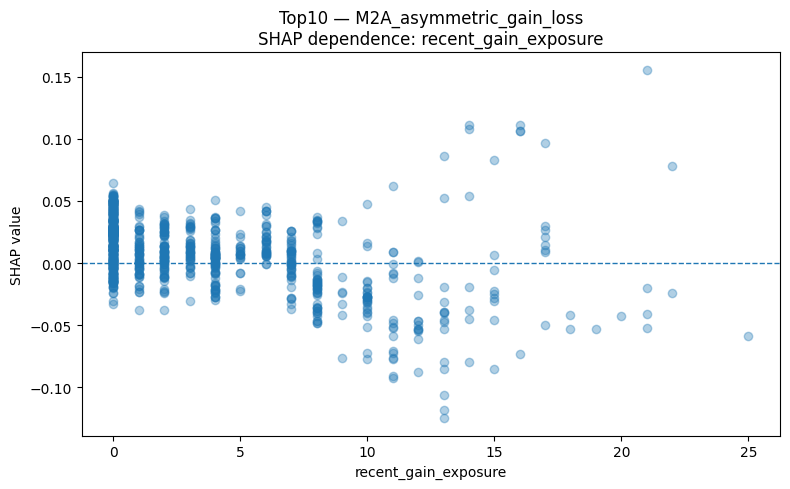

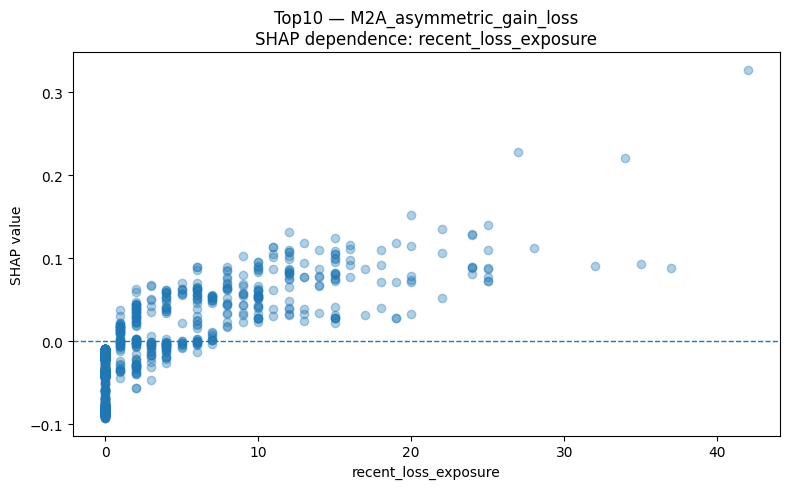

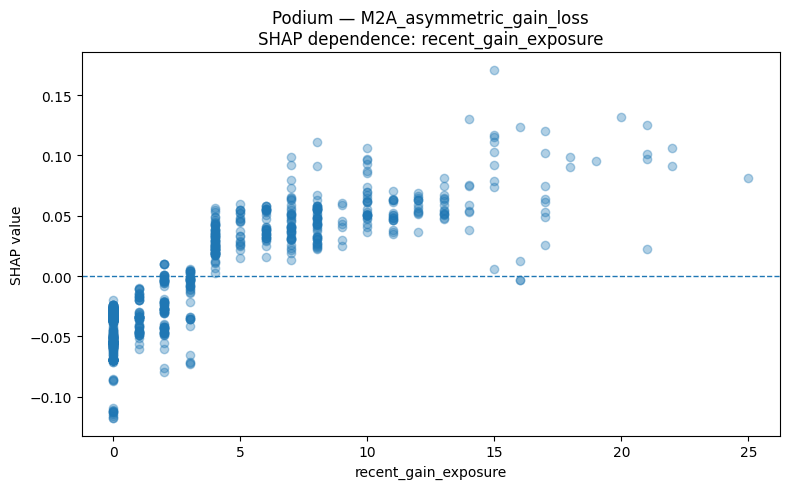

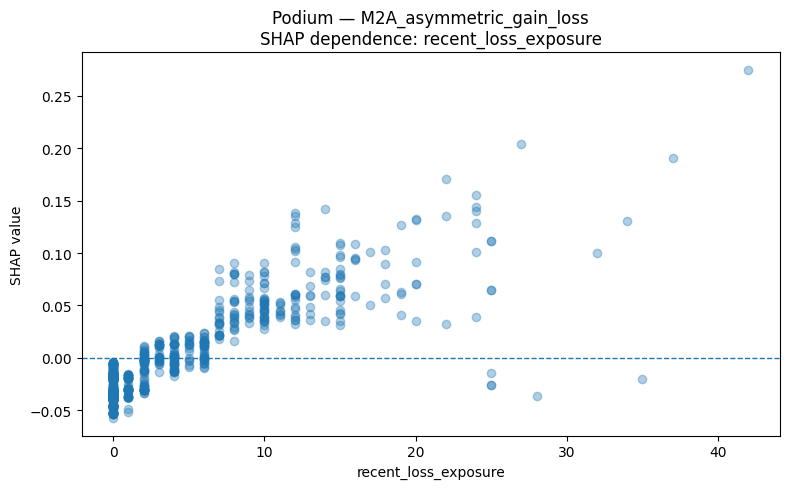

In [144]:
plot_shap_dependence(
    "Top10",
    "M2A_asymmetric_gain_loss",
    "recent_gain_exposure"
)

plot_shap_dependence(
    "Top10",
    "M2A_asymmetric_gain_loss",
    "recent_loss_exposure"
)

plot_shap_dependence(
    "Podium",
    "M2A_asymmetric_gain_loss",
    "recent_gain_exposure"
)

plot_shap_dependence(
    "Podium",
    "M2A_asymmetric_gain_loss",
    "recent_loss_exposure"
)

#### H1A:

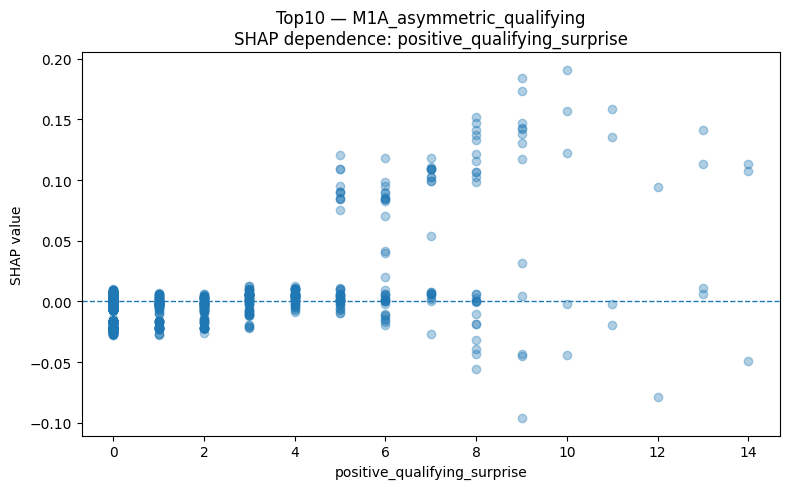

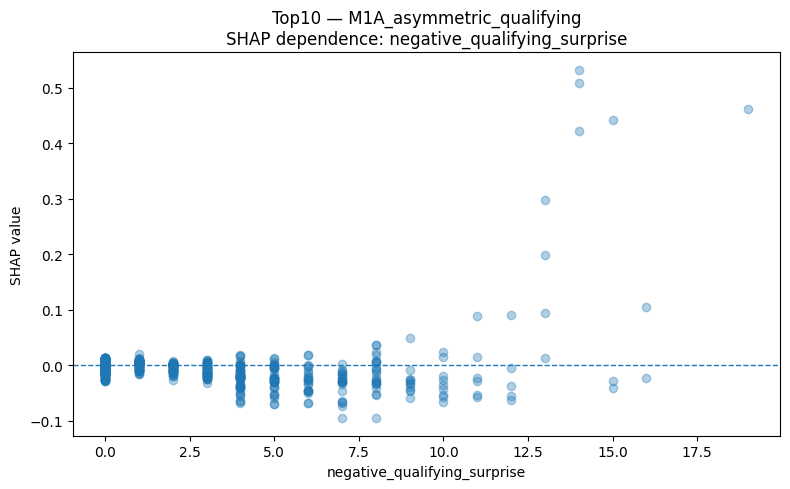

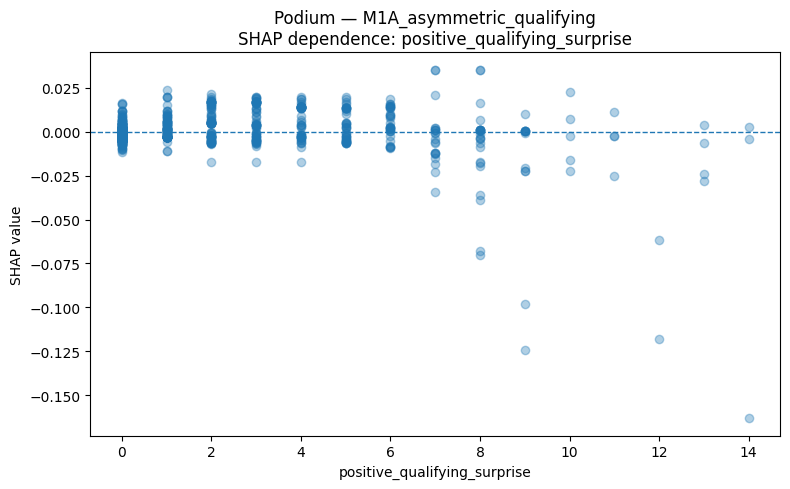

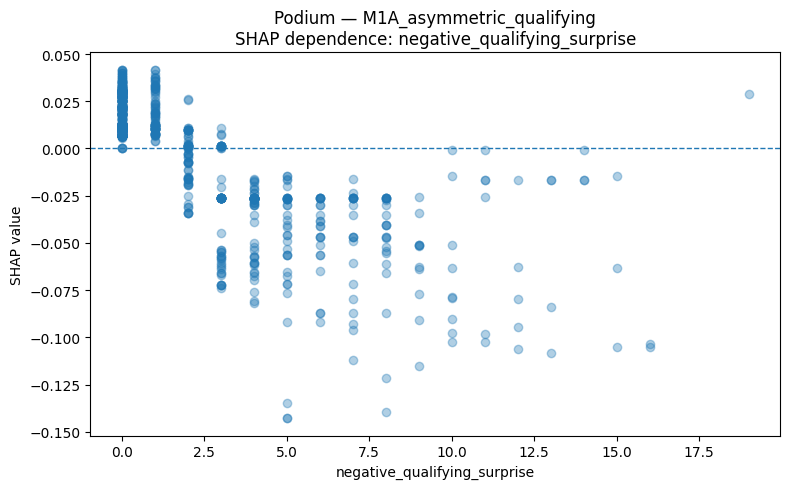

In [110]:
plot_shap_dependence(
    "Top10",
    "M1A_asymmetric_qualifying",
    "positive_qualifying_surprise"
)

plot_shap_dependence(
    "Top10",
    "M1A_asymmetric_qualifying",
    "negative_qualifying_surprise"
)

plot_shap_dependence(
    "Podium",
    "M1A_asymmetric_qualifying",
    "positive_qualifying_surprise"
)

plot_shap_dependence(
    "Podium",
    "M1A_asymmetric_qualifying",
    "negative_qualifying_surprise"
)

#### A useful direct asymmetry table (FOR RESULTS PAPER)

In [ ]:
# ------------------------------------------------------------
# KEY ASYMMETRIC SHAP COMPARISON
# ------------------------------------------------------------

asymmetry_features = [
    "positive_qualifying_surprise",
    "negative_qualifying_surprise",
    "recent_gain_exposure",
    "recent_loss_exposure"
]

asymmetry_shap_table = (
    shap_importance_pooled[
        shap_importance_pooled[
            "feature"
        ].isin(asymmetry_features)
    ]
    [
        [
            "target",
            "model",
            "feature",
            "mean_abs_shap",
            "importance_share",
            "importance_rank",
            #"mean_shap"
        ]
    ]
    .sort_values(
        [
            "target",
            "model",
            "mean_abs_shap"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
)

display(
    asymmetry_shap_table.round(4)
)

,target,model,feature,mean_abs_shap,importance_share,importance_rank
19,Podium,M1A_asymmetric_qualifying,negative_qualifying_surprise,0.0235,0.0108,10.0
21,Podium,M1A_asymmetric_qualifying,positive_qualifying_surprise,0.0056,0.0026,12.0
40,Podium,M2A_asymmetric_gain_loss,recent_gain_exposure,0.0413,0.0191,8.0
41,Podium,M2A_asymmetric_gain_loss,recent_loss_exposure,0.0320,0.0148,9.0
62,Podium,M3A_full_asymmetric,recent_loss_exposure,0.0497,0.0230,7.0
63,Podium,M3A_full_asymmetric,recent_gain_exposure,0.0426,0.0197,8.0
67,Podium,M3A_full_asymmetric,negative_qualifying_surprise,0.0255,0.0118,12.0
69,Podium,M3A_full_asymmetric,positive_qualifying_surprise,0.0033,0.0015,14.0
100,Top10,M1A_asymmetric_qualifying,positive_qualifying_surprise,0.0148,0.0077,9.0
101,Top10,M1A_asymmetric_qualifying,negative_qualifying_surprise,0.0143,0.0074,10.0


#### Save SHAP outputs

In [112]:
shap_values_df.to_csv(
    "catboost_shap_values_2023_2025.csv",
    index=False
)

shap_importance_yearly.to_csv(
    "catboost_shap_importance_yearly.csv",
    index=False
)

shap_importance_pooled.to_csv(
    "catboost_shap_importance_pooled.csv",
    index=False
)

asymmetry_shap_table.to_csv(
    "catboost_shap_asymmetry_table.csv",
    index=False
)

### binned SHAP dependence tables/plots for gain and loss exposure (FOR RESULTS PAPER)

TOP10 — RECENT GAIN EXPOSURE


,exposure_bin,n,mean_exposure,mean_shap,median_shap,ci_lower,ci_upper
0,0,478,0.0000,0.0205,0.0233,0.0187,0.0222
1,>0–2,144,1.5625,0.0078,0.0069,0.0051,0.0105
2,>2–5,147,3.8435,0.0062,0.0063,0.0035,0.0088
3,>5–10,168,7.6905,-0.0057,-0.0050,-0.0096,-0.0018
4,>10–15,62,12.6129,-0.0320,-0.0453,-0.0447,-0.0194
5,>15–20,16,17.1875,0.0135,0.0124,-0.0177,0.0446
6,>20,7,21.8571,0.0054,-0.0241,-0.0542,0.0651


TOP10 — RECENT LOSS EXPOSURE


,exposure_bin,n,mean_exposure,mean_shap,median_shap,ci_lower,ci_upper
0,0,576,0.0000,-0.0438,-0.0391,-0.0460,-0.0416
1,>0–2,126,1.5635,0.0026,0.0012,-0.0020,0.0072
2,>2–5,89,3.8764,0.0127,-0.0027,0.0063,0.0190
3,>5–10,123,7.8455,0.0453,0.0518,0.0405,0.0502
4,>10–15,64,13.1875,0.0745,0.0798,0.0671,0.0818
5,>15–20,21,18.1905,0.0803,0.0783,0.0656,0.0950
6,>20,23,26.9565,0.1174,0.0908,0.0919,0.1429


PODIUM — RECENT GAIN EXPOSURE


,exposure_bin,n,mean_exposure,mean_shap,median_shap,ci_lower,ci_upper
0,0,478,0.0000,-0.0424,-0.0341,-0.0440,-0.0408
1,>0–2,144,1.5625,-0.0293,-0.0309,-0.0322,-0.0264
2,>2–5,147,3.8435,0.0176,0.0227,0.0133,0.0218
3,>5–10,168,7.6905,0.0479,0.0470,0.0453,0.0506
4,>10–15,62,12.6129,0.0632,0.0587,0.0569,0.0694
5,>15–20,16,17.1875,0.0685,0.0692,0.0470,0.0900
6,>20,7,21.8571,0.0893,0.0971,0.0653,0.1133


PODIUM — RECENT LOSS EXPOSURE


,exposure_bin,n,mean_exposure,mean_shap,median_shap,ci_lower,ci_upper
0,0,576,0.0000,-0.0286,-0.0329,-0.0295,-0.0276
1,>0–2,126,1.5635,-0.0189,-0.0197,-0.0213,-0.0164
2,>2–5,89,3.8764,0.0033,0.0011,0.0011,0.0054
3,>5–10,123,7.8455,0.0360,0.0357,0.0317,0.0404
4,>10–15,64,13.1875,0.0672,0.0596,0.0602,0.0742
5,>15–20,21,18.1905,0.0831,0.0899,0.0708,0.0953
6,>20,23,26.9565,0.0947,0.1111,0.0607,0.1287


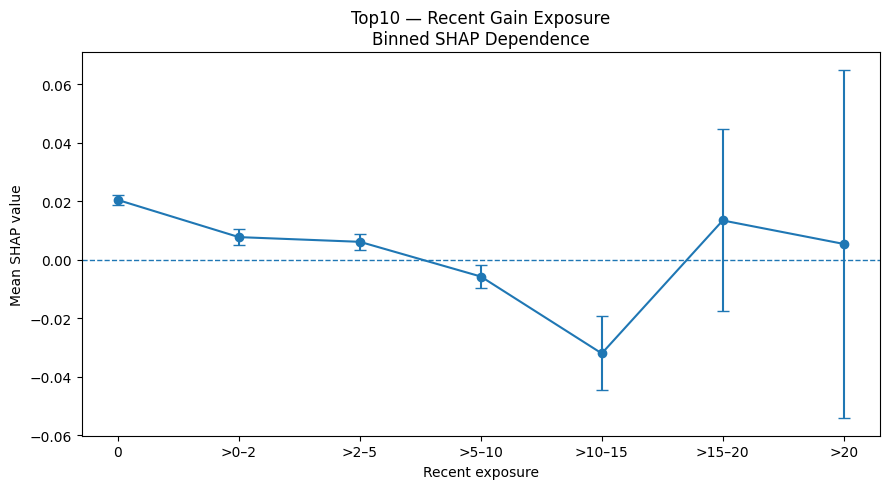

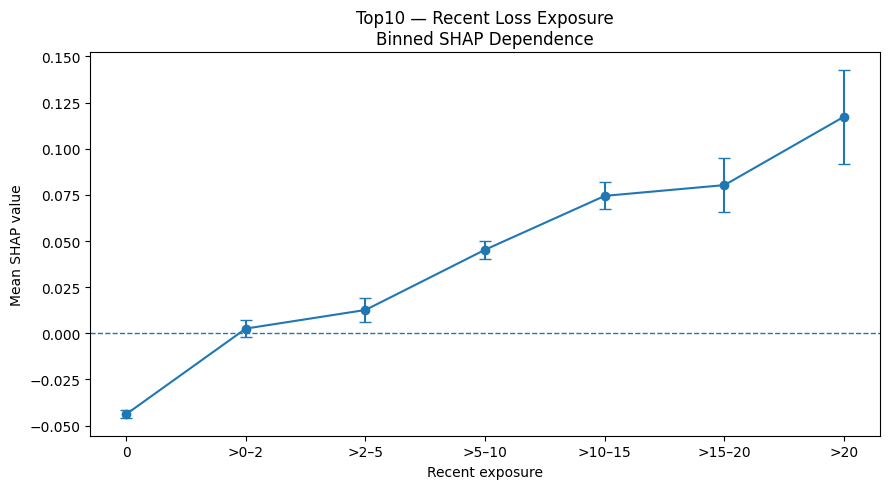

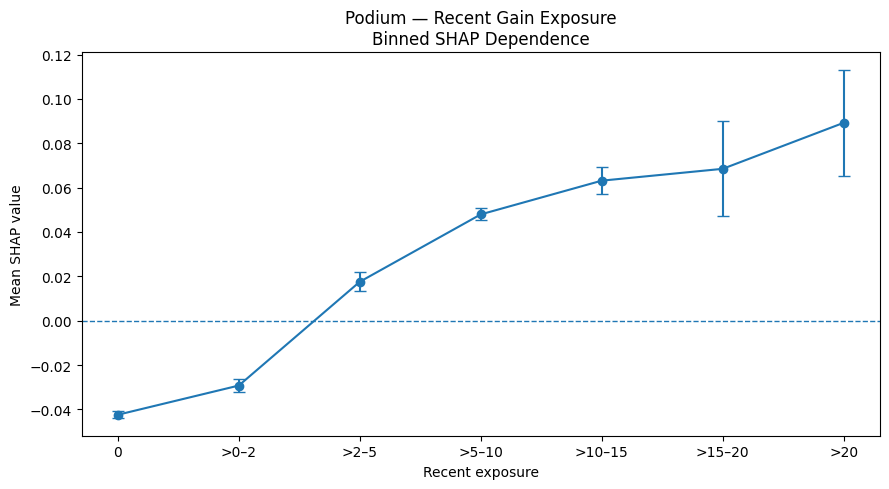

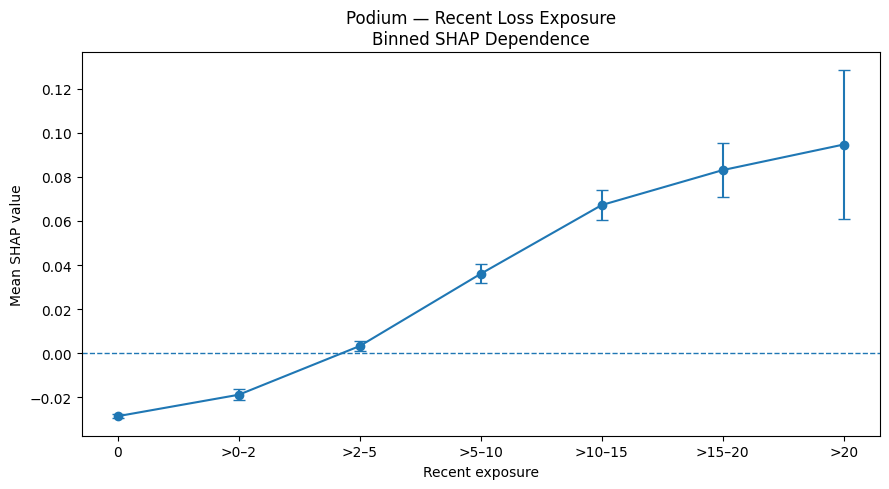

,target,feature,exposure_bin,n,mean_exposure,mean_shap,median_shap,ci_lower,ci_upper
0,Top10,recent_gain_exposure,0,478,0.0000,0.0205,0.0233,0.0187,0.0222
1,Top10,recent_gain_exposure,>0–2,144,1.5625,0.0078,0.0069,0.0051,0.0105
2,Top10,recent_gain_exposure,>2–5,147,3.8435,0.0062,0.0063,0.0035,0.0088
3,Top10,recent_gain_exposure,>5–10,168,7.6905,-0.0057,-0.0050,-0.0096,-0.0018
4,Top10,recent_gain_exposure,>10–15,62,12.6129,-0.0320,-0.0453,-0.0447,-0.0194
5,Top10,recent_gain_exposure,>15–20,16,17.1875,0.0135,0.0124,-0.0177,0.0446
6,Top10,recent_gain_exposure,>20,7,21.8571,0.0054,-0.0241,-0.0542,0.0651
7,Top10,recent_loss_exposure,0,576,0.0000,-0.0438,-0.0391,-0.0460,-0.0416
8,Top10,recent_loss_exposure,>0–2,126,1.5635,0.0026,0.0012,-0.0020,0.0072
9,Top10,recent_loss_exposure,>2–5,89,3.8764,0.0127,-0.0027,0.0063,0.0190


Saved to: d:\Data Science\Felipe Research\beyond-qualifying-position-formula-one\catboost_binned_shap_gain_loss.csv


In [ ]:
# ------------------------------------------------------------
# BINNED SHAP DEPENDENCE ANALYSIS
# Gain / Loss Exposure
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# BIN DEFINITIONS
# ------------------------------------------------------------

exposure_bins = [
    -0.001,
    0,
    2,
    5,
    10,
    15,
    20,
    np.inf
]

exposure_labels = [
    "0",
    ">0–2",
    ">2–5",
    ">5–10",
    ">10–15",
    ">15–20",
    ">20"
]


# ------------------------------------------------------------
# FUNCTION TO CREATE BINNED SHAP TABLE
# ------------------------------------------------------------

def create_binned_shap_table(
    target,
    model_name,
    feature
):

    temp = shap_values_df[
        (shap_values_df["target"] -- target) &
        (shap_values_df["model"] -- model_name) &
        (shap_values_df["feature"] -- feature)
    ].copy()

    # Make sure feature is numeric
    temp["feature_value"] = pd.to_numeric(
        temp["feature_value"],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=[
            "feature_value",
            "shap_value"
        ]
    )

    # --------------------------------------------------------
    # Create bins
    # --------------------------------------------------------

    temp["exposure_bin"] = pd.cut(
        temp["feature_value"],
        bins=exposure_bins,
        labels=exposure_labels,
        include_lowest=True,
        right=True
    )

    # --------------------------------------------------------
    # Aggregate
    # --------------------------------------------------------

    binned = (
        temp
        .groupby(
            "exposure_bin",
            observed=False
        )
        .agg(
            n=("shap_value", "size"),

            mean_exposure=(
                "feature_value",
                "mean"
            ),

            median_exposure=(
                "feature_value",
                "median"
            ),

            mean_shap=(
                "shap_value",
                "mean"
            ),

            median_shap=(
                "shap_value",
                "median"
            ),

            std_shap=(
                "shap_value",
                "std"
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Standard error and 95% descriptive interval
    # --------------------------------------------------------

    binned["se_shap"] = (
        binned["std_shap"]
        / np.sqrt(binned["n"])
    )

    binned["ci_lower"] = (
        binned["mean_shap"]
        - 1.96 * binned["se_shap"]
    )

    binned["ci_upper"] = (
        binned["mean_shap"]
        + 1.96 * binned["se_shap"]
    )

    binned["target"] = target
    binned["model"] = model_name
    binned["feature"] = feature

    return binned


# ------------------------------------------------------------
# CREATE FOUR MAIN TABLES
# M2A: Top10 + Podium × Gain + Loss
# ------------------------------------------------------------

top10_gain_binned = create_binned_shap_table(
    target="Top10",
    model_name="M2A_asymmetric_gain_loss",
    feature="recent_gain_exposure"
)

top10_loss_binned = create_binned_shap_table(
    target="Top10",
    model_name="M2A_asymmetric_gain_loss",
    feature="recent_loss_exposure"
)

podium_gain_binned = create_binned_shap_table(
    target="Podium",
    model_name="M2A_asymmetric_gain_loss",
    feature="recent_gain_exposure"
)

podium_loss_binned = create_binned_shap_table(
    target="Podium",
    model_name="M2A_asymmetric_gain_loss",
    feature="recent_loss_exposure"
)


# ------------------------------------------------------------
# DISPLAY TABLES
# ------------------------------------------------------------

print("TOP10 — RECENT GAIN EXPOSURE")

display(
    top10_gain_binned[
        [
            "exposure_bin",
            "n",
            "mean_exposure",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)


print("TOP10 — RECENT LOSS EXPOSURE")

display(
    top10_loss_binned[
        [
            "exposure_bin",
            "n",
            "mean_exposure",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)


print("PODIUM — RECENT GAIN EXPOSURE")

display(
    podium_gain_binned[
        [
            "exposure_bin",
            "n",
            "mean_exposure",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)


print("PODIUM — RECENT LOSS EXPOSURE")

display(
    podium_loss_binned[
        [
            "exposure_bin",
            "n",
            "mean_exposure",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# BINNED SHAP DEPENDENCE PLOT
# ------------------------------------------------------------

def plot_binned_shap(
    binned_df,
    title
):

    plot_df = binned_df[
        binned_df["n"] > 0
    ].copy()

    x = np.arange(
        len(plot_df)
    )

    y = plot_df[
        "mean_shap"
    ].values

    yerr_lower = (
        y
        - plot_df["ci_lower"].values
    )

    yerr_upper = (
        plot_df["ci_upper"].values
        - y
    )

    plt.figure(
        figsize=(9, 5)
    )

    plt.errorbar(
        x,
        y,
        yerr=[
            yerr_lower,
            yerr_upper
        ],
        marker="o",
        capsize=4
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xticks(
        x,
        plot_df["exposure_bin"],
        rotation=0
    )

    plt.xlabel(
        "Recent exposure"
    )

    plt.ylabel(
        "Mean SHAP value"
    )

    plt.title(title)

    plt.tight_layout()

    plt.show()

# ------------------------------------------------------------
# TOP10
# ------------------------------------------------------------

plot_binned_shap(
    top10_gain_binned,
    "Top10 — Recent Gain Exposure\nBinned SHAP Dependence"
)

plot_binned_shap(
    top10_loss_binned,
    "Top10 — Recent Loss Exposure\nBinned SHAP Dependence"
)


# ------------------------------------------------------------
# PODIUM
# ------------------------------------------------------------

plot_binned_shap(
    podium_gain_binned,
    "Podium — Recent Gain Exposure\nBinned SHAP Dependence"
)

plot_binned_shap(
    podium_loss_binned,
    "Podium — Recent Loss Exposure\nBinned SHAP Dependence"
)

# ------------------------------------------------------------
# COMBINE ALL BINNED RESULTS
# ------------------------------------------------------------

binned_shap_results = pd.concat(
    [
        top10_gain_binned,
        top10_loss_binned,
        podium_gain_binned,
        podium_loss_binned
    ],
    ignore_index=True
)


display(
    binned_shap_results[
        [
            "target",
            "feature",
            "exposure_bin",
            "n",
            "mean_exposure",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)

# binned_shap_results.to_csv(
#     "catboost_binned_shap_gain_loss.csv",
#     index=False
# )

from pathlib import Path

output_file = Path.cwd() / "catboost_binned_shap_gain_loss.csv"

binned_qualifying_shap_results.to_csv(
    output_file,
    index=False
)

print(f"Saved to: {output_file}")

### binned SHAP dependence tables/plots for Positive / Negative Qualifying Surprise (FOR RESULTS PAPER)

TOP10 — POSITIVE QUALIFYING SURPRISE


,surprise_bin,n,mean_surprise,mean_shap,median_shap,ci_lower,ci_upper
0,0,552,0.0000,-0.0059,-0.0022,-0.0068,-0.0051
1,>0–2,197,1.4619,-0.0065,-0.0022,-0.0078,-0.0052
2,>2–5,162,3.8642,0.0078,0.0041,0.0041,0.0116
3,>5–10,98,7.3265,0.0487,0.0086,0.0356,0.0619
4,>10–15,13,12.4615,0.0564,0.0947,0.0127,0.1001
5,>15–20,0,NaN,NaN,NaN,NaN,NaN
6,>20,0,NaN,NaN,NaN,NaN,NaN


TOP10 — NEGATIVE QUALIFYING SURPRISE


,surprise_bin,n,mean_surprise,mean_shap,median_shap,ci_lower,ci_upper
0,0,589,0.0000,0.0006,0.0033,-0.0001,0.0012
1,>0–2,160,1.4562,-0.0009,-0.0000,-0.0021,0.0003
2,>2–5,161,3.8509,-0.0178,-0.0168,-0.0206,-0.0150
3,>5–10,88,7.5568,-0.0261,-0.0278,-0.0319,-0.0203
4,>10–15,21,12.6190,0.1097,0.0121,0.0224,0.1970
5,>15–20,3,17.0000,0.1813,0.1054,-0.1037,0.4663
6,>20,0,NaN,NaN,NaN,NaN,NaN


PODIUM — POSITIVE QUALIFYING SURPRISE


,surprise_bin,n,mean_surprise,mean_shap,median_shap,ci_lower,ci_upper
0,0,552,0.0000,-0.0006,-0.0001,-0.0008,-0.0003
1,>0–2,197,1.4619,0.0032,0.0014,0.0022,0.0043
2,>2–5,162,3.8642,0.0050,0.0040,0.0036,0.0064
3,>5–10,98,7.3265,-0.0038,0.0007,-0.0083,0.0008
4,>10–15,13,12.4615,-0.0321,-0.0063,-0.0607,-0.0035
5,>15–20,0,NaN,NaN,NaN,NaN,NaN
6,>20,0,NaN,NaN,NaN,NaN,NaN


PODIUM — NEGATIVE QUALIFYING SURPRISE


,surprise_bin,n,mean_surprise,mean_shap,median_shap,ci_lower,ci_upper
0,0,589,0.0000,0.0166,0.0124,0.0158,0.0173
1,>0–2,160,1.4562,0.0079,0.0099,0.0053,0.0105
2,>2–5,161,3.8509,-0.0370,-0.0266,-0.0410,-0.0329
3,>5–10,88,7.5568,-0.0515,-0.0471,-0.0573,-0.0458
4,>10–15,21,12.6190,-0.0507,-0.0255,-0.0682,-0.0332
5,>15–20,3,17.0000,-0.0600,-0.1037,-0.1470,0.0270
6,>20,0,NaN,NaN,NaN,NaN,NaN


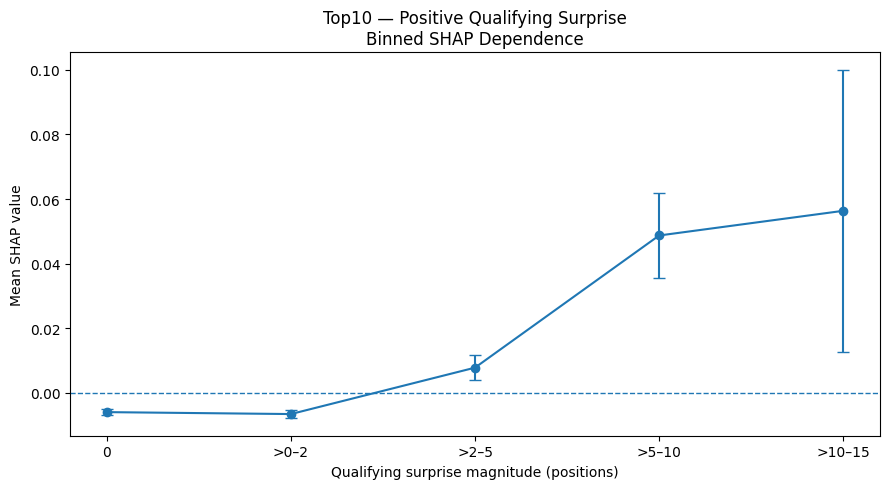

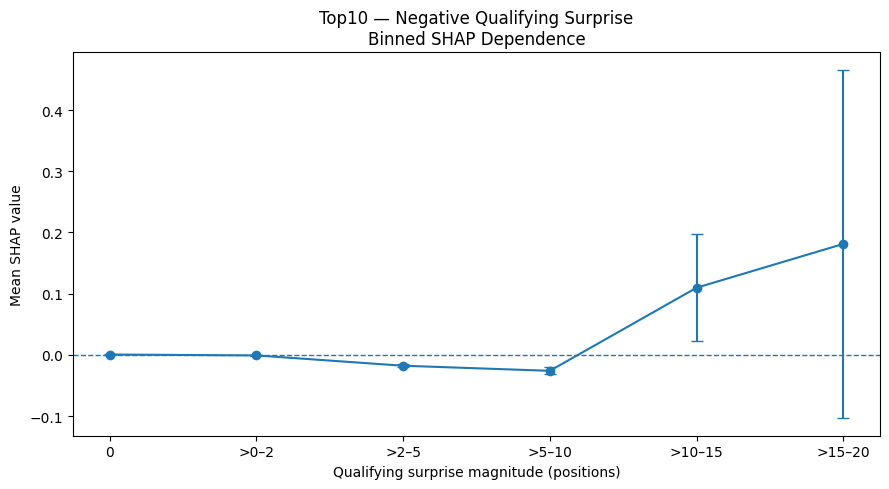

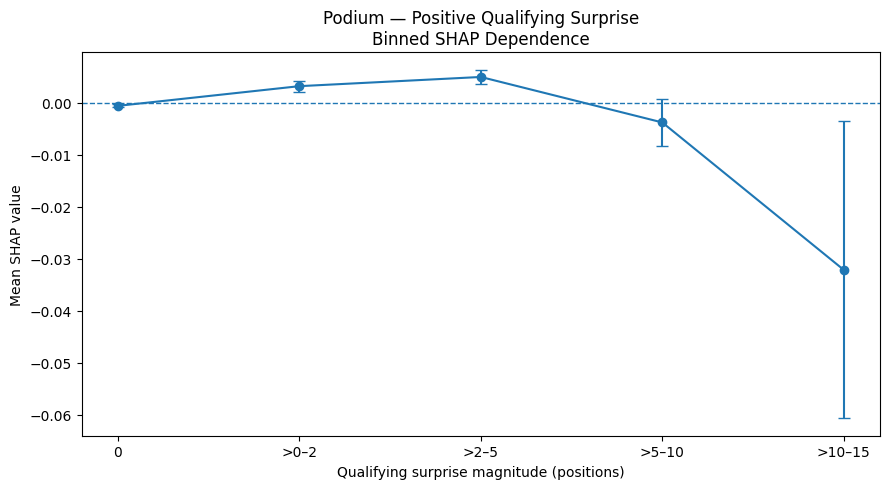

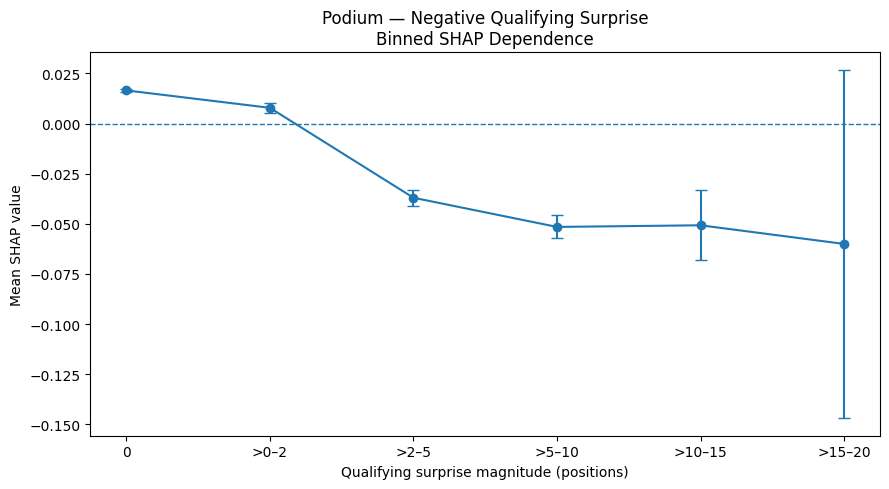

,target,feature,surprise_bin,n,mean_surprise,mean_shap,median_shap,ci_lower,ci_upper
0,Top10,positive_qualifying_surprise,0,552,0.0000,-0.0059,-0.0022,-0.0068,-0.0051
1,Top10,positive_qualifying_surprise,>0–2,197,1.4619,-0.0065,-0.0022,-0.0078,-0.0052
2,Top10,positive_qualifying_surprise,>2–5,162,3.8642,0.0078,0.0041,0.0041,0.0116
3,Top10,positive_qualifying_surprise,>5–10,98,7.3265,0.0487,0.0086,0.0356,0.0619
4,Top10,positive_qualifying_surprise,>10–15,13,12.4615,0.0564,0.0947,0.0127,0.1001
5,Top10,positive_qualifying_surprise,>15–20,0,NaN,NaN,NaN,NaN,NaN
6,Top10,positive_qualifying_surprise,>20,0,NaN,NaN,NaN,NaN,NaN
7,Top10,negative_qualifying_surprise,0,589,0.0000,0.0006,0.0033,-0.0001,0.0012
8,Top10,negative_qualifying_surprise,>0–2,160,1.4562,-0.0009,-0.0000,-0.0021,0.0003
9,Top10,negative_qualifying_surprise,>2–5,161,3.8509,-0.0178,-0.0168,-0.0206,-0.0150


Saved to: d:\Data Science\Felipe Research\beyond-qualifying-position-formula-one\catboost_binned_shap_qualifying_surprise.csv


In [ ]:
# ------------------------------------------------------------
# BINNED SHAP DEPENDENCE ANALYSIS
# Positive / Negative Qualifying Surprise
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# BIN DEFINITIONS
# ------------------------------------------------------------

qualifying_bins = [
    -0.001,
    0,
    2,
    5,
    10,
    15,
    20,
    np.inf
]

qualifying_labels = [
    "0",
    ">0–2",
    ">2–5",
    ">5–10",
    ">10–15",
    ">15–20",
    ">20"
]


# ------------------------------------------------------------
# FUNCTION TO CREATE BINNED SHAP TABLE
# ------------------------------------------------------------

def create_binned_qualifying_shap_table(
    target,
    model_name,
    feature
):

    temp = shap_values_df[
        (shap_values_df["target"] -- target) &
        (shap_values_df["model"] -- model_name) &
        (shap_values_df["feature"] -- feature)
    ].copy()

    # Make sure feature is numeric
    temp["feature_value"] = pd.to_numeric(
        temp["feature_value"],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=[
            "feature_value",
            "shap_value"
        ]
    )

    # --------------------------------------------------------
    # Create bins
    # --------------------------------------------------------

    temp["surprise_bin"] = pd.cut(
        temp["feature_value"],
        bins=qualifying_bins,
        labels=qualifying_labels,
        include_lowest=True,
        right=True
    )

    # --------------------------------------------------------
    # Aggregate
    # --------------------------------------------------------

    binned = (
        temp
        .groupby(
            "surprise_bin",
            observed=False
        )
        .agg(
            n=("shap_value", "size"),

            mean_surprise=(
                "feature_value",
                "mean"
            ),

            median_surprise=(
                "feature_value",
                "median"
            ),

            mean_shap=(
                "shap_value",
                "mean"
            ),

            median_shap=(
                "shap_value",
                "median"
            ),

            std_shap=(
                "shap_value",
                "std"
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Standard error and 95% descriptive interval
    # --------------------------------------------------------

    binned["se_shap"] = (
        binned["std_shap"]
        / np.sqrt(binned["n"])
    )

    binned["ci_lower"] = (
        binned["mean_shap"]
        - 1.96 * binned["se_shap"]
    )

    binned["ci_upper"] = (
        binned["mean_shap"]
        + 1.96 * binned["se_shap"]
    )

    binned["target"] = target
    binned["model"] = model_name
    binned["feature"] = feature

    return binned


# ------------------------------------------------------------
# CREATE FOUR MAIN TABLES
# M1A: Top10 + Podium × Positive + Negative Surprise
# ------------------------------------------------------------

top10_positive_q_binned = create_binned_qualifying_shap_table(
    target="Top10",
    model_name="M1A_asymmetric_qualifying",
    feature="positive_qualifying_surprise"
)

top10_negative_q_binned = create_binned_qualifying_shap_table(
    target="Top10",
    model_name="M1A_asymmetric_qualifying",
    feature="negative_qualifying_surprise"
)

podium_positive_q_binned = create_binned_qualifying_shap_table(
    target="Podium",
    model_name="M1A_asymmetric_qualifying",
    feature="positive_qualifying_surprise"
)

podium_negative_q_binned = create_binned_qualifying_shap_table(
    target="Podium",
    model_name="M1A_asymmetric_qualifying",
    feature="negative_qualifying_surprise"
)


# ------------------------------------------------------------
# DISPLAY TABLES
# ------------------------------------------------------------

print("TOP10 — POSITIVE QUALIFYING SURPRISE")

display(
    top10_positive_q_binned[
        [
            "surprise_bin",
            "n",
            "mean_surprise",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)


print("TOP10 — NEGATIVE QUALIFYING SURPRISE")

display(
    top10_negative_q_binned[
        [
            "surprise_bin",
            "n",
            "mean_surprise",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)


print("PODIUM — POSITIVE QUALIFYING SURPRISE")

display(
    podium_positive_q_binned[
        [
            "surprise_bin",
            "n",
            "mean_surprise",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)


print("PODIUM — NEGATIVE QUALIFYING SURPRISE")

display(
    podium_negative_q_binned[
        [
            "surprise_bin",
            "n",
            "mean_surprise",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# BINNED SHAP DEPENDENCE PLOT
# ------------------------------------------------------------

def plot_binned_qualifying_shap(
    binned_df,
    title
):

    plot_df = binned_df[
        binned_df["n"] > 0
    ].copy()

    x = np.arange(
        len(plot_df)
    )

    y = plot_df[
        "mean_shap"
    ].values

    yerr_lower = (
        y
        - plot_df["ci_lower"].values
    )

    yerr_upper = (
        plot_df["ci_upper"].values
        - y
    )

    plt.figure(
        figsize=(9, 5)
    )

    plt.errorbar(
        x,
        y,
        yerr=[
            yerr_lower,
            yerr_upper
        ],
        marker="o",
        capsize=4
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xticks(
        x,
        plot_df["surprise_bin"],
        rotation=0
    )

    plt.xlabel(
        "Qualifying surprise magnitude (positions)"
    )

    plt.ylabel(
        "Mean SHAP value"
    )

    plt.title(title)

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# TOP10
# ------------------------------------------------------------

plot_binned_qualifying_shap(
    top10_positive_q_binned,
    "Top10 — Positive Qualifying Surprise\nBinned SHAP Dependence"
)

plot_binned_qualifying_shap(
    top10_negative_q_binned,
    "Top10 — Negative Qualifying Surprise\nBinned SHAP Dependence"
)


# ------------------------------------------------------------
# PODIUM
# ------------------------------------------------------------

plot_binned_qualifying_shap(
    podium_positive_q_binned,
    "Podium — Positive Qualifying Surprise\nBinned SHAP Dependence"
)

plot_binned_qualifying_shap(
    podium_negative_q_binned,
    "Podium — Negative Qualifying Surprise\nBinned SHAP Dependence"
)


# ------------------------------------------------------------
# COMBINE ALL BINNED RESULTS
# ------------------------------------------------------------

binned_qualifying_shap_results = pd.concat(
    [
        top10_positive_q_binned,
        top10_negative_q_binned,
        podium_positive_q_binned,
        podium_negative_q_binned
    ],
    ignore_index=True
)


display(
    binned_qualifying_shap_results[
        [
            "target",
            "feature",
            "surprise_bin",
            "n",
            "mean_surprise",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

# binned_qualifying_shap_results.to_csv(
#     "catboost_binned_shap_qualifying_surprise.csv",
#     index=False
# )

from pathlib import Path

output_file = Path.cwd() / "catboost_binned_shap_qualifying_surprise.csv"

binned_qualifying_shap_results.to_csv(
    output_file,
    index=False
)

print(f"Saved to: {output_file}")

### Do the main behavioral SHAP patterns remain reasonably stable across 2023, 2024, and 2025?

- Did the loss/negative side have greater SHAP influence in all three held-out seasons?

In [ ]:
# ------------------------------------------------------------
# SHAP ROBUSTNESS CHECK 1
# YEAR-BY-YEAR STABILITY — 2023, 2024, 2025
# ------------------------------------------------------------

import pandas as pd
import numpy as np
from scipy.stats import spearmanr


# ------------------------------------------------------------
# ADD YEAR-SPECIFIC IMPORTANCE SHARE
# ------------------------------------------------------------

shap_yearly = shap_importance_yearly.copy()

shap_yearly["importance_share"] = (
    shap_yearly["mean_abs_shap"]
    /
    shap_yearly
    .groupby(
        [
            "target",
            "model",
            "test_year"
        ]
    )["mean_abs_shap"]
    .transform("sum")
)


# ------------------------------------------------------------
# BEHAVIORAL FEATURES OF INTEREST
# ------------------------------------------------------------

behavioral_features = [
    "positive_qualifying_surprise",
    "negative_qualifying_surprise",
    "recent_gain_exposure",
    "recent_loss_exposure"
]

models_of_interest = [
    "M1A_asymmetric_qualifying",
    "M2A_asymmetric_gain_loss",
    "M3A_full_asymmetric"
]


behavioral_shap_yearly = shap_yearly[
    (
        shap_yearly["model"].isin(models_of_interest)
    )
    &
    (
        shap_yearly["feature"].isin(behavioral_features)
    )
].copy()


display(
    behavioral_shap_yearly[
        [
            "target",
            "model",
            "test_year",
            "feature",
            "mean_abs_shap",
            "importance_share",
            "importance_rank",
            "mean_shap"
        ]
    ]
    .sort_values(
        [
            "target",
            "model",
            "feature",
            "test_year"
        ]
    )
    .round(4)
)

# ------------------------------------------------------------
# YEARLY MEAN ABSOLUTE SHAP — WIDE TABLE
# ------------------------------------------------------------

shap_yearly_wide = (
    behavioral_shap_yearly
    .pivot_table(
        index=[
            "target",
            "model",
            "feature"
        ],
        columns="test_year",
        values="mean_abs_shap"
    )
)

display(
    shap_yearly_wide.round(4)
)

# ------------------------------------------------------------
# FEATURE-LEVEL STABILITY SUMMARY
# ------------------------------------------------------------

shap_stability_summary = (
    behavioral_shap_yearly
    .groupby(
        [
            "target",
            "model",
            "feature"
        ]
    )
    .agg(
        mean_2023_2025=(
            "mean_abs_shap",
            "mean"
        ),

        std_2023_2025=(
            "mean_abs_shap",
            "std"
        ),

        min_year=(
            "mean_abs_shap",
            "min"
        ),

        max_year=(
            "mean_abs_shap",
            "max"
        ),

        mean_rank=(
            "importance_rank",
            "mean"
        ),

        min_rank=(
            "importance_rank",
            "min"
        ),

        max_rank=(
            "importance_rank",
            "max"
        )
    )
    .reset_index()
)


# Coefficient of variation
shap_stability_summary["cv"] = (
    shap_stability_summary["std_2023_2025"]
    /
    shap_stability_summary["mean_2023_2025"]
)


display(
    shap_stability_summary.round(4)
)

# ------------------------------------------------------------
# ASYMMETRY ORDERING BY YEAR
# ------------------------------------------------------------

asymmetry_yearly_records = []


for target in ["Top10", "Podium"]:

    for year in [2023, 2024, 2025]:

        # ----------------------------------------------------
        # M1A — Positive vs Negative Qualifying Surprise
        # ----------------------------------------------------

        m1a = behavioral_shap_yearly[
            (behavioral_shap_yearly["target"] -- target) &
            (
                behavioral_shap_yearly["model"]
                -- "M1A_asymmetric_qualifying"
            ) &
            (
                behavioral_shap_yearly["test_year"]
                -- year
            )
        ]

        positive_q = m1a.loc[
            m1a["feature"]
            -- "positive_qualifying_surprise",
            "mean_abs_shap"
        ]

        negative_q = m1a.loc[
            m1a["feature"]
            -- "negative_qualifying_surprise",
            "mean_abs_shap"
        ]

        if (
            len(positive_q) > 0
            and len(negative_q) > 0
        ):

            positive_q = positive_q.iloc[0]
            negative_q = negative_q.iloc[0]

            asymmetry_yearly_records.append({
                "target": target,
                "test_year": year,
                "comparison":
                    "Qualifying surprise",
                "positive_or_gain":
                    positive_q,
                "negative_or_loss":
                    negative_q,
                "ratio_negative_to_positive":
                    negative_q / positive_q
                    if positive_q != 0
                    else np.nan,
                "negative_or_loss_larger":
                    negative_q > positive_q
            })


        # ----------------------------------------------------
        # M2A — Gain vs Loss Exposure
        # ----------------------------------------------------

        m2a = behavioral_shap_yearly[
            (behavioral_shap_yearly["target"] -- target) &
            (
                behavioral_shap_yearly["model"]
                -- "M2A_asymmetric_gain_loss"
            ) &
            (
                behavioral_shap_yearly["test_year"]
                -- year
            )
        ]

        gain = m2a.loc[
            m2a["feature"]
            -- "recent_gain_exposure",
            "mean_abs_shap"
        ]

        loss = m2a.loc[
            m2a["feature"]
            -- "recent_loss_exposure",
            "mean_abs_shap"
        ]

        if (
            len(gain) > 0
            and len(loss) > 0
        ):

            gain = gain.iloc[0]
            loss = loss.iloc[0]

            asymmetry_yearly_records.append({
                "target": target,
                "test_year": year,
                "comparison":
                    "Gain-loss exposure",
                "positive_or_gain":
                    gain,
                "negative_or_loss":
                    loss,
                "ratio_negative_to_positive":
                    loss / gain
                    if gain != 0
                    else np.nan,
                "negative_or_loss_larger":
                    loss > gain
            })


asymmetry_yearly = pd.DataFrame(
    asymmetry_yearly_records
)


display(
    asymmetry_yearly.round(4)
)

# ------------------------------------------------------------
# OVERALL FEATURE-RANKING STABILITY
# SPEARMAN CORRELATION ACROSS YEARS
# ------------------------------------------------------------

rank_stability_records = []

year_pairs = [
    (2023, 2024),
    (2023, 2025),
    (2024, 2025)
]


for target in ["Top10", "Podium"]:

    for model_name in models_of_interest:

        temp = shap_yearly[
            (shap_yearly["target"] -- target) &
            (shap_yearly["model"] -- model_name)
        ].copy()

        for year_1, year_2 in year_pairs:

            a = temp[
                temp["test_year"] -- year_1
            ][
                [
                    "feature",
                    "mean_abs_shap"
                ]
            ].rename(
                columns={
                    "mean_abs_shap":
                        "importance_1"
                }
            )

            b = temp[
                temp["test_year"] -- year_2
            ][
                [
                    "feature",
                    "mean_abs_shap"
                ]
            ].rename(
                columns={
                    "mean_abs_shap":
                        "importance_2"
                }
            )

            merged = a.merge(
                b,
                on="feature",
                how="inner"
            )

            rho, p_value = spearmanr(
                merged["importance_1"],
                merged["importance_2"]
            )

            rank_stability_records.append({
                "target": target,
                "model": model_name,
                "year_1": year_1,
                "year_2": year_2,
                "spearman_rho": rho,
                "p_value": p_value,
                "n_features": len(merged)
            })


shap_rank_stability = pd.DataFrame(
    rank_stability_records
)


display(
    shap_rank_stability.round(4)
)

,target,model,test_year,feature,mean_abs_shap,importance_share,importance_rank,mean_shap
278,Podium,M1A_asymmetric_qualifying,2023,negative_qualifying_surprise,0.0135,0.0063,10.0,-0.0019
360,Podium,M1A_asymmetric_qualifying,2024,negative_qualifying_surprise,0.0175,0.0073,10.0,0.0011
442,Podium,M1A_asymmetric_qualifying,2025,negative_qualifying_surprise,0.0384,0.0192,7.0,-0.0014
277,Podium,M1A_asymmetric_qualifying,2023,positive_qualifying_surprise,0.0043,0.0020,12.0,0.0004
359,Podium,M1A_asymmetric_qualifying,2024,positive_qualifying_surprise,0.0035,0.0015,12.0,-0.0002
441,Podium,M1A_asymmetric_qualifying,2025,positive_qualifying_surprise,0.0090,0.0045,11.0,0.0009
300,Podium,M2A_asymmetric_gain_loss,2023,recent_gain_exposure,0.0546,0.0260,8.0,-0.0211
382,Podium,M2A_asymmetric_gain_loss,2024,recent_gain_exposure,0.0376,0.0162,8.0,-0.0067
464,Podium,M2A_asymmetric_gain_loss,2025,recent_gain_exposure,0.0331,0.0161,9.0,0.0023
301,Podium,M2A_asymmetric_gain_loss,2023,recent_loss_exposure,0.0421,0.0200,9.0,-0.0097


test_year                                                        2023    2024  \
target model                     feature                                        
Podium M1A_asymmetric_qualifying negative_qualifying_surprise  0.0135  0.0175   
                                 positive_qualifying_surprise  0.0043  0.0035   
       M2A_asymmetric_gain_loss  recent_gain_exposure          0.0546  0.0376   
                                 recent_loss_exposure          0.0421  0.0189   
       M3A_full_asymmetric       negative_qualifying_surprise  0.0351  0.0209   
                                 positive_qualifying_surprise  0.0036  0.0032   
                                 recent_gain_exposure          0.0552  0.0276   
                                 recent_loss_exposure          0.0523  0.0503   
Top10  M1A_asymmetric_qualifying negative_qualifying_surprise  0.0240  0.0095   
                                 positive_qualifying_surprise  0.0372  0.0033   
       M2A_asymmetric_gain_loss  recent_gain_exposure          0.0279  0.0259   
                                 recent_loss_exposure          0.0720  0.0169   
       M3A_full_asymmetric       negative_qualifying_surprise  0.0221  0.0216   
                                 positive_qualifying_surprise  0.0349  0.0046   
                                 recent_gain_exposure          0.0189  0.0228   
                                 recent_loss_exposure          0.0731  0.0430   

test_year                                                        2025  
target model                     feature                               
Podium M1A_asymmetric_qualifying negative_qualifying_surprise  0.0384  
                                 positive_qualifying_surprise  0.0090  
       M2A_asymmetric_gain_loss  recent_gain_exposure          0.0331  
                                 recent_loss_exposure          0.0362  
       M3A_full_asymmetric       negative_qualifying_surprise  0.0215  
                                 positive_qualifying_surprise  0.0031  
                                 recent_gain_exposure          0.0464  
                                 recent_loss_exposure          0.0466  
Top10  M1A_asymmetric_qualifying negative_qualifying_surprise  0.0103  
                                 positive_qualifying_surprise  0.0064  
       M2A_asymmetric_gain_loss  recent_gain_exposure          0.0160  
                                 recent_loss_exposure          0.0458  
       M3A_full_asymmetric       negative_qualifying_surprise  0.0059  
                                 positive_qualifying_surprise  0.0023  
                                 recent_gain_exposure          0.0139  
                                 recent_loss_exposure          0.0547

,target,model,feature,mean_2023_2025,std_2023_2025,min_year,max_year,mean_rank,min_rank,max_rank,cv
0,Podium,M1A_asymmetric_qualifying,negative_qualifying_surprise,0.0231,0.0134,0.0135,0.0384,9.0000,7.0,10.0,0.5789
1,Podium,M1A_asymmetric_qualifying,positive_qualifying_surprise,0.0056,0.0030,0.0035,0.0090,11.6667,11.0,12.0,0.5304
2,Podium,M2A_asymmetric_gain_loss,recent_gain_exposure,0.0418,0.0113,0.0331,0.0546,8.3333,8.0,9.0,0.2707
3,Podium,M2A_asymmetric_gain_loss,recent_loss_exposure,0.0324,0.0121,0.0189,0.0421,9.3333,8.0,11.0,0.3723
4,Podium,M3A_full_asymmetric,negative_qualifying_surprise,0.0258,0.0080,0.0209,0.0351,11.0000,11.0,11.0,0.3114
5,Podium,M3A_full_asymmetric,positive_qualifying_surprise,0.0033,0.0002,0.0031,0.0036,14.0000,14.0,14.0,0.0677
6,Podium,M3A_full_asymmetric,recent_gain_exposure,0.0431,0.0141,0.0276,0.0552,9.0000,8.0,10.0,0.3271
7,Podium,M3A_full_asymmetric,recent_loss_exposure,0.0498,0.0029,0.0466,0.0523,8.0000,7.0,9.0,0.0578
8,Top10,M1A_asymmetric_qualifying,negative_qualifying_surprise,0.0146,0.0081,0.0095,0.0240,9.6667,9.0,10.0,0.5559
9,Top10,M1A_asymmetric_qualifying,positive_qualifying_surprise,0.0156,0.0187,0.0033,0.0372,9.6667,8.0,11.0,1.1985


,target,test_year,comparison,positive_or_gain,negative_or_loss,ratio_negative_to_positive,negative_or_loss_larger
0,Top10,2023,Qualifying surprise,0.0372,0.0240,0.6446,False
1,Top10,2023,Gain-loss exposure,0.0279,0.0720,2.5854,True
2,Top10,2024,Qualifying surprise,0.0033,0.0095,2.8799,True
3,Top10,2024,Gain-loss exposure,0.0259,0.0169,0.6518,False
4,Top10,2025,Qualifying surprise,0.0064,0.0103,1.6152,True
5,Top10,2025,Gain-loss exposure,0.0160,0.0458,2.8552,True
6,Podium,2023,Qualifying surprise,0.0043,0.0135,3.1164,True
7,Podium,2023,Gain-loss exposure,0.0546,0.0421,0.7704,False
8,Podium,2024,Qualifying surprise,0.0035,0.0175,5.0286,True
9,Podium,2024,Gain-loss exposure,0.0376,0.0189,0.5013,False


,target,model,year_1,year_2,spearman_rho,p_value,n_features
0,Top10,M1A_asymmetric_qualifying,2023,2024,0.9441,0.0000,12
1,Top10,M1A_asymmetric_qualifying,2023,2025,0.9580,0.0000,12
2,Top10,M1A_asymmetric_qualifying,2024,2025,0.9720,0.0000,12
3,Top10,M2A_asymmetric_gain_loss,2023,2024,0.8881,0.0001,12
4,Top10,M2A_asymmetric_gain_loss,2023,2025,0.9580,0.0000,12
5,Top10,M2A_asymmetric_gain_loss,2024,2025,0.9371,0.0000,12
6,Top10,M3A_full_asymmetric,2023,2024,0.8989,0.0000,14
7,Top10,M3A_full_asymmetric,2023,2025,0.8813,0.0000,14
8,Top10,M3A_full_asymmetric,2024,2025,0.9692,0.0000,14
9,Podium,M1A_asymmetric_qualifying,2023,2024,0.9720,0.0000,12


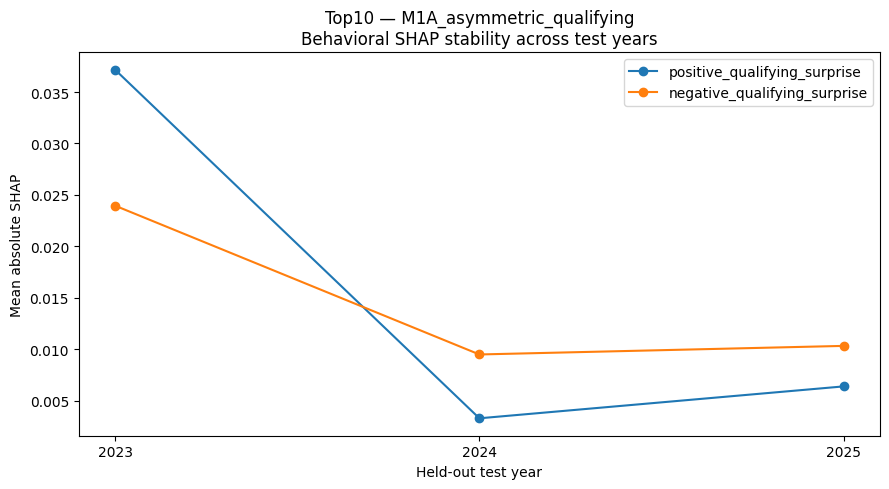

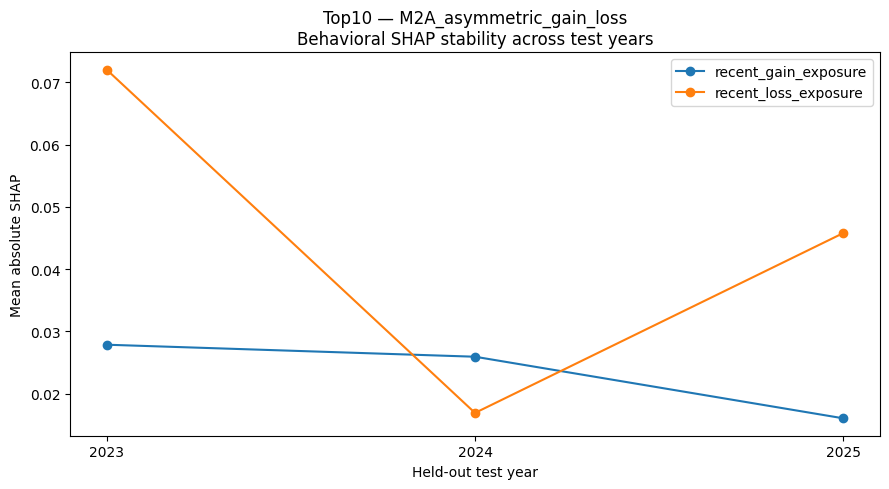

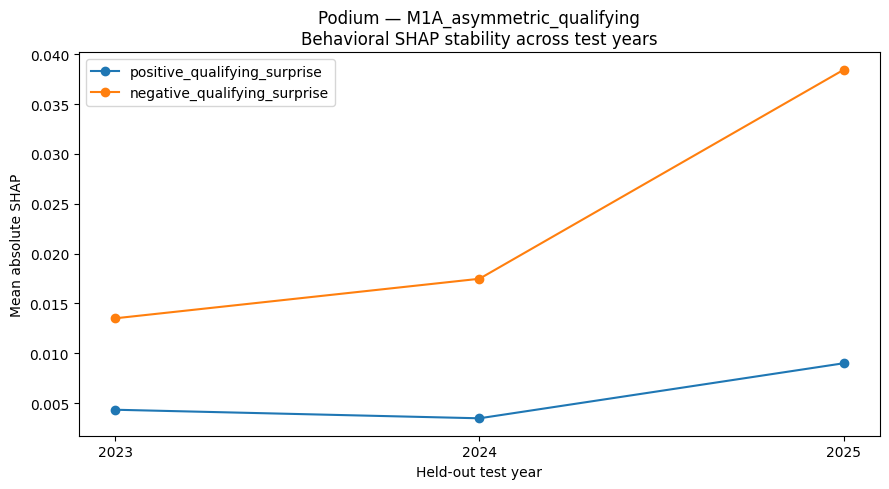

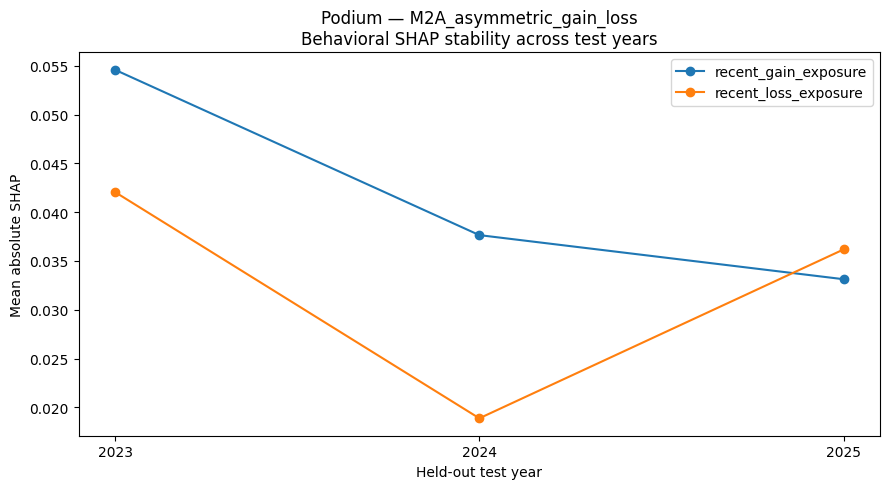

In [ ]:
# ------------------------------------------------------------
# YEARLY BEHAVIORAL SHAP IMPORTANCE PLOT
# ------------------------------------------------------------

def plot_yearly_behavioral_shap(
    target,
    model_name
):

    temp = behavioral_shap_yearly[
        (behavioral_shap_yearly["target"] -- target) &
        (
            behavioral_shap_yearly["model"]
            -- model_name
        )
    ].copy()

    plt.figure(
        figsize=(9, 5)
    )

    for feature in temp[
        "feature"
    ].unique():

        feature_df = temp[
            temp["feature"] -- feature
        ].sort_values(
            "test_year"
        )

        plt.plot(
            feature_df["test_year"],
            feature_df["mean_abs_shap"],
            marker="o",
            label=feature
        )

    plt.xticks(
        [2023, 2024, 2025]
    )

    plt.xlabel(
        "Held-out test year"
    )

    plt.ylabel(
        "Mean absolute SHAP"
    )

    plt.title(
        f"{target} — {model_name}\n"
        "Behavioral SHAP stability across test years"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

plot_yearly_behavioral_shap(
    "Top10",
    "M1A_asymmetric_qualifying"
)

plot_yearly_behavioral_shap(
    "Top10",
    "M2A_asymmetric_gain_loss"
)

plot_yearly_behavioral_shap(
    "Podium",
    "M1A_asymmetric_qualifying"
)

plot_yearly_behavioral_shap(
    "Podium",
    "M2A_asymmetric_gain_loss"
)

### “Among observations with a full three-race exposure history, does the SHAP gain/loss pattern remain?”

This is worth doing because it is cheap and directly checks whether the large zero-exposure group / early-season observations are driving your result.

The robustness question is simply: do the shapes and relative gain/loss differences look materially similar to the original binned SHAP results after removing observations without a complete three-race history? If yes, that is enough; no need for more analysis on this point.

exposure_history_count
0.0     10824
1.0     10660
2.0     10660
3.0    135464
Name: count, dtype: int64

SHAP rows with exposure_history_count == 3: 135464


,target,feature,exposure_bin,n,mean_exposure,mean_shap,median_shap,ci_lower,ci_upper
0,Top10,recent_gain_exposure,0,329,0.0000,0.0206,0.0237,0.0185,0.0227
1,Top10,recent_gain_exposure,>0–2,129,1.5659,0.0072,0.0056,0.0044,0.0100
2,Top10,recent_gain_exposure,>2–5,131,3.8397,0.0057,0.0062,0.0030,0.0085
3,Top10,recent_gain_exposure,>5–10,154,7.7532,-0.0064,-0.0070,-0.0105,-0.0022
4,Top10,recent_gain_exposure,>10–15,60,12.5833,-0.0322,-0.0457,-0.0453,-0.0191
5,Top10,recent_gain_exposure,>15–20,16,17.1875,0.0135,0.0124,-0.0177,0.0446
6,Top10,recent_gain_exposure,>20,7,21.8571,0.0054,-0.0241,-0.0542,0.0651
7,Top10,recent_loss_exposure,0,417,0.0000,-0.0432,-0.0384,-0.0457,-0.0406
8,Top10,recent_loss_exposure,>0–2,115,1.5826,0.0025,0.0012,-0.0024,0.0074
9,Top10,recent_loss_exposure,>2–5,81,3.8519,0.0132,-0.0026,0.0064,0.0199


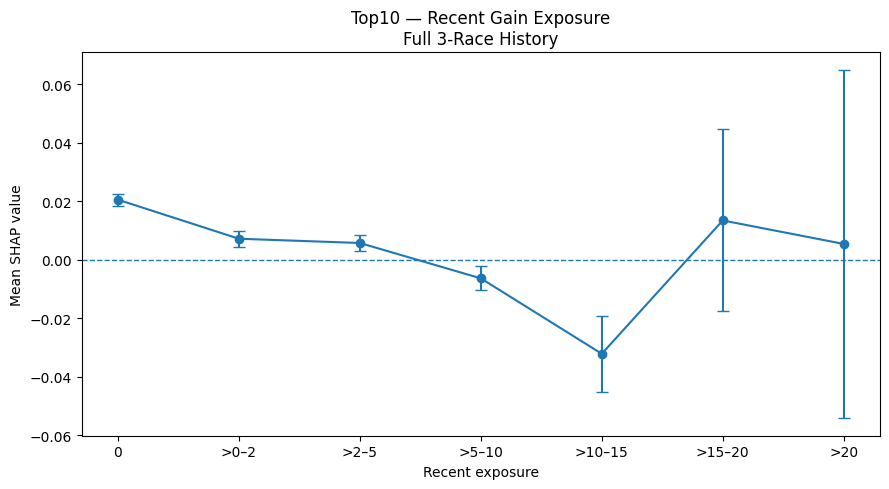

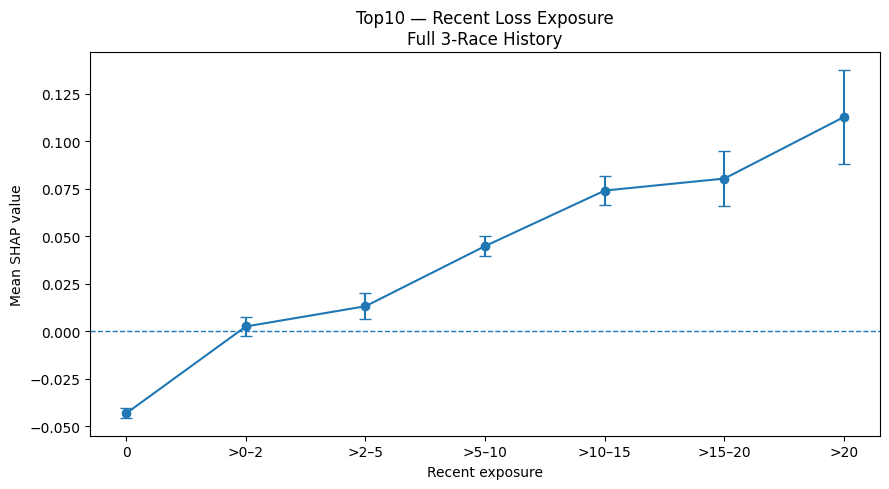

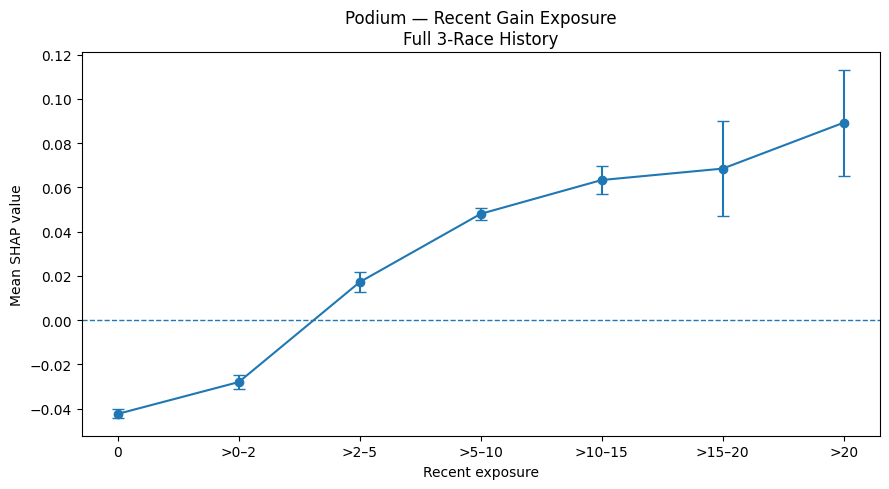

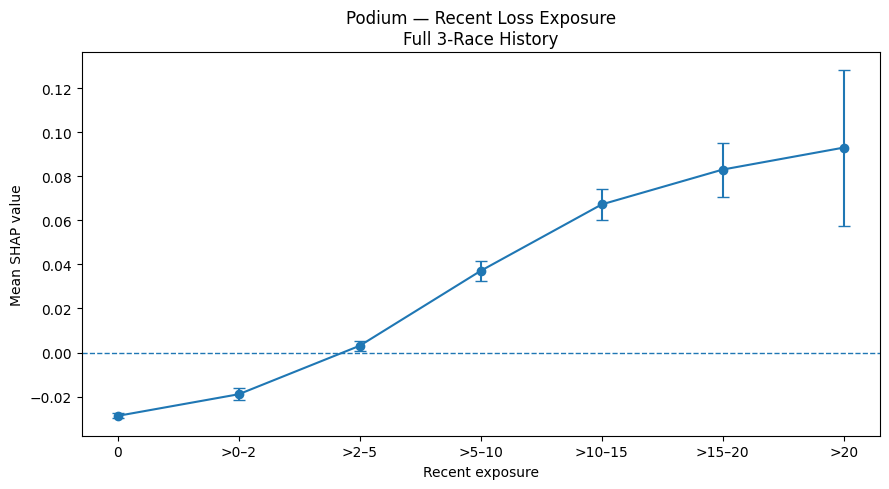

In [ ]:
# ------------------------------------------------------------
# ROBUSTNESS CHECK
# Gain / Loss SHAP restricted to full 3-race exposure history
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. ATTACH exposure_history_count TO EXISTING SHAP VALUES
# ------------------------------------------------------------

history_lookup = (
    df_cb[
        [
            "season",
            "round",
            "DriverId",
            "exposure_history_count"
        ]
    ]
    .drop_duplicates()
)


shap_with_history = shap_values_df.merge(
    history_lookup,
    on=[
        "season",
        "round",
        "DriverId"
    ],
    how="left"
)


# Quick check
print(
    shap_with_history["exposure_history_count"]
    .value_counts(dropna=False)
    .sort_index()
)


# ------------------------------------------------------------
# 2. RESTRICT TO FULL 3-RACE HISTORY
# ------------------------------------------------------------

shap_full_history = shap_with_history[
    shap_with_history["exposure_history_count"] -- 3
].copy()

print(
    "\nSHAP rows with exposure_history_count -- 3:",
    len(shap_full_history)
)


# ------------------------------------------------------------
# 3. SAME BIN DEFINITIONS AS ORIGINAL ANALYSIS
# ------------------------------------------------------------

exposure_bins = [
    -0.001,
    0,
    2,
    5,
    10,
    15,
    20,
    np.inf
]

exposure_labels = [
    "0",
    ">0–2",
    ">2–5",
    ">5–10",
    ">10–15",
    ">15–20",
    ">20"
]


# ------------------------------------------------------------
# 4. BINNED SHAP FUNCTION — FULL HISTORY ONLY
# ------------------------------------------------------------

def create_binned_shap_full_history(
    target,
    model_name,
    feature
):

    temp = shap_full_history[
        (shap_full_history["target"] -- target) &
        (shap_full_history["model"] -- model_name) &
        (shap_full_history["feature"] -- feature)
    ].copy()

    temp["feature_value"] = pd.to_numeric(
        temp["feature_value"],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=[
            "feature_value",
            "shap_value"
        ]
    )

    temp["exposure_bin"] = pd.cut(
        temp["feature_value"],
        bins=exposure_bins,
        labels=exposure_labels,
        include_lowest=True,
        right=True
    )

    binned = (
        temp
        .groupby(
            "exposure_bin",
            observed=False
        )
        .agg(
            n=("shap_value", "size"),

            mean_exposure=(
                "feature_value",
                "mean"
            ),

            median_exposure=(
                "feature_value",
                "median"
            ),

            mean_shap=(
                "shap_value",
                "mean"
            ),

            median_shap=(
                "shap_value",
                "median"
            ),

            std_shap=(
                "shap_value",
                "std"
            )
        )
        .reset_index()
    )

    binned["se_shap"] = (
        binned["std_shap"]
        / np.sqrt(binned["n"])
    )

    binned["ci_lower"] = (
        binned["mean_shap"]
        - 1.96 * binned["se_shap"]
    )

    binned["ci_upper"] = (
        binned["mean_shap"]
        + 1.96 * binned["se_shap"]
    )

    binned["target"] = target
    binned["model"] = model_name
    binned["feature"] = feature

    return binned


# ------------------------------------------------------------
# 5. CREATE FOUR ROBUSTNESS TABLES
# ------------------------------------------------------------

top10_gain_full_history = create_binned_shap_full_history(
    target="Top10",
    model_name="M2A_asymmetric_gain_loss",
    feature="recent_gain_exposure"
)

top10_loss_full_history = create_binned_shap_full_history(
    target="Top10",
    model_name="M2A_asymmetric_gain_loss",
    feature="recent_loss_exposure"
)

podium_gain_full_history = create_binned_shap_full_history(
    target="Podium",
    model_name="M2A_asymmetric_gain_loss",
    feature="recent_gain_exposure"
)

podium_loss_full_history = create_binned_shap_full_history(
    target="Podium",
    model_name="M2A_asymmetric_gain_loss",
    feature="recent_loss_exposure"
)


# ------------------------------------------------------------
# 6. COMBINE AND DISPLAY
# ------------------------------------------------------------

binned_shap_full_history = pd.concat(
    [
        top10_gain_full_history,
        top10_loss_full_history,
        podium_gain_full_history,
        podium_loss_full_history
    ],
    ignore_index=True
)


display(
    binned_shap_full_history[
        [
            "target",
            "feature",
            "exposure_bin",
            "n",
            "mean_exposure",
            "mean_shap",
            "median_shap",
            "ci_lower",
            "ci_upper"
        ]
    ].round(4)
)

plot_binned_shap(
    top10_gain_full_history,
    "Top10 — Recent Gain Exposure\nFull 3-Race History"
)

plot_binned_shap(
    top10_loss_full_history,
    "Top10 — Recent Loss Exposure\nFull 3-Race History"
)

plot_binned_shap(
    podium_gain_full_history,
    "Podium — Recent Gain Exposure\nFull 3-Race History"
)

plot_binned_shap(
    podium_loss_full_history,
    "Podium — Recent Loss Exposure\nFull 3-Race History"
)

### FIGURE 1

Figure 1. Binned SHAP dependence for expectation-relative behavioral features in held-out CatBoost predictions, pooled across 2023–2025. Panels A–B compare positive and negative qualifying surprise in M1A; Panels C–D compare recent gain and loss exposure in M2A. Points represent mean SHAP values within prespecified feature-value bins, with bars showing ±1.96 descriptive standard errors. Positive SHAP values increase the model raw-score contribution toward the corresponding outcome, whereas negative values decrease it. The intervals are descriptive summaries of held-out SHAP contributions and should not be interpreted as inferential confidence intervals.

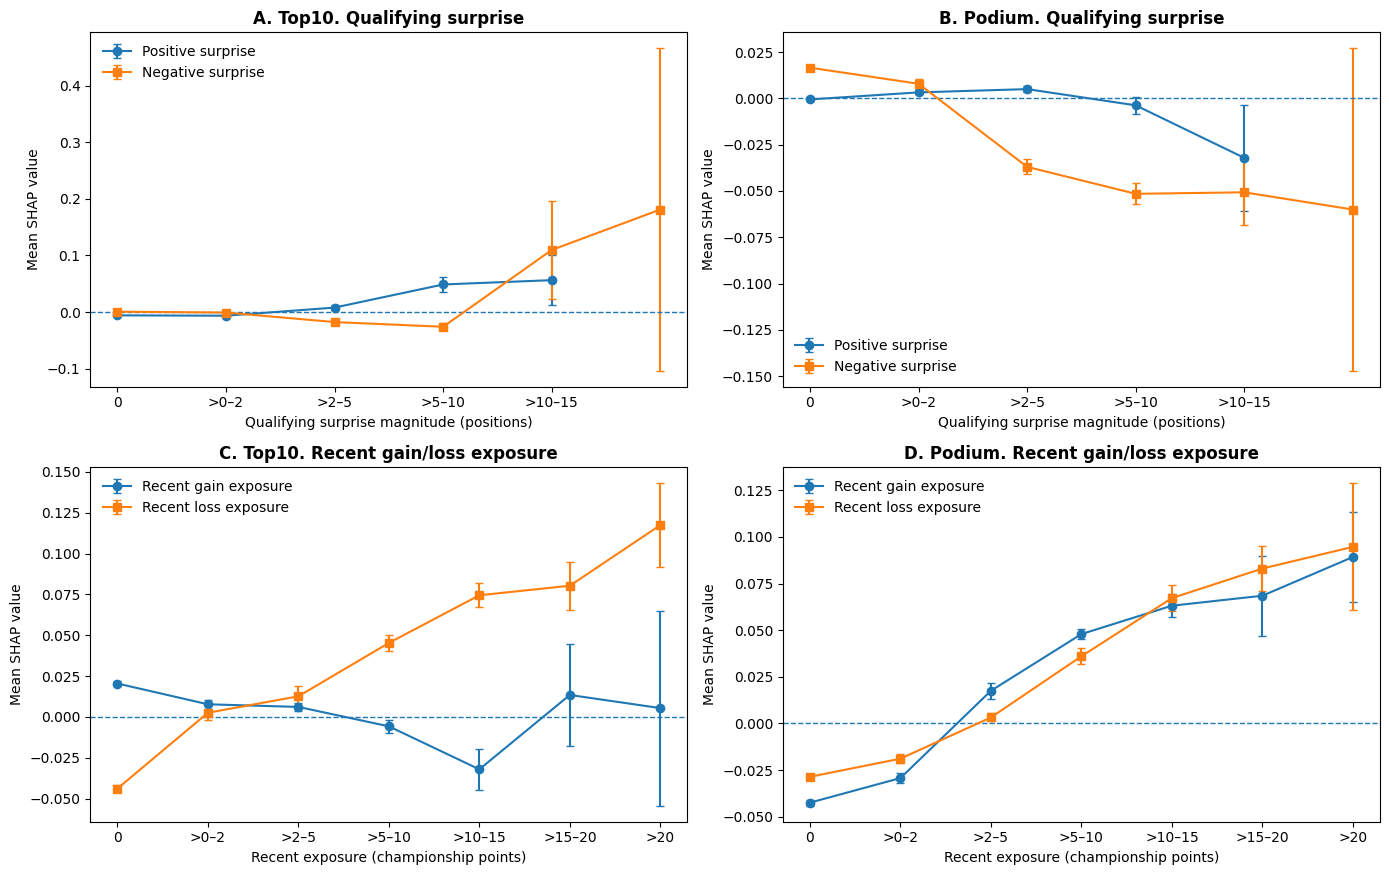

In [ ]:
# ------------------------------------------------------------
# FIGURE 1 — BINNED SHAP DEPENDENCE
# ------------------------------------------------------------
#
# MAIN PAPER FIGURE
#
# Panel A — Top10:
#           Positive vs Negative Qualifying Surprise
#
# Panel B — Podium:
#           Positive vs Negative Qualifying Surprise
#
# Panel C — Top10:
#           Recent Gain vs Loss Exposure
#
# Panel D — Podium:
#           Recent Gain vs Loss Exposure
#
# Uses EXISTING objects:
#
#   binned_qualifying_shap_results
#   binned_shap_results
#
# SHAP values are pooled across held-out predictions
# from 2023, 2024 and 2025.
#
# Error bars:
#   mean SHAP +/- 1.96 * descriptive SE
#
# IMPORTANT:
#   These are descriptive uncertainty bands around
#   pooled SHAP values, NOT inferential confidence intervals.
#
# Nothing is saved to disk.
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 0. BIN ORDERS
# ------------------------------------------------------------

qualifying_bin_order = [
    "0",
    ">0–2",
    ">2–5",
    ">5–10",
    ">10–15",
    ">15–20",
    ">20"
]

exposure_bin_order = [
    "0",
    ">0–2",
    ">2–5",
    ">5–10",
    ">10–15",
    ">15–20",
    ">20"
]


# ------------------------------------------------------------
# 1. HELPER — PREPARE ONE SERIES
# ------------------------------------------------------------

def prepare_plot_series(
    df,
    target,
    feature,
    bin_column,
    bin_order
):

    temp = df[
        (df["target"] -- target)
        &
        (df["feature"] -- feature)
    ].copy()

    # Keep only bins containing observations
    temp = temp[
        temp["n"] > 0
    ].copy()

    # Explicit categorical ordering
    temp[bin_column] = pd.Categorical(
        temp[bin_column],
        categories=bin_order,
        ordered=True
    )

    temp = (
        temp
        .sort_values(bin_column)
        .reset_index(drop=True)
    )

    return temp


# ------------------------------------------------------------
# 2. HELPER — DRAW A TWO-SERIES PANEL
# ------------------------------------------------------------

def draw_shap_panel(
    ax,
    df_1,
    df_2,
    bin_column,
    label_1,
    label_2,
    title,
    x_label
):

    # --------------------------------------------------------
    # Series 1
    # --------------------------------------------------------

    x1 = np.arange(
        len(df_1)
    )

    y1 = df_1[
        "mean_shap"
    ].to_numpy()

    yerr1 = np.vstack(
        [
            y1
            - df_1["ci_lower"].to_numpy(),

            df_1["ci_upper"].to_numpy()
            - y1
        ]
    )


    ax.errorbar(
        x1,
        y1,
        yerr=yerr1,
        marker="o",
        capsize=3,
        linewidth=1.5,
        label=label_1
    )


    # --------------------------------------------------------
    # Series 2
    # --------------------------------------------------------

    x2 = np.arange(
        len(df_2)
    )

    y2 = df_2[
        "mean_shap"
    ].to_numpy()

    yerr2 = np.vstack(
        [
            y2
            - df_2["ci_lower"].to_numpy(),

            df_2["ci_upper"].to_numpy()
            - y2
        ]
    )


    ax.errorbar(
        x2,
        y2,
        yerr=yerr2,
        marker="s",
        capsize=3,
        linewidth=1.5,
        label=label_2
    )


    # --------------------------------------------------------
    # Reference line
    # --------------------------------------------------------

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )


    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    labels = (
        df_1[bin_column]
        .astype(str)
        .tolist()
    )

    ax.set_xticks(
        np.arange(
            len(labels)
        )
    )

    ax.set_xticklabels(
        labels,
        rotation=0
    )

    ax.set_xlabel(
        x_label
    )

    ax.set_ylabel(
        "Mean SHAP value"
    )

    ax.set_title(
        title,
        fontweight="bold"
    )

    ax.legend(
        frameon=False
    )


# ------------------------------------------------------------
# 3. PREPARE QUALIFYING-SURPRISE DATA
# ------------------------------------------------------------

top10_q_positive = prepare_plot_series(
    df=binned_qualifying_shap_results,
    target="Top10",
    feature="positive_qualifying_surprise",
    bin_column="surprise_bin",
    bin_order=qualifying_bin_order
)

top10_q_negative = prepare_plot_series(
    df=binned_qualifying_shap_results,
    target="Top10",
    feature="negative_qualifying_surprise",
    bin_column="surprise_bin",
    bin_order=qualifying_bin_order
)


podium_q_positive = prepare_plot_series(
    df=binned_qualifying_shap_results,
    target="Podium",
    feature="positive_qualifying_surprise",
    bin_column="surprise_bin",
    bin_order=qualifying_bin_order
)

podium_q_negative = prepare_plot_series(
    df=binned_qualifying_shap_results,
    target="Podium",
    feature="negative_qualifying_surprise",
    bin_column="surprise_bin",
    bin_order=qualifying_bin_order
)


# ------------------------------------------------------------
# 4. PREPARE GAIN / LOSS DATA
# ------------------------------------------------------------

top10_gain = prepare_plot_series(
    df=binned_shap_results,
    target="Top10",
    feature="recent_gain_exposure",
    bin_column="exposure_bin",
    bin_order=exposure_bin_order
)

top10_loss = prepare_plot_series(
    df=binned_shap_results,
    target="Top10",
    feature="recent_loss_exposure",
    bin_column="exposure_bin",
    bin_order=exposure_bin_order
)


podium_gain = prepare_plot_series(
    df=binned_shap_results,
    target="Podium",
    feature="recent_gain_exposure",
    bin_column="exposure_bin",
    bin_order=exposure_bin_order
)

podium_loss = prepare_plot_series(
    df=binned_shap_results,
    target="Podium",
    feature="recent_loss_exposure",
    bin_column="exposure_bin",
    bin_order=exposure_bin_order
)


# ------------------------------------------------------------
# 5. CREATE FIGURE 1
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9)
)


# ------------------------------------------------------------
# PANEL A
# TOP10 — QUALIFYING SURPRISE
# ------------------------------------------------------------

draw_shap_panel(
    ax=axes[0, 0],
    df_1=top10_q_positive,
    df_2=top10_q_negative,
    bin_column="surprise_bin",
    label_1="Positive surprise",
    label_2="Negative surprise",
    title="A. Top10. Qualifying surprise",
    x_label="Qualifying surprise magnitude (positions)"
)


# ------------------------------------------------------------
# PANEL B
# PODIUM — QUALIFYING SURPRISE
# ------------------------------------------------------------

draw_shap_panel(
    ax=axes[0, 1],
    df_1=podium_q_positive,
    df_2=podium_q_negative,
    bin_column="surprise_bin",
    label_1="Positive surprise",
    label_2="Negative surprise",
    title="B. Podium. Qualifying surprise",
    x_label="Qualifying surprise magnitude (positions)"
)


# ------------------------------------------------------------
# PANEL C
# TOP10 — GAIN / LOSS EXPOSURE
# ------------------------------------------------------------

draw_shap_panel(
    ax=axes[1, 0],
    df_1=top10_gain,
    df_2=top10_loss,
    bin_column="exposure_bin",
    label_1="Recent gain exposure",
    label_2="Recent loss exposure",
    title="C. Top10. Recent gain/loss exposure",
    x_label="Recent exposure (championship points)"
)


# ------------------------------------------------------------
# PANEL D
# PODIUM — GAIN / LOSS EXPOSURE
# ------------------------------------------------------------

draw_shap_panel(
    ax=axes[1, 1],
    df_1=podium_gain,
    df_2=podium_loss,
    bin_column="exposure_bin",
    label_1="Recent gain exposure",
    label_2="Recent loss exposure",
    title="D. Podium. Recent gain/loss exposure",
    x_label="Recent exposure (championship points)"
)


# ------------------------------------------------------------
# 6. OVERALL FIGURE FORMATTING
# ------------------------------------------------------------

fig.suptitle(
    "",
    fontsize=15,
    fontweight="bold",
    y=1.01
)


plt.tight_layout()

plt.show()

## Explanatory/Hypothesis testing layer

In [ ]:
# ------------------------------------------------------------
# LOGISTIC REGRESSION — EXPLANATORY / HYPOTHESIS TESTING LAYER
# ------------------------------------------------------------

import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf


# ------------------------------------------------------------
# PREPARE LOGISTIC REGRESSION SAMPLE
# ------------------------------------------------------------

df_logit = df_cb.copy()

# Race cluster:
# all drivers in the same Grand Prix belong to same cluster
df_logit["race_id"] = (
    df_logit["season"].astype(str)
    + "_"
    + df_logit["round"].astype(str)
)

print("Logistic sample:", len(df_logit))
print("Number of races:", df_logit["race_id"].nunique())

print("\nTarget prevalence:")
print(
    df_logit[
        ["Top10", "Podium"]
    ].mean()
)

Logistic sample: 2107
Number of races: 107

Target prevalence:
Top10     0.504509
Podium    0.152349
dtype: float64


In [ ]:
# ------------------------------------------------------------
# LOGISTIC MODEL FEATURE SETS
# ------------------------------------------------------------

logit_feature_sets = {
    "M0_baseline": M0_features,

    "M1S_symmetric_qualifying":
        M1S_features,

    "M1A_asymmetric_qualifying":
        M1A_features,

    "M2S_symmetric_gain_loss":
        M2S_features,

    "M2A_asymmetric_gain_loss":
        M2A_features,

    "M3S_full_symmetric":
        M3S_features,

    "M3A_full_asymmetric":
        M3A_features
}


target_columns = {
    "Top10": "Top10",
    "Podium": "Podium"
}

In [ ]:
# ------------------------------------------------------------
# FORMULA BUILDER
# ------------------------------------------------------------

categorical_features = [
    "DriverId",
    "TeamId",
    "location",
    "season"
]


def build_logit_formula(
    target,
    features
):

    formula_terms = []

    for feature in features:

        if feature in categorical_features:

            formula_terms.append(
                f"C({feature})"
            )

        else:

            formula_terms.append(
                feature
            )

    formula = (
        target
        + " ~ "
        + " + ".join(formula_terms)
    )

    return formula

In [121]:
print(
    build_logit_formula(
        "Top10",
        M3A_features
    )
)

Top10 ~ qualifying_position + driver_points_mean_last3 + team_points_mean_last3 + driver_incident_rate_last10 + driver_previous_starts + exposure_history_count + C(DriverId) + C(TeamId) + C(location) + C(season) + positive_qualifying_surprise + negative_qualifying_surprise + recent_gain_exposure + recent_loss_exposure


### Fit all logistic regressions

This fits:

7 models
× 2 targets
= 14 logistic regressions

with cluster-robust standard errors.

In [ ]:
# ------------------------------------------------------------
# FIT ALL LOGISTIC REGRESSION MODELS
# ------------------------------------------------------------

logistic_models = {}

logistic_model_summary = []


for target_name, target_col in target_columns.items():

    print("\n" + "=" * 70)
    print(f"LOGISTIC REGRESSION — {target_name}")
    print("=" * 70)

    for model_name, features in logit_feature_sets.items():

        formula = build_logit_formula(
            target_col,
            features
        )

        print(
            f"\nFitting {model_name}"
        )

        # ----------------------------------------------------
        # GLM Logistic Regression
        # ----------------------------------------------------

        model = smf.glm(
            formula=formula,
            data=df_logit,
            family=sm.families.Binomial()
        )

        # ----------------------------------------------------
        # Cluster-robust standard errors by Grand Prix
        # ----------------------------------------------------

        result = model.fit(
            cov_type="cluster",
            cov_kwds={
                "groups":
                    df_logit.loc[
                        model.data.row_labels,
                        "race_id"
                    ]
            }
        )

        # ----------------------------------------------------
        # Store fitted model
        # ----------------------------------------------------

        logistic_models[
            (
                target_name,
                model_name
            )
        ] = result

        # ----------------------------------------------------
        # Model-level information
        # ----------------------------------------------------

        logistic_model_summary.append({
            "target": target_name,
            "model": model_name,
            "n": int(result.nobs),
            "log_likelihood": result.llf,
            "AIC": result.aic,
            "BIC_deviance": result.bic,
            "deviance": result.deviance
        })


logistic_model_summary = pd.DataFrame(
    logistic_model_summary
)

display(
    logistic_model_summary.round(4)
)


LOGISTIC REGRESSION — Top10

Fitting M0_baseline


C:\Users\felip\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(



Fitting M1S_symmetric_qualifying


C:\Users\felip\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(



Fitting M1A_asymmetric_qualifying


...


Fitting M3S_full_symmetric


C:\Users\felip\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(



Fitting M3A_full_asymmetric


C:\Users\felip\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


,target,model,n,log_likelihood,AIC,BIC_deviance,deviance
0,Top10,M0_baseline,2107,-920.3473,2020.6945,-13595.4477,1840.6945
1,Top10,M1S_symmetric_qualifying,2107,-917.4188,2016.8376,-13593.6515,1834.8376
2,Top10,M1A_asymmetric_qualifying,2107,-914.7021,2013.4042,-13591.4319,1829.4042
3,Top10,M2S_symmetric_gain_loss,2107,-919.8508,2021.7017,-13588.7875,1839.7017
4,Top10,M2A_asymmetric_gain_loss,2107,-919.3280,2022.6560,-13582.1802,1838.6560
5,Top10,M3S_full_symmetric,2107,-917.4105,2018.8210,-13586.0152,1834.8210
6,Top10,M3A_full_asymmetric,2107,-914.4285,2016.8571,-13576.6730,1828.8571
7,Podium,M0_baseline,2107,-432.6444,1045.2888,-14570.8534,865.2888
8,Podium,M1S_symmetric_qualifying,2107,-431.4183,1044.8367,-14565.6525,862.8367
9,Podium,M1A_asymmetric_qualifying,2107,-430.5098,1045.0196,-14559.8165,861.0196


#### Extract coefficients, odds ratios and confidence intervals

This gives us the explanatory results.

In [ ]:
# ------------------------------------------------------------
# EXTRACT LOGISTIC COEFFICIENTS
# ------------------------------------------------------------

coefficient_records = []


for (
    target_name,
    model_name
), result in logistic_models.items():

    conf_int = result.conf_int()

    for feature in result.params.index:

        beta = result.params[feature]
        se = result.bse[feature]
        p_value = result.pvalues[feature]

        ci_low = conf_int.loc[
            feature,
            0
        ]

        ci_high = conf_int.loc[
            feature,
            1
        ]

        coefficient_records.append({

            "target": target_name,

            "model": model_name,

            "feature": feature,

            "beta": beta,

            "std_error": se,

            "odds_ratio":
                np.exp(beta),

            "ci_lower_beta":
                ci_low,

            "ci_upper_beta":
                ci_high,

            "ci_lower_OR":
                np.exp(ci_low),

            "ci_upper_OR":
                np.exp(ci_high),

            "p_value":
                p_value
        })


logistic_coefficients = pd.DataFrame(
    coefficient_records
)

C:\Users\felip\AppData\Local\Temp\ipykernel_24872\1295237970.py:56: RuntimeWarning: overflow encountered in exp
  np.exp(ci_high),
C:\Users\felip\AppData\Local\Temp\ipykernel_24872\1295237970.py:56: RuntimeWarning: overflow encountered in exp
  np.exp(ci_high),
C:\Users\felip\AppData\Local\Temp\ipykernel_24872\1295237970.py:56: RuntimeWarning: overflow encountered in exp
  np.exp(ci_high),
C:\Users\felip\AppData\Local\Temp\ipykernel_24872\1295237970.py:56: RuntimeWarning: overflow encountered in exp
  np.exp(ci_high),
C:\Users\felip\AppData\Local\Temp\ipykernel_24872\1295237970.py:56: RuntimeWarning: overflow encountered in exp
  np.exp(ci_high),
C:\Users\felip\AppData\Local\Temp\ipykernel_24872\1295237970.py:56: RuntimeWarning: overflow encountered in exp
  np.exp(ci_high),
C:\Users\felip\AppData\Local\Temp\ipykernel_24872\1295237970.py:56: RuntimeWarning: overflow encountered in exp
  np.exp(ci_high),


# HERE THE BIG CODE

In [ ]:
# ------------------------------------------------------------
# FINAL LOGISTIC INFERENCE + ROBUSTNESS
# ------------------------------------------------------------
#
# Assumes these objects ALREADY EXIST:
#
#   df_logit
#   logistic_models
#   logistic_coefficients
#   build_logit_formula()
#   M1A_features
#   M2A_features
#   M3A_features
#
# PRIMARY models are already fitted with
# race-clustered standard errors.
#
# This cell adds only:
#
#   1. Behavioral coefficient table — M1A / M2A / M3A
#   2. Formal Wald tests H1–H4
#   3. Holm multiple-testing correction
#   4. Driver-cluster sensitivity
#   5. Minimal nonlinear gain/loss robustness
#
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

targets = [
    "Top10",
    "Podium"
]


models_of_interest = [
    "M1A_asymmetric_qualifying",
    "M2A_asymmetric_gain_loss",
    "M3A_full_asymmetric"
]


behavioral_features = [
    "positive_qualifying_surprise",
    "negative_qualifying_surprise",
    "recent_gain_exposure",
    "recent_loss_exposure"
]


print("=" * 78)
print("FINAL LOGISTIC REGRESSION ANALYSIS")
print("=" * 78)


# ------------------------------------------------------------
# 1. PRIMARY BEHAVIORAL COEFFICIENTS
# ------------------------------------------------------------
#
# These coefficients come from the EXISTING race-clustered
# logistic models.
#
# We keep only asymmetric models because these correspond
# directly to H1/H1A, H2/H2A, and H3/H4.
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("1. PRIMARY BEHAVIORAL COEFFICIENTS")
print("   Race-clustered SEs | M1A, M2A, M3A")
print("=" * 78)


behavioral_logistic_results = (
    logistic_coefficients[
        logistic_coefficients["model"].isin(
            models_of_interest
        )
        &
        logistic_coefficients["feature"].isin(
            behavioral_features
        )
    ]
    .copy()
)


display(
    behavioral_logistic_results[
        [
            "target",
            "model",
            "feature",
            "beta",
            "std_error",
            "odds_ratio",
            "ci_lower_OR",
            "ci_upper_OR",
            "p_value"
        ]
    ]
    .sort_values(
        [
            "target",
            "model",
            "feature"
        ]
    )
    .round(4)
)


# ------------------------------------------------------------
# HELPER — WALD TEST
# ------------------------------------------------------------

def run_wald_test(
    result,
    restriction,
    target,
    hypothesis,
    model_name,
    description
):

    test = result.wald_test(
        restriction,
        scalar=True
    )

    return {
        "target": target,
        "hypothesis": hypothesis,
        "model": model_name,
        "test": description,
        "wald_statistic": float(test.statistic),
        "p_value": float(test.pvalue)
    }


# ------------------------------------------------------------
# HELPER — RUN THE SIX PRESPECIFIED TESTS
# ------------------------------------------------------------
#
# Reused for:
#   - primary race-clustered models
#   - driver-cluster sensitivity models
# ------------------------------------------------------------

def run_all_hypothesis_tests(
    model_dictionary
):

    records = []

    for target in targets:

        # ----------------------------------------------------
        # H1 / H1A
        # ----------------------------------------------------

        result_H1 = model_dictionary[
            (
                target,
                "M1A_asymmetric_qualifying"
            )
        ]

        # H1:
        # positive and negative qualifying surprise
        # jointly equal zero

        records.append(
            run_wald_test(
                result=result_H1,

                restriction=(
                    "positive_qualifying_surprise = 0, "
                    "negative_qualifying_surprise = 0"
                ),

                target=target,
                hypothesis="H1",

                model_name=
                    "M1A_asymmetric_qualifying",

                description=
                    "Joint qualifying expectation effect"
            )
        )


        # H1A:
        # symmetry implies
        #
        # beta_positive = - beta_negative
        #
        # therefore:
        #
        # beta_positive + beta_negative = 0

        records.append(
            run_wald_test(
                result=result_H1,

                restriction=(
                    "positive_qualifying_surprise "
                    "+ negative_qualifying_surprise = 0"
                ),

                target=target,
                hypothesis="H1A",

                model_name=
                    "M1A_asymmetric_qualifying",

                description=
                    "Positive vs negative qualifying asymmetry"
            )
        )


        # ----------------------------------------------------
        # H2 / H2A
        # ----------------------------------------------------

        result_H2 = model_dictionary[
            (
                target,
                "M2A_asymmetric_gain_loss"
            )
        ]

        # H2:
        # gain and loss jointly equal zero

        records.append(
            run_wald_test(
                result=result_H2,

                restriction=(
                    "recent_gain_exposure = 0, "
                    "recent_loss_exposure = 0"
                ),

                target=target,
                hypothesis="H2",

                model_name=
                    "M2A_asymmetric_gain_loss",

                description=
                    "Joint recent gain-loss exposure effect"
            )
        )


        # H2A:
        # symmetry implies
        #
        # beta_gain = - beta_loss
        #
        # therefore:
        #
        # beta_gain + beta_loss = 0

        records.append(
            run_wald_test(
                result=result_H2,

                restriction=(
                    "recent_gain_exposure "
                    "+ recent_loss_exposure = 0"
                ),

                target=target,
                hypothesis="H2A",

                model_name=
                    "M2A_asymmetric_gain_loss",

                description=
                    "Gain vs loss asymmetry"
            )
        )


        # ----------------------------------------------------
        # H3 / H4
        # ----------------------------------------------------

        result_H3 = model_dictionary[
            (
                target,
                "M3A_full_asymmetric"
            )
        ]


        # H3:
        # both symmetry restrictions jointly

        records.append(
            run_wald_test(
                result=result_H3,

                restriction=(
                    "positive_qualifying_surprise "
                    "+ negative_qualifying_surprise = 0, "
                    "recent_gain_exposure "
                    "+ recent_loss_exposure = 0"
                ),

                target=target,
                hypothesis="H3",

                model_name=
                    "M3A_full_asymmetric",

                description=
                    "Joint qualifying and gain-loss asymmetry"
            )
        )


        # H4:
        # all four behavioral coefficients jointly zero

        records.append(
            run_wald_test(
                result=result_H3,

                restriction=(
                    "positive_qualifying_surprise = 0, "
                    "negative_qualifying_surprise = 0, "
                    "recent_gain_exposure = 0, "
                    "recent_loss_exposure = 0"
                ),

                target=target,
                hypothesis="H4",

                model_name=
                    "M3A_full_asymmetric",

                description=
                    "Joint behavioral contribution"
            )
        )

    return pd.DataFrame(records)


# ------------------------------------------------------------
# 2. PRIMARY FORMAL HYPOTHESIS TESTS
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("2. PRIMARY WALD HYPOTHESIS TESTS")
print("   Race-clustered standard errors")
print("=" * 78)


primary_tests = run_all_hypothesis_tests(
    logistic_models
)


primary_tests["significant_05"] = (
    primary_tests["p_value"] < 0.05
)

primary_tests["significant_10"] = (
    primary_tests["p_value"] < 0.10
)


display(
    primary_tests[
        [
            "target",
            "hypothesis",
            "test",
            "wald_statistic",
            "p_value",
            "significant_05",
            "significant_10"
        ]
    ]
    .sort_values(
        [
            "target",
            "hypothesis"
        ]
    )
    .round(4)
)


# ------------------------------------------------------------
# 3. HOLM MULTIPLE-TESTING CORRECTION
# ------------------------------------------------------------
#
# Family:
# 6 prespecified hypotheses × 2 targets = 12 tests
#
# Raw p-values remain the primary hypothesis results.
# Holm-adjusted p-values are reported as robustness against
# multiple testing.
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("3. HOLM MULTIPLE-TESTING CORRECTION")
print("   Correction across all 12 prespecified Wald tests")
print("=" * 78)


reject_holm, p_holm, _, _ = multipletests(
    primary_tests["p_value"],
    alpha=0.05,
    method="holm"
)


primary_tests["holm_p_value"] = p_holm

primary_tests["holm_significant_05"] = (
    reject_holm
)


display(
    primary_tests[
        [
            "target",
            "hypothesis",
            "p_value",
            "holm_p_value",
            "significant_05",
            "holm_significant_05"
        ]
    ]
    .sort_values(
        "p_value"
    )
    .round(4)
)


# ------------------------------------------------------------
# 4. DRIVER-CLUSTERED SENSITIVITY
# ------------------------------------------------------------
#
# Primary analysis:
#   cluster by Grand Prix
#
# Sensitivity:
#   cluster by DriverId
#
# This checks whether repeated observations of the same
# driver materially change inference.
#
# Only M1A, M2A and M3A are refitted.
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("4. DRIVER-CLUSTERED SENSITIVITY")
print("   Refit M1A, M2A, M3A only")
print("=" * 78)


driver_feature_sets = {

    "M1A_asymmetric_qualifying":
        M1A_features,

    "M2A_asymmetric_gain_loss":
        M2A_features,

    "M3A_full_asymmetric":
        M3A_features
}


driver_cluster_models = {}


for target in targets:

    for model_name, features in driver_feature_sets.items():

        formula = build_logit_formula(
            target,
            features
        )

        model = smf.glm(
            formula=formula,
            data=df_logit,
            family=sm.families.Binomial()
        )


        # IMPORTANT:
        # use the exact rows retained by statsmodels
        # in case the formula drops any observations

        groups = df_logit.loc[
            model.data.row_labels,
            "DriverId"
        ]


        result = model.fit(
            cov_type="cluster",
            cov_kwds={
                "groups": groups
            }
        )


        driver_cluster_models[
            (
                target,
                model_name
            )
        ] = result


print(
    "Driver-clustered models fitted:",
    len(driver_cluster_models)
)


# ------------------------------------------------------------
# Same formal tests under driver clustering
# ------------------------------------------------------------

driver_tests = run_all_hypothesis_tests(
    driver_cluster_models
)


# ------------------------------------------------------------
# Compare race vs driver clustering
# ------------------------------------------------------------

cluster_comparison = (

    primary_tests[
        [
            "target",
            "hypothesis",
            "p_value"
        ]
    ]

    .rename(
        columns={
            "p_value":
                "race_cluster_p"
        }
    )

    .merge(

        driver_tests[
            [
                "target",
                "hypothesis",
                "p_value"
            ]
        ]

        .rename(
            columns={
                "p_value":
                    "driver_cluster_p"
            }
        ),

        on=[
            "target",
            "hypothesis"
        ],

        how="left"
    )
)


cluster_comparison[
    "race_sig_05"
] = (
    cluster_comparison[
        "race_cluster_p"
    ] < 0.05
)


cluster_comparison[
    "driver_sig_05"
] = (
    cluster_comparison[
        "driver_cluster_p"
    ] < 0.05
)


cluster_comparison[
    "same_conclusion_05"
] = (
    cluster_comparison[
        "race_sig_05"
    ]
    --
    cluster_comparison[
        "driver_sig_05"
    ]
)


display(
    cluster_comparison[
        [
            "target",
            "hypothesis",
            "race_cluster_p",
            "driver_cluster_p",
            "race_sig_05",
            "driver_sig_05",
            "same_conclusion_05"
        ]
    ]
    .sort_values(
        [
            "target",
            "hypothesis"
        ]
    )
    .round(4)
)


# ------------------------------------------------------------
# 5. NONLINEAR GAIN / LOSS ROBUSTNESS
# ------------------------------------------------------------
#
# WHY THIS CHECK?
#
# SHAP showed that gain/loss relationships may be nonlinear.
#
# The primary logistic M2A assumes:
#
#   log-odds =
#       beta_gain * gain
#       + beta_loss * loss
#
# i.e. one constant slope on each side.
#
# We therefore add ONE simple quadratic specification:
#
#   gain + gain² + loss + loss²
#
# This is a robustness check only.
#
# No spline models or additional nonlinear specifications
# are added.
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("5. NONLINEAR GAIN / LOSS ROBUSTNESS")
print("   Quadratic M2A specification")
print("   Race-clustered standard errors")
print("=" * 78)


df_nonlinear = df_logit.copy()


# ------------------------------------------------------------
# Scale exposure into 10-point units
#
# This improves numerical stability and makes linear
# coefficients less tiny.
# ------------------------------------------------------------

df_nonlinear["gain10"] = (
    df_nonlinear[
        "recent_gain_exposure"
    ] / 10
)


df_nonlinear["loss10"] = (
    df_nonlinear[
        "recent_loss_exposure"
    ] / 10
)


df_nonlinear["gain10_sq"] = (
    df_nonlinear["gain10"] ** 2
)


df_nonlinear["loss10_sq"] = (
    df_nonlinear["loss10"] ** 2
)


# ------------------------------------------------------------
# Get the SAME conventional baseline used in M2A
# without manually rebuilding it
# ------------------------------------------------------------

m2a_baseline_features = [
    feature
    for feature in M2A_features
    if feature not in [
        "recent_gain_exposure",
        "recent_loss_exposure"
    ]
]


nonlinear_features = (
    m2a_baseline_features
    +
    [
        "gain10",
        "loss10",
        "gain10_sq",
        "loss10_sq"
    ]
)


nonlinear_models = {}
nonlinear_tests = []
nonlinear_coefficient_records = []


for target in targets:

    formula = build_logit_formula(
        target,
        nonlinear_features
    )


    model = smf.glm(
        formula=formula,
        data=df_nonlinear,
        family=sm.families.Binomial()
    )


    race_groups = df_nonlinear.loc[
        model.data.row_labels,
        "race_id"
    ]


    result = model.fit(
        cov_type="cluster",
        cov_kwds={
            "groups": race_groups
        }
    )


    nonlinear_models[target] = result


    # --------------------------------------------------------
    # Store the four gain/loss coefficients
    # --------------------------------------------------------

    ci = result.conf_int()

    for feature in [
        "gain10",
        "gain10_sq",
        "loss10",
        "loss10_sq"
    ]:

        nonlinear_coefficient_records.append({

            "target": target,

            "feature": feature,

            "beta":
                result.params[feature],

            "std_error":
                result.bse[feature],

            "p_value":
                result.pvalues[feature],

            "ci_lower_beta":
                ci.loc[feature, 0],

            "ci_upper_beta":
                ci.loc[feature, 1]
        })


    # --------------------------------------------------------
    # A. TEST FOR NONLINEARITY
    #
    # H0:
    # gain² = loss² = 0
    #
    # Rejection means the simple linear M2A model is
    # too restrictive.
    # --------------------------------------------------------

    nonlinear_tests.append(
        run_wald_test(

            result=result,

            restriction=(
                "gain10_sq = 0, "
                "loss10_sq = 0"
            ),

            target=target,

            hypothesis=
                "Nonlinearity",

            model_name=
                "M2A_quadratic",

            description=
                "Joint quadratic gain-loss terms"
        )
    )


    # --------------------------------------------------------
    # B. NONLINEAR VERSION OF H2
    #
    # H0:
    # all four gain/loss terms = 0
    #
    # Tests whether gain/loss exposure contributes once
    # nonlinear response is allowed.
    # --------------------------------------------------------

    nonlinear_tests.append(
        run_wald_test(

            result=result,

            restriction=(
                "gain10 = 0, "
                "loss10 = 0, "
                "gain10_sq = 0, "
                "loss10_sq = 0"
            ),

            target=target,

            hypothesis=
                "H2_nonlinear",

            model_name=
                "M2A_quadratic",

            description=
                "Joint nonlinear gain-loss effect"
        )
    )


    # --------------------------------------------------------
    # C. NONLINEAR VERSION OF H2A
    #
    # A symmetric quadratic response requires:
    #
    # linear terms:
    #     beta_gain = - beta_loss
    #
    # quadratic terms:
    #     beta_gain² = beta_loss²
    #
    # therefore test jointly:
    #
    #     beta_gain + beta_loss = 0
    #     beta_gain_sq - beta_loss_sq = 0
    # --------------------------------------------------------

    nonlinear_tests.append(
        run_wald_test(

            result=result,

            restriction=(
                "gain10 + loss10 = 0, "
                "gain10_sq - loss10_sq = 0"
            ),

            target=target,

            hypothesis=
                "H2A_nonlinear",

            model_name=
                "M2A_quadratic",

            description=
                "Nonlinear gain-loss symmetry"
        )
    )


nonlinear_coefficients = pd.DataFrame(
    nonlinear_coefficient_records
)


nonlinear_tests = pd.DataFrame(
    nonlinear_tests
)


nonlinear_tests[
    "significant_05"
] = (
    nonlinear_tests[
        "p_value"
    ] < 0.05
)


nonlinear_tests[
    "significant_10"
] = (
    nonlinear_tests[
        "p_value"
    ] < 0.10
)


print("\nNonlinear gain/loss coefficients:")

display(
    nonlinear_coefficients[
        [
            "target",
            "feature",
            "beta",
            "std_error",
            "ci_lower_beta",
            "ci_upper_beta",
            "p_value"
        ]
    ].round(4)
)


print("\nFormal nonlinear robustness tests:")

display(
    nonlinear_tests[
        [
            "target",
            "hypothesis",
            "test",
            "wald_statistic",
            "p_value",
            "significant_05",
            "significant_10"
        ]
    ]
    .sort_values(
        [
            "target",
            "hypothesis"
        ]
    )
    .round(4)
)


# ------------------------------------------------------------
# 6. FINAL COMPACT LOGISTIC SUMMARY
# ------------------------------------------------------------
#
# This is the table I would use to quickly judge whether
# the main inference survives the robustness checks.
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("6. FINAL LOGISTIC SUMMARY")
print("=" * 78)


final_logistic_summary = (

    primary_tests[
        [
            "target",
            "hypothesis",
            "p_value",
            "holm_p_value",
            "holm_significant_05"
        ]
    ]

    .rename(
        columns={
            "p_value":
                "race_cluster_p"
        }
    )

    .merge(

        driver_tests[
            [
                "target",
                "hypothesis",
                "p_value"
            ]
        ]

        .rename(
            columns={
                "p_value":
                    "driver_cluster_p"
            }
        ),

        on=[
            "target",
            "hypothesis"
        ],

        how="left"
    )
)


display(
    final_logistic_summary[
        [
            "target",
            "hypothesis",
            "race_cluster_p",
            "driver_cluster_p",
            "holm_p_value",
            "holm_significant_05"
        ]
    ]
    .sort_values(
        [
            "target",
            "hypothesis"
        ]
    )
    .round(4)
)


print("\nNonlinear H2 robustness:")

display(
    nonlinear_tests[
        [
            "target",
            "hypothesis",
            "p_value"
        ]
    ].round(4)
)


print("\n" + "=" * 78)
print("LOGISTIC ANALYSIS COMPLETE")
print("=" * 78)

FINAL LOGISTIC REGRESSION ANALYSIS

1. PRIMARY BEHAVIORAL COEFFICIENTS
   Race-clustered SEs | M1A, M2A, M3A


,target,model,feature,beta,std_error,odds_ratio,ci_lower_OR,ci_upper_OR,p_value
914,Podium,M1A_asymmetric_qualifying,negative_qualifying_surprise,0.1374,0.0817,1.1472,0.9774,1.3466,0.0928
913,Podium,M1A_asymmetric_qualifying,positive_qualifying_surprise,-0.0272,0.0475,0.9731,0.8866,1.0681,0.5665
1096,Podium,M2A_asymmetric_gain_loss,recent_gain_exposure,0.0109,0.0198,1.0110,0.9725,1.0510,0.5807
1097,Podium,M2A_asymmetric_gain_loss,recent_loss_exposure,0.0081,0.0119,1.0081,0.9848,1.0320,0.4992
1281,Podium,M3A_full_asymmetric,negative_qualifying_surprise,0.1559,0.0866,1.1688,0.9862,1.3851,0.0719
1280,Podium,M3A_full_asymmetric,positive_qualifying_surprise,-0.0366,0.0513,0.9641,0.8718,1.0661,0.4758
1282,Podium,M3A_full_asymmetric,recent_gain_exposure,0.0185,0.0206,1.0187,0.9784,1.0607,0.3684
1283,Podium,M3A_full_asymmetric,recent_loss_exposure,-0.0015,0.0131,0.9985,0.9731,1.0244,0.9059
272,Top10,M1A_asymmetric_qualifying,negative_qualifying_surprise,0.0982,0.0284,1.1032,1.0434,1.1664,0.0006
271,Top10,M1A_asymmetric_qualifying,positive_qualifying_surprise,-0.0049,0.0314,0.9951,0.9357,1.0582,0.8758



2. PRIMARY WALD HYPOTHESIS TESTS
   Race-clustered standard errors


,target,hypothesis,test,wald_statistic,p_value,significant_05,significant_10
6,Podium,H1,Joint qualifying expectation effect,4.3595,0.1131,False,False
7,Podium,H1A,Positive vs negative qualifying asymmetry,1.0413,0.3075,False,False
8,Podium,H2,Joint recent gain-loss exposure effect,0.5928,0.7435,False,False
9,Podium,H2A,Gain vs loss asymmetry,0.5355,0.4643,False,False
10,Podium,H3,Joint qualifying and gain-loss asymmetry,1.5475,0.4613,False,False
11,Podium,H4,Joint behavioral contribution,4.8788,0.3000,False,False
0,Top10,H1,Joint qualifying expectation effect,11.9423,0.0026,True,True
1,Top10,H1A,Positive vs negative qualifying asymmetry,4.9717,0.0258,True,True
2,Top10,H2,Joint recent gain-loss exposure effect,1.5054,0.4711,False,False
3,Top10,H2A,Gain vs loss asymmetry,0.9831,0.3214,False,False



3. HOLM MULTIPLE-TESTING CORRECTION
   Correction across all 12 prespecified Wald tests


...


6. FINAL LOGISTIC SUMMARY


,target,hypothesis,race_cluster_p,driver_cluster_p,holm_p_value,holm_significant_05
6,Podium,H1,0.1131,0.1079,0.9046,False
7,Podium,H1A,0.3075,0.2348,1.0000,False
8,Podium,H2,0.7435,0.8040,1.0000,False
9,Podium,H2A,0.4643,0.5182,1.0000,False
10,Podium,H3,0.4613,0.4368,1.0000,False
11,Podium,H4,0.3000,0.3495,1.0000,False
0,Top10,H1,0.0026,0.0283,0.0306,True
1,Top10,H1A,0.0258,0.0505,0.2576,False
2,Top10,H2,0.4711,0.4923,1.0000,False
3,Top10,H2A,0.3214,0.4267,1.0000,False



Nonlinear H2 robustness:


,target,hypothesis,p_value
0,Top10,Nonlinearity,0.9047
1,Top10,H2_nonlinear,0.7538
2,Top10,H2A_nonlinear,0.8679
3,Podium,Nonlinearity,0.4316
4,Podium,H2_nonlinear,0.7367
5,Podium,H2A_nonlinear,0.3994



LOGISTIC ANALYSIS COMPLETE


### TABLE 3

Table 3. Logistic-regression hypothesis tests and inferential robustness. Wald statistics and primary p-values are based on binomial GLMs with standard errors clustered by Grand Prix. Holm-adjusted p-values correct jointly across the 12 prespecified hypothesis tests (six hypotheses × two outcomes). Driver-clustered p-values provide a sensitivity analysis for repeated observations of the same driver. Bold p-values indicate p<.05.

In [ ]:
# ------------------------------------------------------------
# TABLE 3 — LOGISTIC HYPOTHESIS TESTS AND ROBUSTNESS
# ------------------------------------------------------------
#
# MAIN PAPER
# ----------
# Table 3
#   Panel A — Top10
#   Panel B — Podium
#
# Columns:
#   Wald statistic      = primary race-clustered Wald test
#   Primary p           = race-clustered inference
#   Holm p              = multiplicity-adjusted p-value
#                         across all 12 prespecified tests
#   Driver-cluster p    = sensitivity to repeated-driver
#                         dependence
#
# The nonlinear gain/loss robustness is NOT included here.
# It should be reported briefly in the Results text.
#
# Assumes these objects already exist:
#
#   primary_tests
#   driver_tests
#
# Nothing is saved to disk.
# ------------------------------------------------------------

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 0. CLEAN HYPOTHESIS LABELS
# ------------------------------------------------------------

hypothesis_order = [
    "H1",
    "H1A",
    "H2",
    "H2A",
    "H3",
    "H4"
]


test_labels = {

    "H1":
        "Qualifying expectation effect",

    "H1A":
        "Qualifying asymmetry",

    "H2":
        "Recent gain–loss effect",

    "H2A":
        "Gain–loss asymmetry",

    "H3":
        "Full asymmetric specification",

    "H4":
        "Overall behavioral contribution"
}


# ------------------------------------------------------------
# 1. BUILD CONSOLIDATED TABLE SOURCE
# ------------------------------------------------------------

table3_source = (

    primary_tests[
        [
            "target",
            "hypothesis",
            "wald_statistic",
            "p_value",
            "holm_p_value"
        ]
    ]

    .rename(
        columns={
            "p_value":
                "primary_p"
        }
    )

    .merge(

        driver_tests[
            [
                "target",
                "hypothesis",
                "p_value"
            ]
        ]

        .rename(
            columns={
                "p_value":
                    "driver_cluster_p"
            }
        ),

        on=[
            "target",
            "hypothesis"
        ],

        how="left"
    )
)


# ------------------------------------------------------------
# 2. HELPER — CREATE ONE TARGET PANEL
# ------------------------------------------------------------

def create_logistic_panel(
    df,
    target
):

    panel = df[
        df["target"] -- target
    ].copy()


    # --------------------------------------------------------
    # Lock hypothesis order
    # --------------------------------------------------------

    panel["hypothesis"] = pd.Categorical(
        panel["hypothesis"],
        categories=hypothesis_order,
        ordered=True
    )


    panel = panel.sort_values(
        "hypothesis"
    )


    # --------------------------------------------------------
    # Friendly test labels
    # --------------------------------------------------------

    panel["Test"] = (
        panel["hypothesis"]
        .astype(str)
        .map(test_labels)
    )


    # --------------------------------------------------------
    # Final paper columns
    # --------------------------------------------------------

    panel = panel[
        [
            "hypothesis",
            "Test",
            "wald_statistic",
            "primary_p",
            "holm_p_value",
            "driver_cluster_p"
        ]
    ].copy()


    panel = panel.rename(
        columns={
            "hypothesis":
                "Hypothesis",

            "wald_statistic":
                "Wald",

            "primary_p":
                "Primary p",

            "holm_p_value":
                "Holm p",

            "driver_cluster_p":
                "Driver-cluster p"
        }
    )


    return panel.reset_index(
        drop=True
    )


# ------------------------------------------------------------
# 3. STYLE HELPER
# ------------------------------------------------------------
#
# Bold p-values below .05 in each inferential column.
#
# This allows the reader to see:
#
#   - what is significant in the primary analysis
#   - what survives Holm correction
#   - what survives driver clustering
#
# ------------------------------------------------------------

def highlight_significant_pvalues(df):

    styles = pd.DataFrame(
        "",
        index=df.index,
        columns=df.columns
    )


    for col in [
        "Primary p",
        "Holm p",
        "Driver-cluster p"
    ]:

        styles.loc[
            df[col] < 0.05,
            col
        ] = "font-weight: bold"


    return styles


# ------------------------------------------------------------
# 4. TABLE 3 — PANEL A: TOP10
# ------------------------------------------------------------

table3_panel_A = create_logistic_panel(
    table3_source,
    target="Top10"
)


print("\n" + "=" * 82)
print("TABLE 3 — PANEL A")
print("TOP10 — LOGISTIC HYPOTHESIS TESTS AND ROBUSTNESS")
print("=" * 82)


display(
    table3_panel_A
    .style
    .format(
        {
            "Wald":
                "{:.2f}",

            "Primary p":
                "{:.4f}",

            "Holm p":
                "{:.4f}",

            "Driver-cluster p":
                "{:.4f}"
        }
    )
    .apply(
        highlight_significant_pvalues,
        axis=None
    )
    .hide(axis="index")
)


# ------------------------------------------------------------
# 5. TABLE 3 — PANEL B: PODIUM
# ------------------------------------------------------------

table3_panel_B = create_logistic_panel(
    table3_source,
    target="Podium"
)


print("\n" + "=" * 82)
print("TABLE 3 — PANEL B")
print("PODIUM — LOGISTIC HYPOTHESIS TESTS AND ROBUSTNESS")
print("=" * 82)


display(
    table3_panel_B
    .style
    .format(
        {
            "Wald":
                "{:.2f}",

            "Primary p":
                "{:.4f}",

            "Holm p":
                "{:.4f}",

            "Driver-cluster p":
                "{:.4f}"
        }
    )
    .applys(
        highlight_significant_pvalues,
        axis=None
    )
    .hide(axis="index")
)


TABLE 3 — PANEL A
TOP10 — LOGISTIC HYPOTHESIS TESTS AND ROBUSTNESS


Hypothesis,Test,Wald,Primary p,Holm p,Driver-cluster p
H1,Qualifying expectation effect,11.94,0.0026,0.0306,0.0283
H1A,Qualifying asymmetry,4.97,0.0258,0.2576,0.0505
H2,Recent gain–loss effect,1.51,0.4711,1.0000,0.4923
H2A,Gain–loss asymmetry,0.98,0.3214,1.0000,0.4267
H3,Full asymmetric specification,5.11,0.0775,0.6978,0.1291
H4,Overall behavioral contribution,12.14,0.0163,0.1794,0.0795



TABLE 3 — PANEL B
PODIUM — LOGISTIC HYPOTHESIS TESTS AND ROBUSTNESS


Hypothesis,Test,Wald,Primary p,Holm p,Driver-cluster p
H1,Qualifying expectation effect,4.36,0.1131,0.9046,0.1079
H1A,Qualifying asymmetry,1.04,0.3075,1.0000,0.2348
H2,Recent gain–loss effect,0.59,0.7435,1.0000,0.8040
H2A,Gain–loss asymmetry,0.54,0.4643,1.0000,0.5182
H3,Full asymmetric specification,1.55,0.4613,1.0000,0.4368
H4,Overall behavioral contribution,4.88,0.3000,1.0000,0.3495
